In [18]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [19]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

#colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']
#colors = ["#FFD600", "#FF6D00", "#D50000", "#2962FF", "#AA00FF", "#C51162"]
colors = ["#00C853", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]
#colors = ['tab:green', 'tab:yellow', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
#colors = ["#4CAF50", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * stats.sem(values)

In [20]:
# LIB: Measurements

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

hmd = "hmd"

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    return df[unity_unix_key].min()
    # if e == cube:
    #     return df[unity_unix_key].min()
    # else:
    #     first_load = df[(df["collision_or_load_count"] == 1)]
    #     return first_load[unity_unix_key].min()

def task_end(df, e):
    return df[unity_unix_key].max()
    # if e == cube:
    #     return df[unity_unix_key].max()
    # else:
    #     final_load = df[(df["collision_or_load_count"] == 20)]
    #     final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

    #     return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def calc_pt_deltas(unity_df, pt):
    unity_df[pt + "_x_delta"] = unity_df[pt + "_x"].diff()
    unity_df[pt + "_y_delta"] = unity_df[pt + "_y"].diff()
    unity_df[pt + "_z_delta"] = unity_df[pt + "_z"].diff()

    new_df = unity_df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    new_df[pt+"_delta_dist"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_planar"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_z_delta"]), (0,0)), axis = 1)
    new_df[pt+"_delta_dist_vertical"] = new_df.apply(lambda x: abs(x[pt + "_y_delta"]), axis = 1) #TODO check if this makes sense

    return new_df

def get_pt_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist"].sum()

def get_pt_path_len_planar(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_planar"].sum()

def get_pt_path_len_vertical(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_vertical"].sum()

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c, augment_unity):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    # Add HMD path data
    if augment_unity:
        unity_synced = calc_pt_deltas(unity_synced, hmd)

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    #imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)
    #min_hr = imot_pre_task.dropna(subset = hr_key)[hr_key].quantile(extrema_quantile)
    #min_gsr_con = imot_pre_task.dropna(subset = gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        #"min_hr": min_hr,
        #"min_gsr_con": min_gsr_con
    }

def get_experiment(p, e, augment_unity):
    condition_data = list(map(lambda x: get_condition(p, e, x, augment_unity), conditions))

    #min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    #min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            #"min_hr": min_hr,
            #"min_gsr_con": min_gsr_con
    }
def get_participant(p, augment_unity):
    return {
        cube: get_experiment(p, cube, augment_unity),
        shovel: get_experiment(p, shovel, augment_unity),
        subject_key: p
    }

In [21]:
# LIB: Significance Testing

significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    for _index, row in aov.iterrows():
        aov_str = "" + str(row["Source"]) + " & (" + str(row["ddof1"]) + ", " + str(row["ddof2"]) + ") & " + str(round(row["F"], 2)) + " & " 
        p_val = row[p_unc] if p_corr not in aov.columns or np.isnan(row[p_corr]) else row[p_corr]
        if row[significance_key] == "✅":
            aov_str += "\\textbf{" + str(round(p_val, 6)) + "}"
        else:
            aov_str += str(round(p_val, 6))
        aov_str+= " & " + str(round(row["ng2"], 4)) + " \\\\"
        print(aov_str)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

        for _index, row in valid_pairwise.iterrows():
            pairwise_str = "" + str(row["Contrast"]) + " " + str(row["B"]) + "-" + str(row["A"]) + " & " + str(int(row["dof"])) + " & " + str(round(row["T"] * -1, 2)) + " & "
            p_val = row[p_unc] if np.isnan(row[p_corr]) else row[p_corr]
            if row[significance_key] == "✅":
                pairwise_str += "\\textbf{" + str(round(p_val, 6)) + "}"
            else:
                pairwise_str += str(round(p_val, 6))
            pairwise_str+= " & " + str(round(row["hedges"] * -1, 4)) + " \\\\"
            print(pairwise_str)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def plot_significance_brackets(ax, ylim, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (ylim[1] - ylim[0]) / 10
    bracket_height = offset_step * 0.25
    barplot_height = np.max(barheights)
    current_height = barplot_height + offset_step * 0.5

    for bracket in brackets:
        left = bracket[0]
        right = bracket[1]
        p_value = bracket[2]

        if(p_value < 0.1):
            color = "black" if p_value < 0.05 else "gray"
            text = "+"
            if(p_value < 0.05): text = "*"
            if(p_value < 0.005): text = "**"
            if(p_value < 0.0005): text = "***"
            if(p_value < 0.00005): text = "****"

            left_x = n_bars[left]
            right_x = n_bars[right]

            bottom_y = current_height
            top_y = current_height + bracket_height

            bracket_pts_x = [left_x, left_x, right_x, right_x]
            bracket_pts_y = [bottom_y, top_y, top_y, bottom_y]

            bracket_center_x = (left_x + right_x) / 2

            ax.plot(bracket_pts_x, bracket_pts_y, c=color)
            ax.text(bracket_center_x, top_y, text, color=color, ha='center', va='bottom')

            current_height += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([ylim[0], np.max([current_height, ylim[1]])])

def plot_values(axs, idx, values, labels, scale, ylim, title, brackets, plot_colors):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    axs_first = axs[0, idx]
    axs_second = axs[1, idx]

    # Bar Plot
    axs_first.bar(labels, means, yerr=conf, capsize=6, color=plot_colors, edgecolor='black')
    axs_first.set_title(title)

    if scale is not None:
        yticks = range(scale[0], scale[1]+1)
        axs_first.set_yticks(yticks)
        axs_first.set_ylim(scale[0], scale[1])
        axs_second.set_yticks(yticks)
        yrange = scale[1]-scale[0]
        yrange_offset = yrange * 0.05
        axs_second.set_ylim([scale[0]-yrange_offset, scale[1]+yrange_offset])
    elif ylim is not None:
        axs_first.set_ylim(ylim)
        axs_second.set_ylim(ylim)

    #Box Plot
    boxplot = axs_second.boxplot(values, showfliers=True, widths=0.2)

    #Violin Plot
    n_bars = np.arange(len(labels))
    violin = axs_second.violinplot(values, showmeans=False, showextrema=False, showmedians=False)
    axs_second.set_xticks([y + 1 for y in n_bars], labels=labels)

    for idx, b in enumerate(violin['bodies']):
        # Get the center of the plot
        m = np.mean(b.get_paths()[0].vertices[:, 1])
        # Modify it so we only see the upper half of the violin plot
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], idx+1, idx+2)
        # Change to the desired color
        b.set_color(plot_colors[idx])

    #Scatter Plot
    for idx, features in enumerate(values):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .8)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
        x = out
        axs_second.scatter(x, features, c=plot_colors[idx], alpha=0.2)

    #Significance brackets
    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])
    plot_significance_brackets(axs_first, axs_first.get_ylim(), barheights, brackets)

def plot_experiment(df, e, key, title, scale, ylabel, ylim, two_way_tests, one_way_tests):
    fig, axs = plt.subplots(2, 3, figsize=(20, 10), width_ratios=[2, 3, 6])
    #fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for _index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, devices, scale, ylim, "Device", brackets=device_brackets, plot_colors=[colors[0], colors[3]])

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for _index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scalings, scale, ylim, "Scaling", brackets=scaling_brackets, plot_colors=[colors[0], colors[1], colors[2]])

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    # condition_brackets = []
    # for _index, row in one_way_tests.iterrows():
    #     a = condition_dict[row["A"]]
    #     b = condition_dict[row["B"]]
    #     p_value = row["p-corr"]
    #     if(np.isnan(p_value)):
    #         p_value = row["p-unc"]
    #     condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, conditions, scale, ylim, "Condition", brackets=[], plot_colors=colors)

    if ylabel is not None:
        axs[0][0].set_ylabel(ylabel)
        axs[1][0].set_ylabel(ylabel)

    # Adjust all ylims to match between columns
    for i in range(2): #Rows
        row = axs[i]

        minima = []
        maxima = []
        for j in range (3): #Columns
            ylim = row[j].get_ylim()
            minima.append(ylim[0])
            maxima.append(ylim[1])

        minimum = min(minima)
        maximum = max(maxima)

        for j in range (3): #Columns
            row[j].set_ylim([minimum, maximum])

    fig.tight_layout()
    plt.show()

def report_experiment_core(df, e, key, title, scale, ylabel, ylim):

    print('\033[1m' + "------ " + "["+e+"] " + title + " ------")

    #Descriptive statistics
    #device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    #scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    decimals = 2

    means_str = "Mean"
    # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), device_values))))
    # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), scaling_values))))
    means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), condition_values))))
    means_str += " \\\\"
    print(means_str)

    stddev_str = "Standard Deviation"
    # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), device_values))))
    # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), scaling_values))))
    stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), condition_values))))
    stddev_str += " \\\\"
    print(stddev_str)

    min_str = "Minimum"
    # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), device_values))))
    # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), scaling_values))))
    min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), condition_values))))
    min_str += " \\\\"
    print(min_str)

    max_str = "Maximum"
    # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), device_values))))
    # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), scaling_values))))
    max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), condition_values))))
    max_str += " \\\\"
    print(max_str)

    two_way_result = rm_anova(df, key, two_way=True)
    #one_way_result = rm_anova(df, key, two_way=False)

    two_way_sig_pairwise = get_semi_significant_entries(two_way_result[pairwise_key])
    #one_way_sig_pairwise = get_semi_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, scale, ylabel, ylim, two_way_sig_pairwise, None)

    return two_way_result

def get_eff_sizes_ttests(df, key):
    eff_sizes = []
    if not (df['Contrast'] == 'Device').any():
        eff_sizes.append(0) # Missing Device entry
    for _index, row in df.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[key] * -1) #Flip hedges effect size sign, since we flip comparison to be more intuitive when plotting
        else:
            eff_sizes.append(0)
    if not (df['Contrast'] == 'Scaling').any():
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry

    # Swap last and second last list element (better ordering for plotting)
    temp = eff_sizes[-2]
    eff_sizes[-2] = eff_sizes[-1]
    eff_sizes[-1] = temp

    return eff_sizes
    

def plot_splits_core(ax, splits_values, splits_labels, title, column_labels, column_colors, ylabel):
    width = 1 / (len(column_labels)+2)  # the width of the bars
    multiplier = 1
    x = np.arange(len(splits_labels))  # the label locations
    for i in range(len(column_labels)):
        values = list(map(lambda x: x[i], splits_values))
        offset = width * (multiplier + 0.5)
        ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
        multiplier += 1
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x + 0.5, splits_labels)
    ax.set_xlim([0, len(splits_labels)])

def report_comparison(splits, aovs, split_labels, title, ylabel):
    fig, axs = plt.subplots(1, 2, figsize=(20, 5), width_ratios=[2, 1])
    eff_size_labels = ["Device P-C", "Scaling 1-0", "Scaling 2-1", "Scaling 2-0"]
    eff_size_colors = [colors[3], colors[1], colors[2], colors[5]]
    eff_sizes = list(map(lambda x: get_eff_sizes_ttests(x[pairwise_key], "hedges"), aovs))

    plot_splits_core(axs[0], splits, split_labels, title, conditions, colors, ylabel)
    axs[0].legend(loc='upper left', ncols=6)
    plot_splits_core(axs[1], eff_sizes, split_labels, title + ' Effect Size', eff_size_labels, eff_size_colors, 'Hedges\' g')
    axs[1].legend(loc='upper left', ncols=4)

    # Make legend always fit
    for ax in axs:
        curr_ylim = ax.get_ylim()
        dist = curr_ylim[1]-curr_ylim[0]
        ax.set_ylim(curr_ylim[0], curr_ylim[1] + dist * 0.1)

    fig.tight_layout()
    plt.show()

In [22]:
# Notebook Defs

def get_task_df(p, key):
    start = p[start_ts]
    end = p[end_ts]
    return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)

def mean_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].mean()

def normalized_auc(p, key):
    duration = p[start_ts]-p[end_ts]
    task_df = get_task_df(p, key)
    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x))

extrema_quantile = 0.9

def peak_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(extrema_quantile)

def delta_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(extrema_quantile) - task_df[key].quantile(1-extrema_quantile)

    #start_df = trim_df(p[imot], min_ts = start - baseline_ms, max_ts = start).dropna(subset = key)
    #end_df = trim_df(p[imot], min_ts = end, max_ts = end + baseline_ms).dropna(subset = key)
    #task_df = trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)
    #baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))
    #return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)[key].mean()

tuple_value_key = "v"
tuple_subject_key = "p"

def find_outliers(tuples, m=3):
    values = list(map(lambda x: x[tuple_value_key], tuples))
    mean = np.mean(values)
    std = np.std(values)

    outliers = []
    for i in tuples:
        value = i[tuple_value_key]
        if np.abs(value - mean) > m * std:
            outliers.append(i)

    return outliers

def agg_values(data, single_func, e, c):
    participant_values = list(map(lambda x: {tuple_value_key: single_func(x[e][c]), tuple_subject_key: x[subject_key]}, data))
    return participant_values

def get_condition_values(data, single_func, e, remove_outliers):
    complete_values =  []
    outliers_set = set([])

    for c in conditions:
        condition_values = agg_values(data, single_func, e, c)
        complete_values.append(condition_values)

        if remove_outliers:
            cond_outliers = find_outliers(condition_values)
            for i in cond_outliers:
                print("[" + e + "] " + c + " subject " + i[tuple_subject_key] + " is outlier")
                outliers_set.add(i[tuple_subject_key])

    if remove_outliers:
        for outlier in outliers_set:
            print("[" + e + "] dropping subject " + outlier)

        #Filter out outliers from ALL conditions afterwards
        filtered_values = []
        for condition_values in complete_values:
            filtered_condition_values = list(filter(lambda x: x[tuple_subject_key] not in outliers_set, condition_values))
            filtered_values.append(filtered_condition_values)

        return filtered_values

    else:
        return complete_values

def report_exeriment(data, func, e, title, ylabel = None, ylim = None, remove_outliers = False):
    condition_values = get_condition_values(data, func, e, remove_outliers)

    #Construct DF matching LIB format
    value_key = 'target_var'
    data =  {subject_key: [], device_key: [], scaling_key: [], value_key: [], condition_key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        n_values = len(condition_values[i])
        device = [conditions[i][0]] * n_values # Device is always the same for condition
        scaling = [conditions[i][1:]] * n_values # Scaling is always the same for condition
        cond = [conditions[i]] * n_values # Condition is always the same for condition

        values = list(map(lambda x: x[tuple_value_key], condition_values[i]))
        subjects = list(map(lambda x: x[tuple_subject_key], condition_values[i]))

        condition_data = {subject_key: subjects, device_key: device, scaling_key: scaling, value_key: values, condition_key: cond}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    return report_experiment_core(df, e, value_key, title, None, ylabel, ylim)

In [23]:
data = list(map(lambda x: get_participant(x, augment_unity=True), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,grab_count,collision_or_load_count,unix_ms,delta_ms,hmd_x_delta,hmd_y_delta,hmd_z_delta,hmd_delta_dist,hmd_delta_dist_planar,hmd_delta_dist_vertical
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,1,0,1750157266350,14,0.000185,-0.000783,-0.000379,0.000889,0.000422,0.000783
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,1,0,1750157266379,43,0.000279,-0.001432,-0.000806,0.001667,0.000853,0.001432
3,6/17/2025 12:47:46 PM,1750157266393,Right,0.013629,0.082381,0.009438,-0.024857,0.157077,0.274748,0.013574,...,1,0,1750157266393,57,0.000260,-0.000542,-0.000252,0.000652,0.000362,0.000542


------ [Cube] Mean Heart Rate ------
Mean & 87.41 & 86.98 & 87.84 & 85.45 & 86.37 & 87.6 \\
Standard Deviation & 13.9 & 12.74 & 12.81 & 14.23 & 15.77 & 13.3 \\
Minimum & 59.68 & 60.86 & 61.96 & 59.64 & 55.96 & 60.61 \\
Maximum & 123.92 & 110.88 & 114.35 & 124.55 & 133.39 & 116.55 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,55.095755,1,41,55.095755,1.909549,0.174497,0.174497,0.001141,1.000000,❌
1,Scaling,79.089909,2,82,39.544955,1.283855,0.282475,0.281029,0.001638,0.899006,❌
2,Device * Scaling,34.553161,2,82,17.276580,0.427277,0.653726,0.619048,0.000716,0.840056,❌


Device & (1, 41) & 1.91 & 0.174497 & 0.0011 \\
Scaling & (2, 82) & 1.28 & 0.281029 & 0.0016 \\
Device * Scaling & (2, 82) & 0.43 & 0.619048 & 0.0007 \\


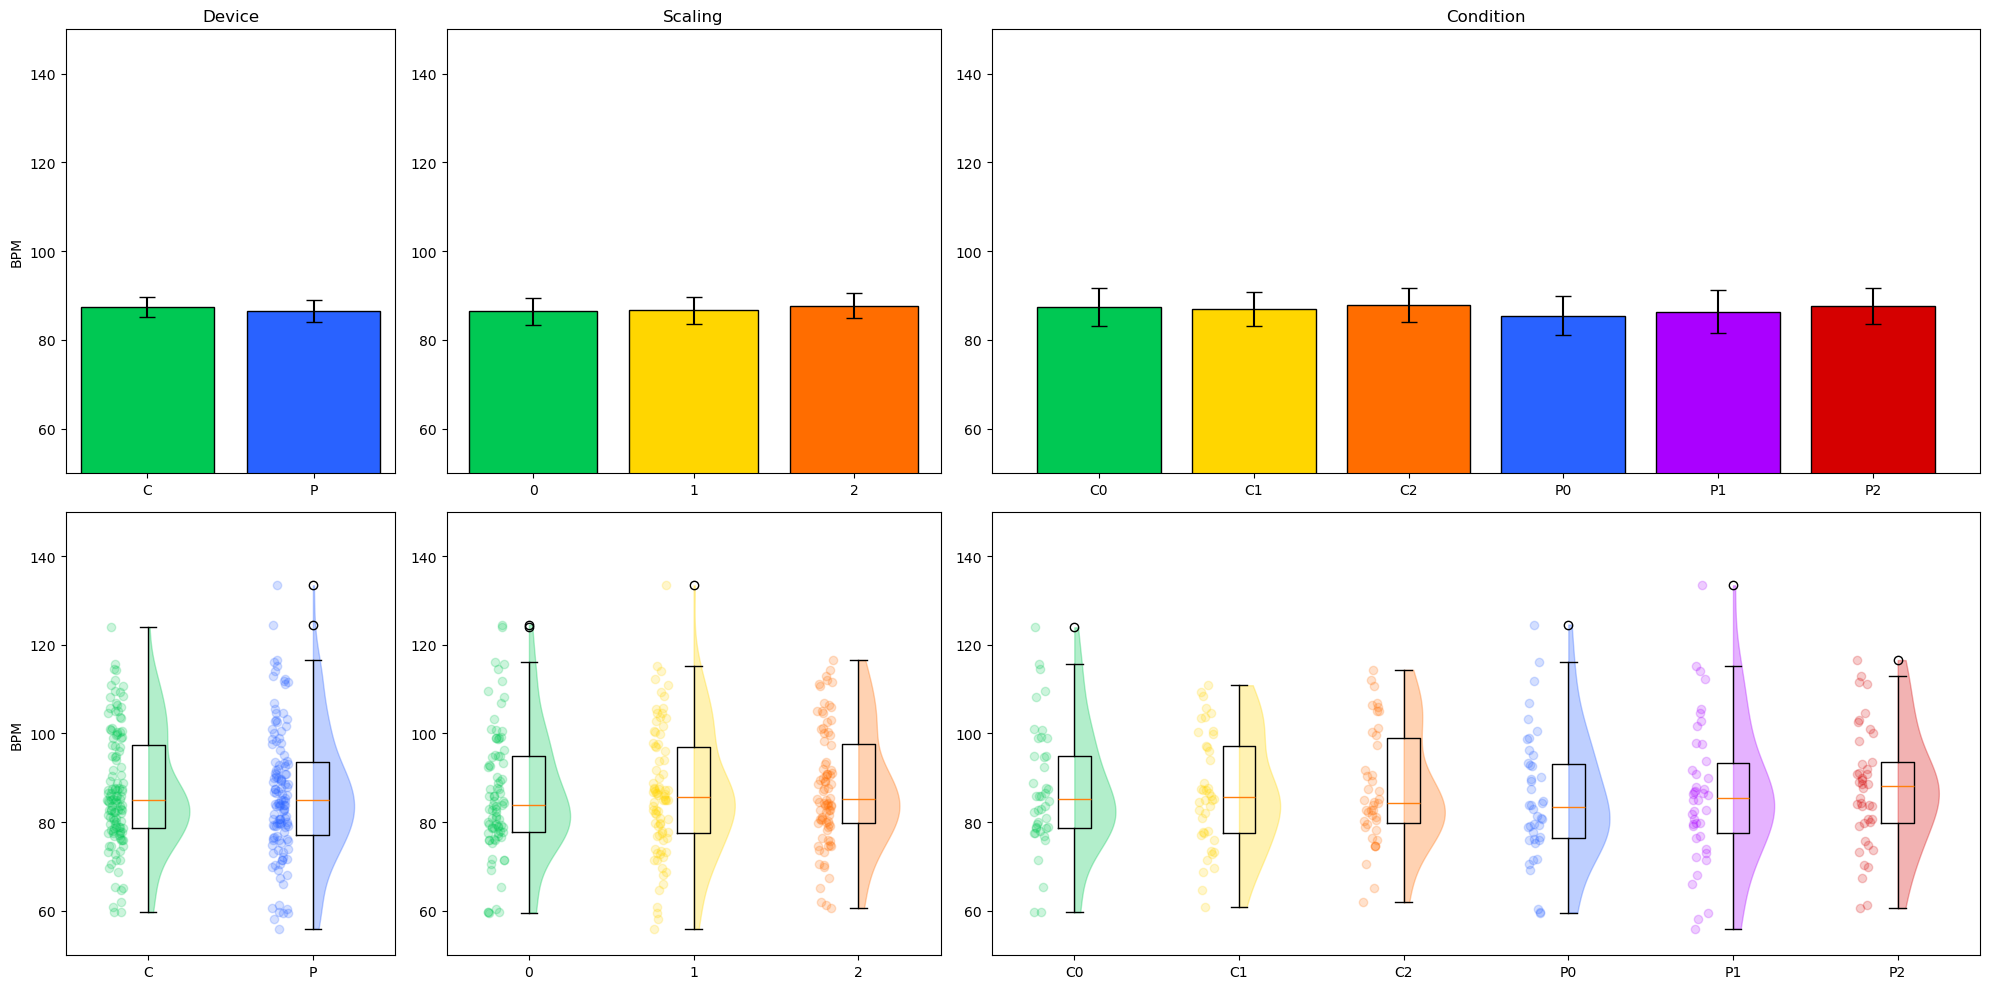

------ [Shovel] Mean Heart Rate ------
Mean & 93.18 & 94.2 & 94.52 & 93.51 & 94.1 & 94.8 \\
Standard Deviation & 14.16 & 14.57 & 13.1 & 13.67 & 12.87 & 14.14 \\
Minimum & 61.86 & 66.55 & 67.0 & 66.67 & 63.94 & 63.62 \\
Maximum & 121.12 & 128.96 & 127.8 & 122.36 & 124.36 & 131.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.744598,1,41,1.744598,0.113003,0.738465,0.738465,0.000037,1.000000,❌
1,Scaling,74.331556,2,82,37.165778,4.254019,0.017466,0.020602,0.001555,0.913955,✅
2,Device * Scaling,2.362663,2,82,1.181332,0.115325,0.891221,0.865074,0.000049,0.871837,❌


Device & (1, 41) & 0.11 & 0.738465 & 0.0 \\
Scaling & (2, 82) & 4.25 & \textbf{0.020602} & 0.0016 \\
Device * Scaling & (2, 82) & 0.12 & 0.865074 & 0.0 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.951651,41.0,two-sided,0.057834,0.115667,holm,0.934,-0.057982,❌
2,Scaling,-,0,2,True,True,-2.533125,41.0,two-sided,0.015226,0.045678,holm,2.802,-0.095011,✅
3,Scaling,-,1,2,True,True,-1.205087,41.0,two-sided,0.235079,0.235079,holm,0.327,-0.037449,❌


Scaling 1-0 & 41 & 1.95 & 0.115667 & 0.058 \\
Scaling 2-0 & 41 & 2.53 & \textbf{0.045678} & 0.095 \\
Scaling 2-1 & 41 & 1.21 & 0.235079 & 0.0374 \\


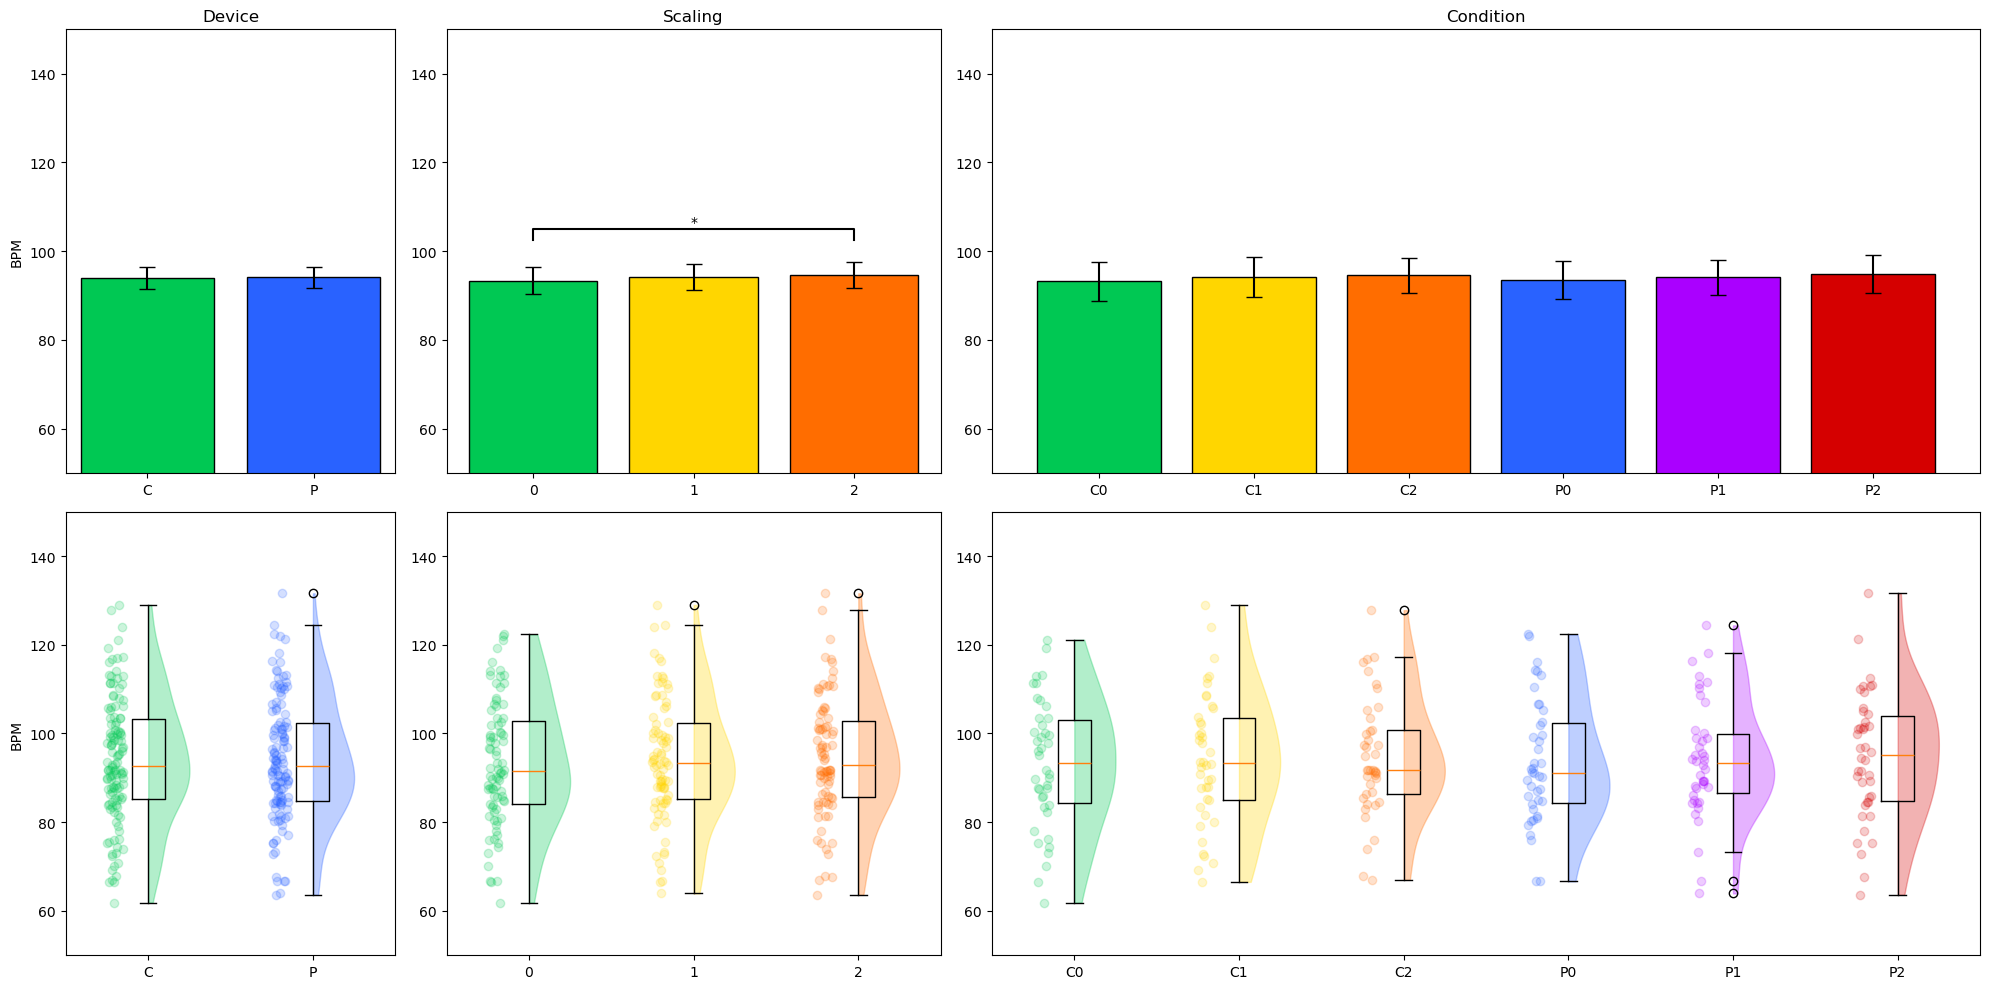

------ [Cube] Heart Rate Normalized AUC ------
Mean & 82.68 & 82.05 & 83.21 & 81.16 & 81.47 & 83.39 \\
Standard Deviation & 13.86 & 12.51 & 12.22 & 15.05 & 15.48 & 12.99 \\
Minimum & 56.54 & 57.07 & 60.23 & 55.59 & 53.48 & 56.57 \\
Maximum & 121.91 & 105.79 & 109.87 & 123.0 & 127.49 & 113.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,25.646150,1,41,25.646150,0.771243,0.384950,0.384950,0.000539,1.000000,❌
1,Scaling,120.876697,2,82,60.438348,1.506201,0.227821,0.230222,0.002534,0.809598,❌
2,Device * Scaling,30.375726,2,82,15.187863,0.299987,0.741637,0.710362,0.000638,0.866846,❌


Device & (1, 41) & 0.77 & 0.38495 & 0.0005 \\
Scaling & (2, 82) & 1.51 & 0.230222 & 0.0025 \\
Device * Scaling & (2, 82) & 0.3 & 0.710362 & 0.0006 \\


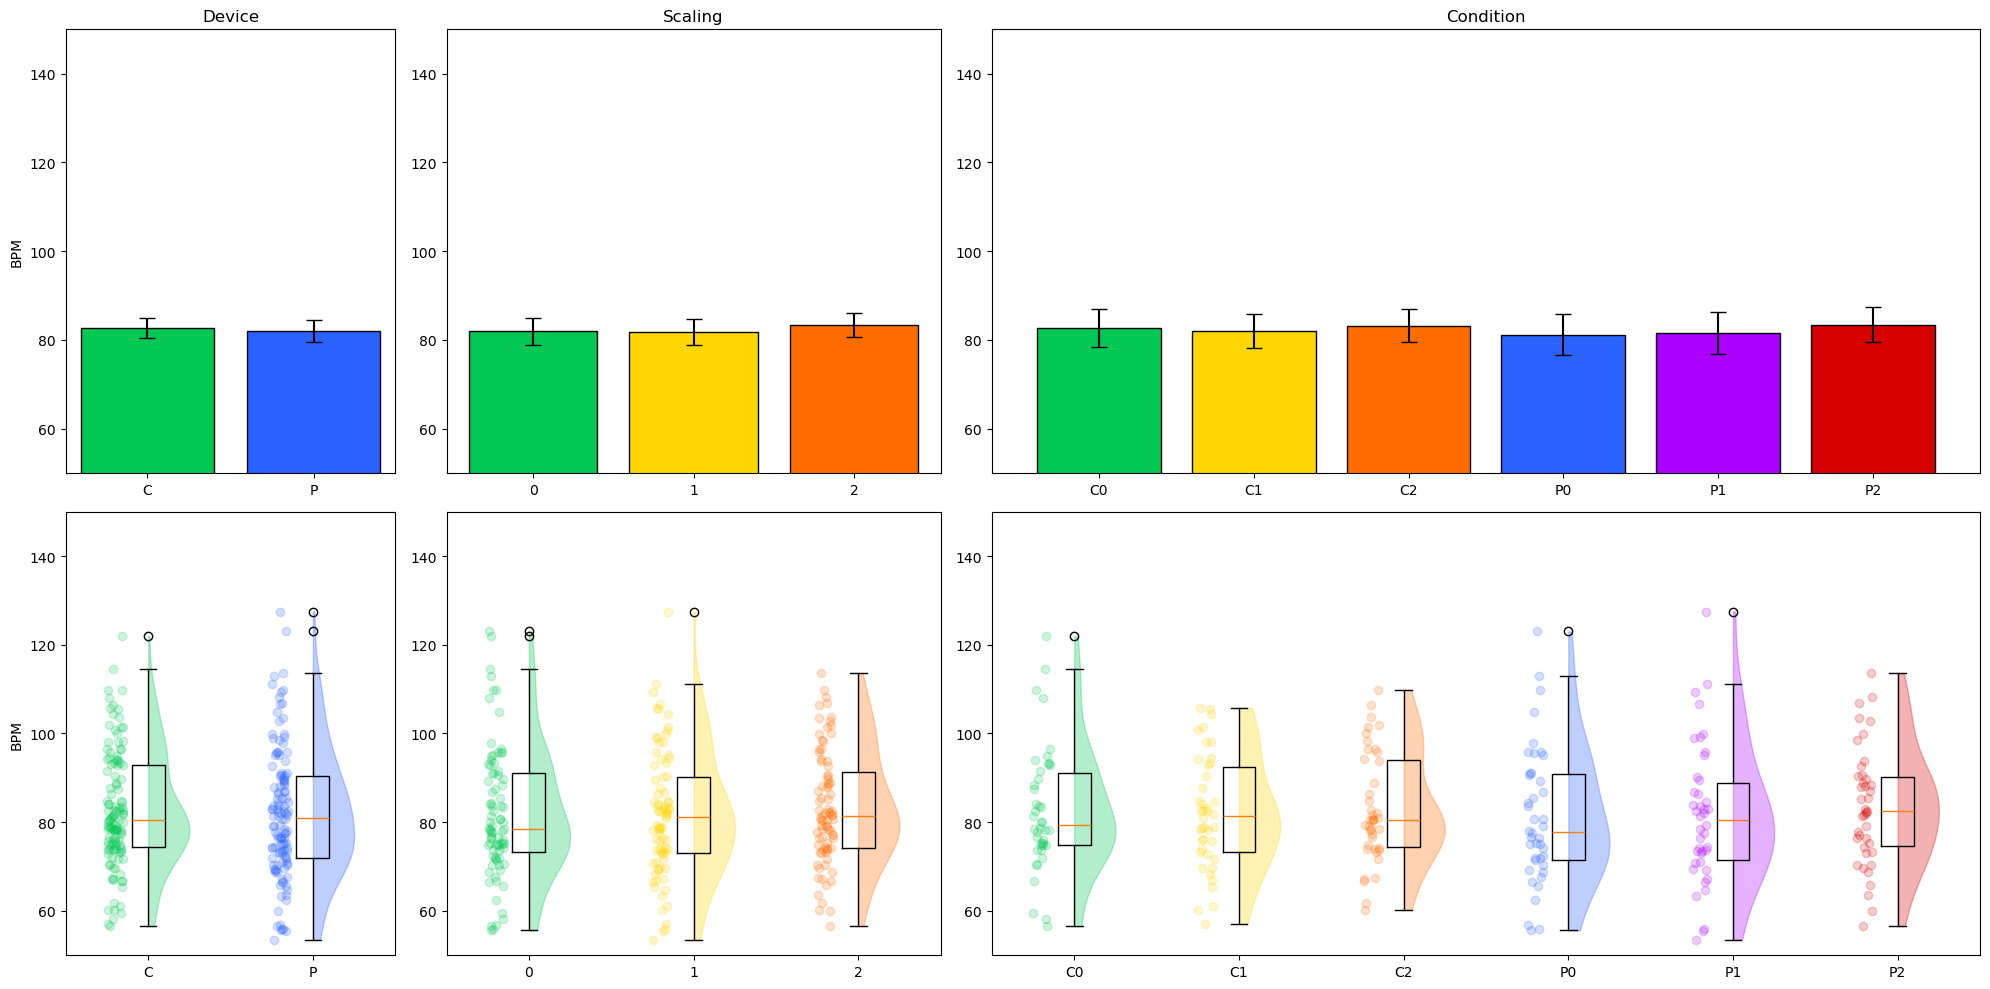

------ [Shovel] Heart Rate Normalized AUC ------
Mean & 91.79 & 93.06 & 93.56 & 92.27 & 92.8 & 93.73 \\
Standard Deviation & 14.03 & 14.37 & 12.98 & 13.59 & 12.68 & 14.11 \\
Minimum & 61.12 & 65.45 & 66.44 & 64.92 & 62.33 & 62.7 \\
Maximum & 119.75 & 127.49 & 125.43 & 121.51 & 122.43 & 130.34 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.102022,1,41,1.102022,0.066596,0.797649,0.797649,0.000024,1.000000,❌
1,Scaling,109.839807,2,82,54.919904,6.426979,0.002553,0.003781,0.002338,0.889062,✅
2,Device * Scaling,5.830397,2,82,2.915199,0.286238,0.751831,0.724685,0.000124,0.883706,❌


Device & (1, 41) & 0.07 & 0.797649 & 0.0 \\
Scaling & (2, 82) & 6.43 & \textbf{0.003781} & 0.0023 \\
Device * Scaling & (2, 82) & 0.29 & 0.724685 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.306186,41.0,two-sided,0.026231,0.052461,holm,1.777,-0.065309,🟨
2,Scaling,-,0,2,True,True,-3.092804,41.0,two-sided,0.003561,0.010683,holm,9.794,-0.117033,✅
3,Scaling,-,1,2,True,True,-1.658981,41.0,two-sided,0.104752,0.104752,holm,0.588,-0.052761,❌


Scaling 1-0 & 41 & 2.31 & 0.052461 & 0.0653 \\
Scaling 2-0 & 41 & 3.09 & \textbf{0.010683} & 0.117 \\
Scaling 2-1 & 41 & 1.66 & 0.104752 & 0.0528 \\


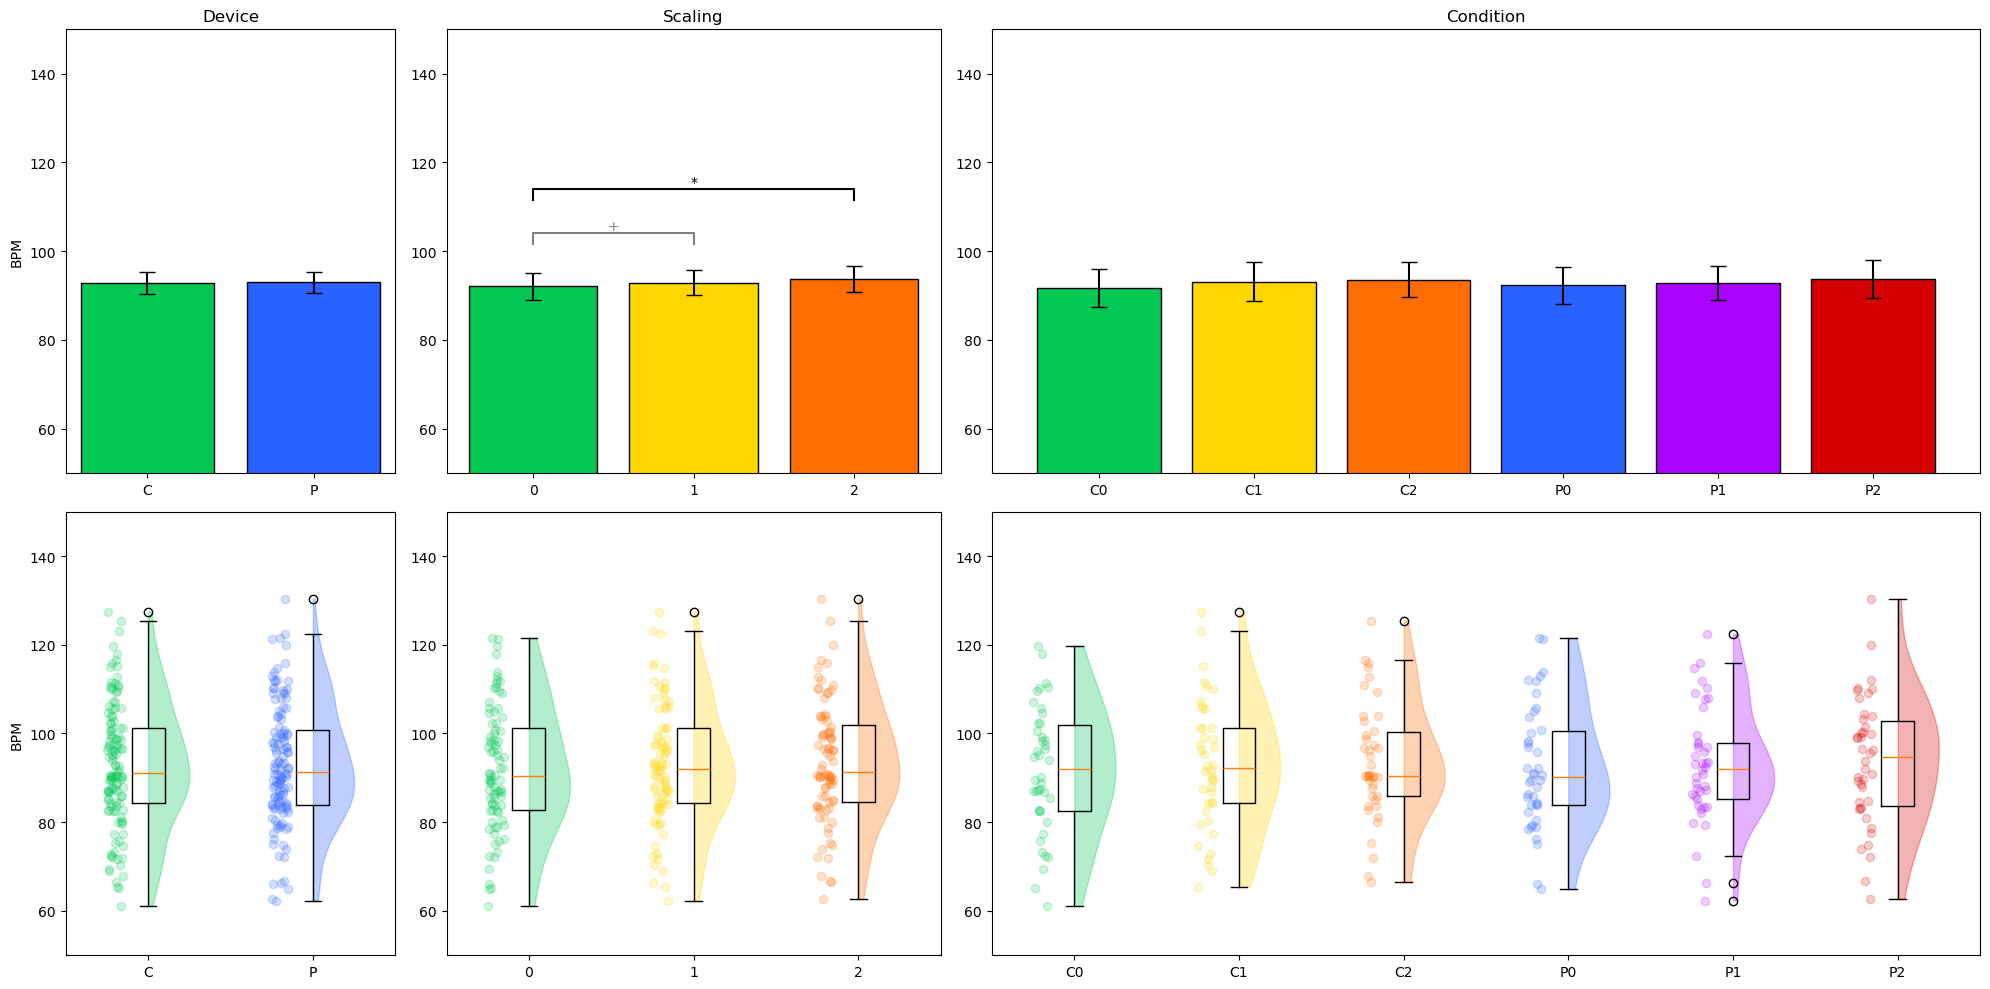

------ [Cube] Sustained Peak Heart Rate ------
Mean & 91.54 & 91.23 & 92.37 & 90.02 & 91.02 & 93.01 \\
Standard Deviation & 13.56 & 12.52 & 12.69 & 13.76 & 15.08 & 13.3 \\
Minimum & 66.0 & 67.9 & 66.6 & 61.4 & 59.0 & 67.3 \\
Maximum & 127.0 & 122.0 & 120.7 & 127.0 & 136.0 & 125.4 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.215278,1,41,8.215278,0.187465,0.667304,0.667304,0.000179,1.000000,❌
1,Scaling,174.018175,2,82,87.009087,1.990759,0.143139,0.144853,0.003768,0.966417,❌
2,Device * Scaling,49.475317,2,82,24.737659,0.478695,0.621312,0.601336,0.001074,0.899111,❌


Device & (1, 41) & 0.19 & 0.667304 & 0.0002 \\
Scaling & (2, 82) & 1.99 & 0.144853 & 0.0038 \\
Device * Scaling & (2, 82) & 0.48 & 0.601336 & 0.0011 \\


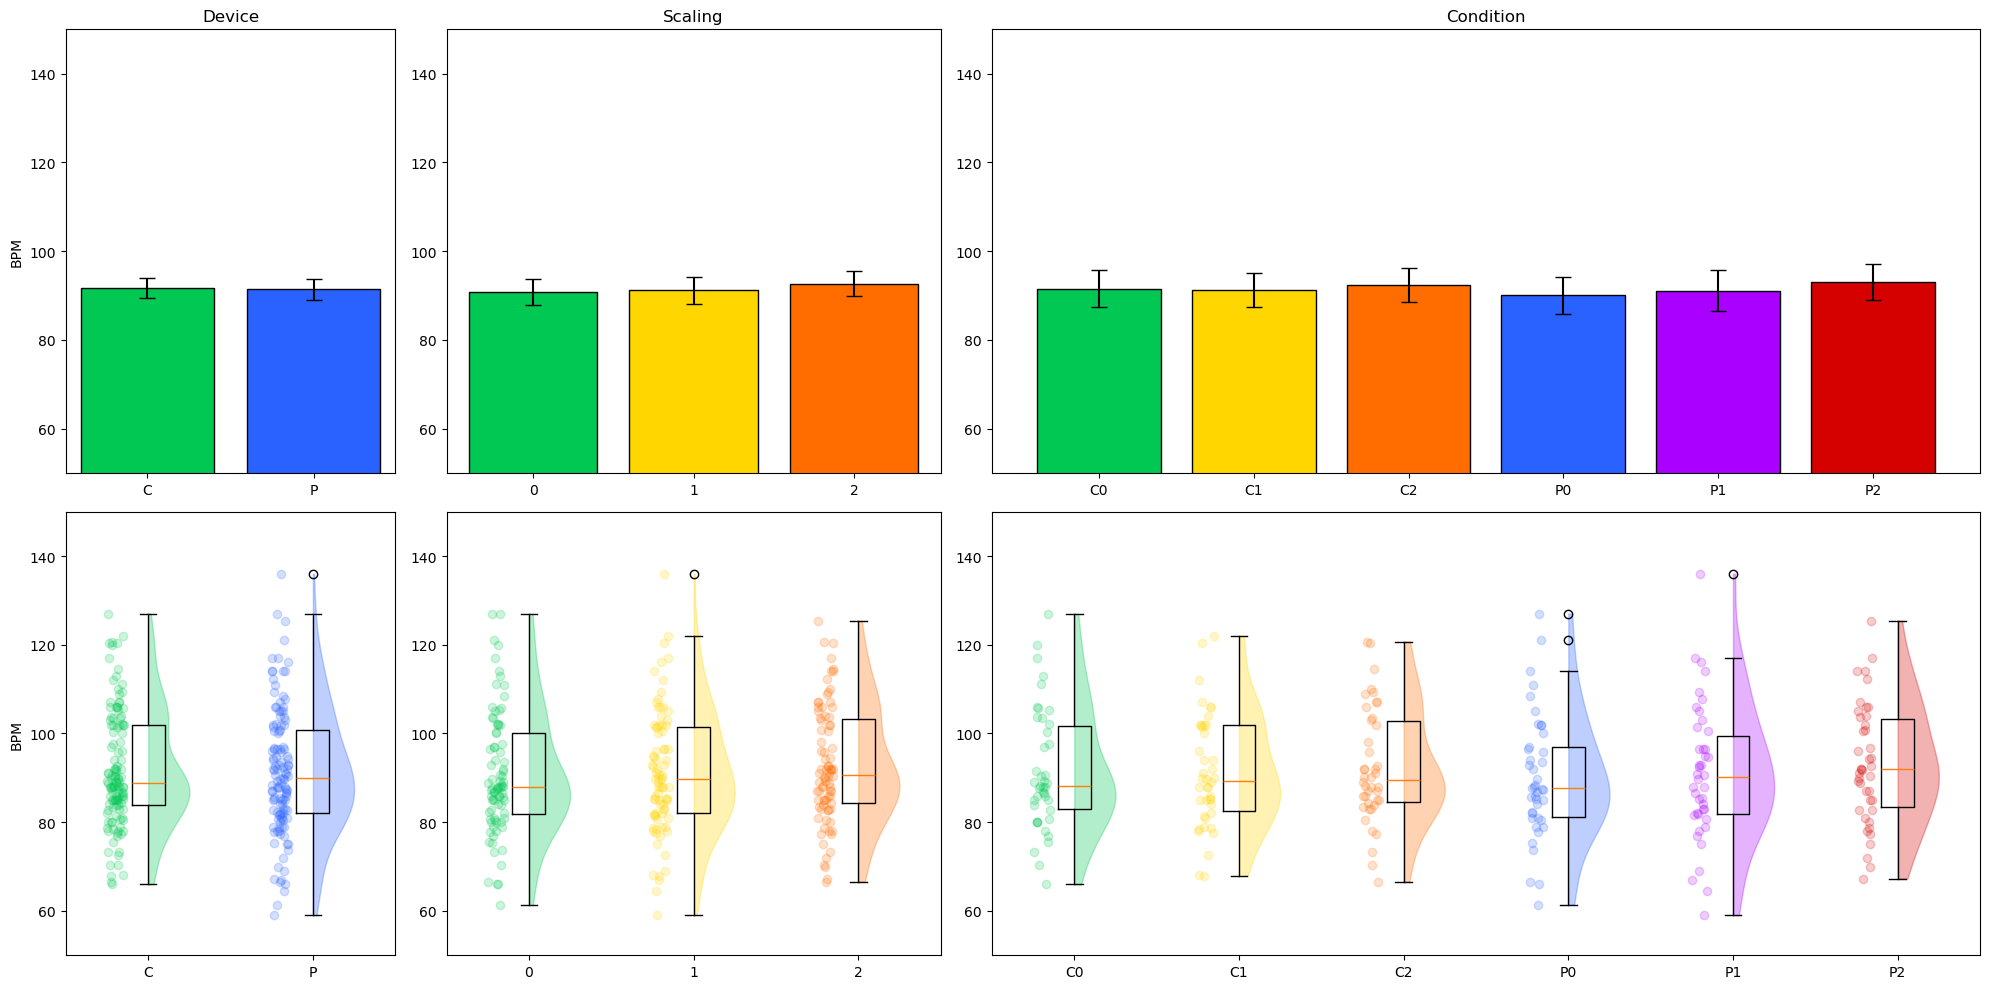

------ [Shovel] Sustained Peak Heart Rate ------
Mean & 100.13 & 101.05 & 101.36 & 101.34 & 101.86 & 101.66 \\
Standard Deviation & 13.94 & 14.64 & 13.08 & 13.46 & 13.19 & 14.68 \\
Minimum & 72.0 & 72.0 & 73.0 & 73.0 & 73.0 & 66.8 \\
Maximum & 133.0 & 142.0 & 141.0 & 136.0 & 139.0 & 147.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,37.568611,1,41,37.568611,1.478322,0.230992,0.230992,0.000777,1.000000,❌
1,Scaling,31.637143,2,82,15.818571,1.094080,0.339685,0.334803,0.000654,0.897272,❌
2,Device * Scaling,8.735556,2,82,4.367778,0.349525,0.706068,0.659847,0.000181,0.805302,❌


Device & (1, 41) & 1.48 & 0.230992 & 0.0008 \\
Scaling & (2, 82) & 1.09 & 0.334803 & 0.0007 \\
Device * Scaling & (2, 82) & 0.35 & 0.659847 & 0.0002 \\


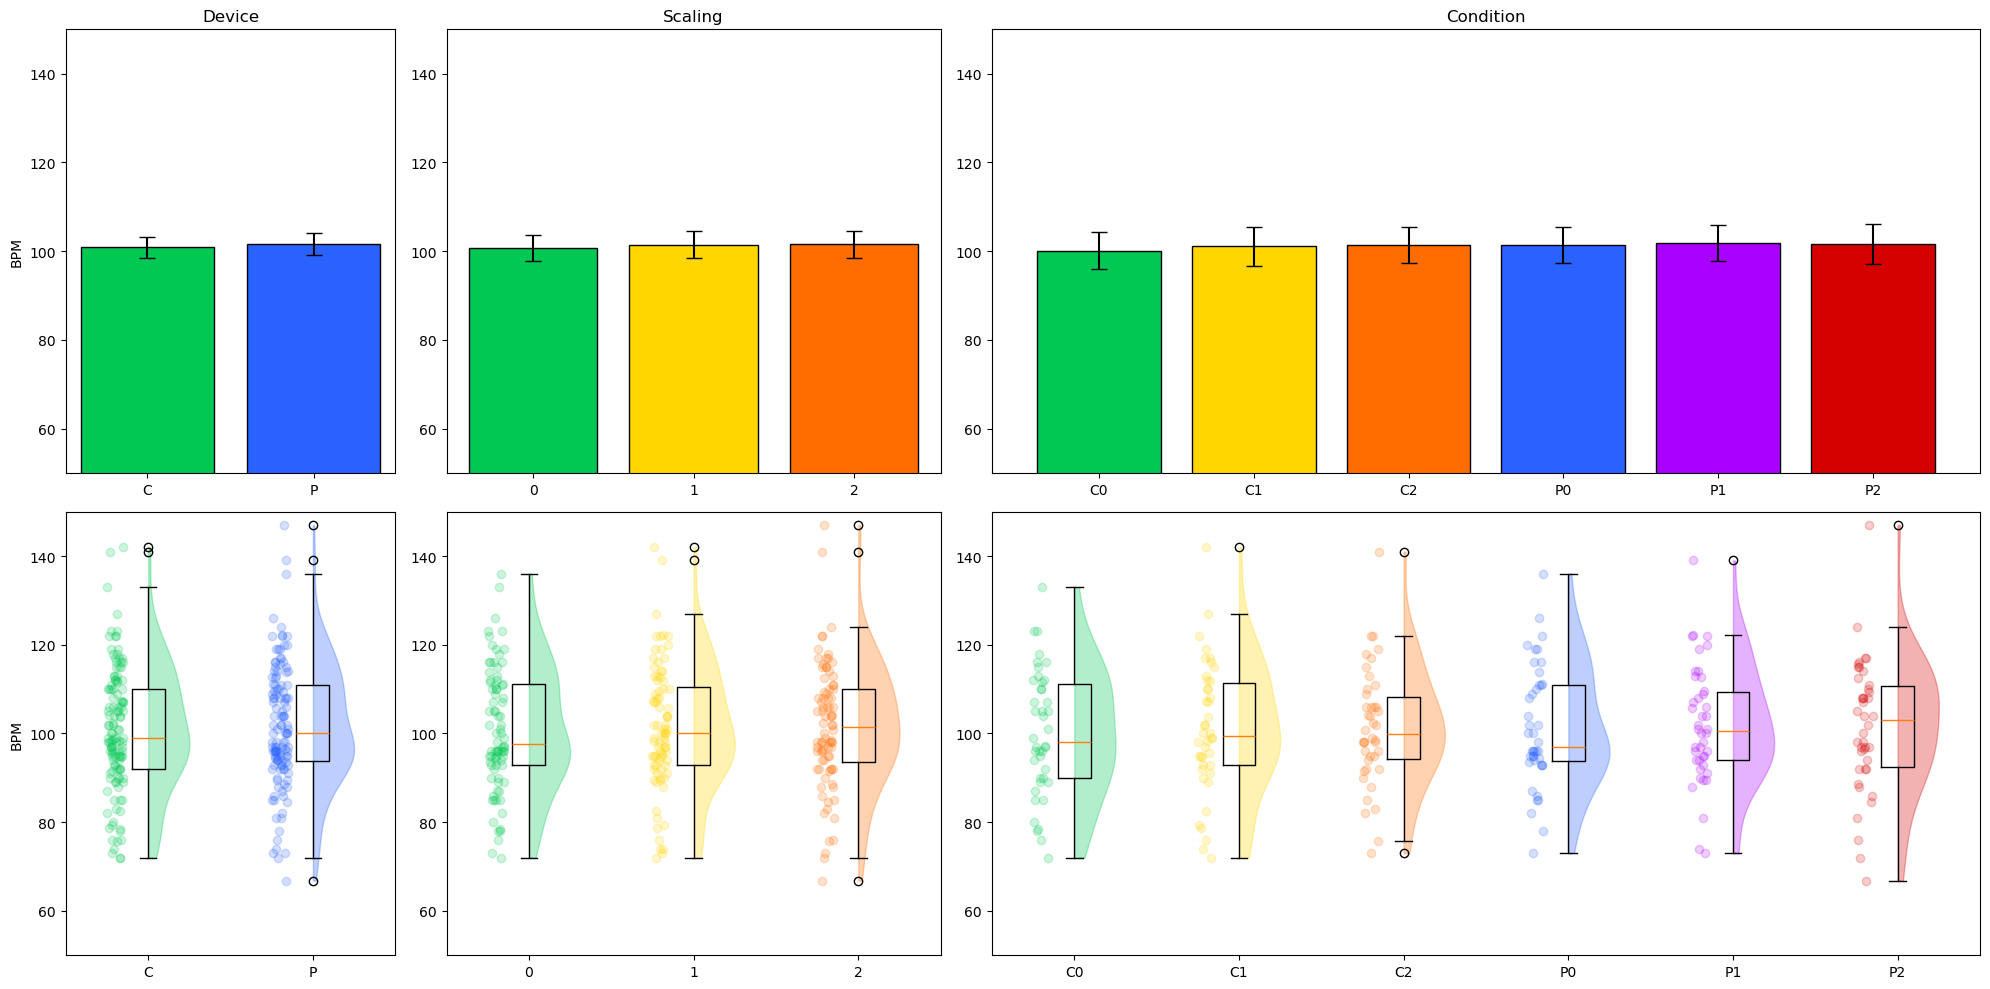

------ [Cube] Heart Rate Delta ------
Mean & 7.48 & 7.69 & 8.47 & 8.41 & 8.53 & 9.57 \\
Standard Deviation & 5.52 & 5.27 & 6.78 & 5.94 & 6.15 & 5.97 \\
Minimum & 0.0 & 1.0 & 1.0 & 0.7 & 1.0 & 1.0 \\
Maximum & 24.0 & 25.0 & 26.0 & 26.3 & 23.9 & 24.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,57.620040,1,41,57.620040,2.119090,0.153088,0.153088,0.006404,1.000000,❌
1,Scaling,56.204127,2,82,28.102063,1.053434,0.353409,0.352079,0.006248,0.974475,❌
2,Device * Scaling,0.748889,2,82,0.374444,0.017992,0.982172,0.965451,0.000084,0.809858,❌


Device & (1, 41) & 2.12 & 0.153088 & 0.0064 \\
Scaling & (2, 82) & 1.05 & 0.352079 & 0.0062 \\
Device * Scaling & (2, 82) & 0.02 & 0.965451 & 0.0001 \\


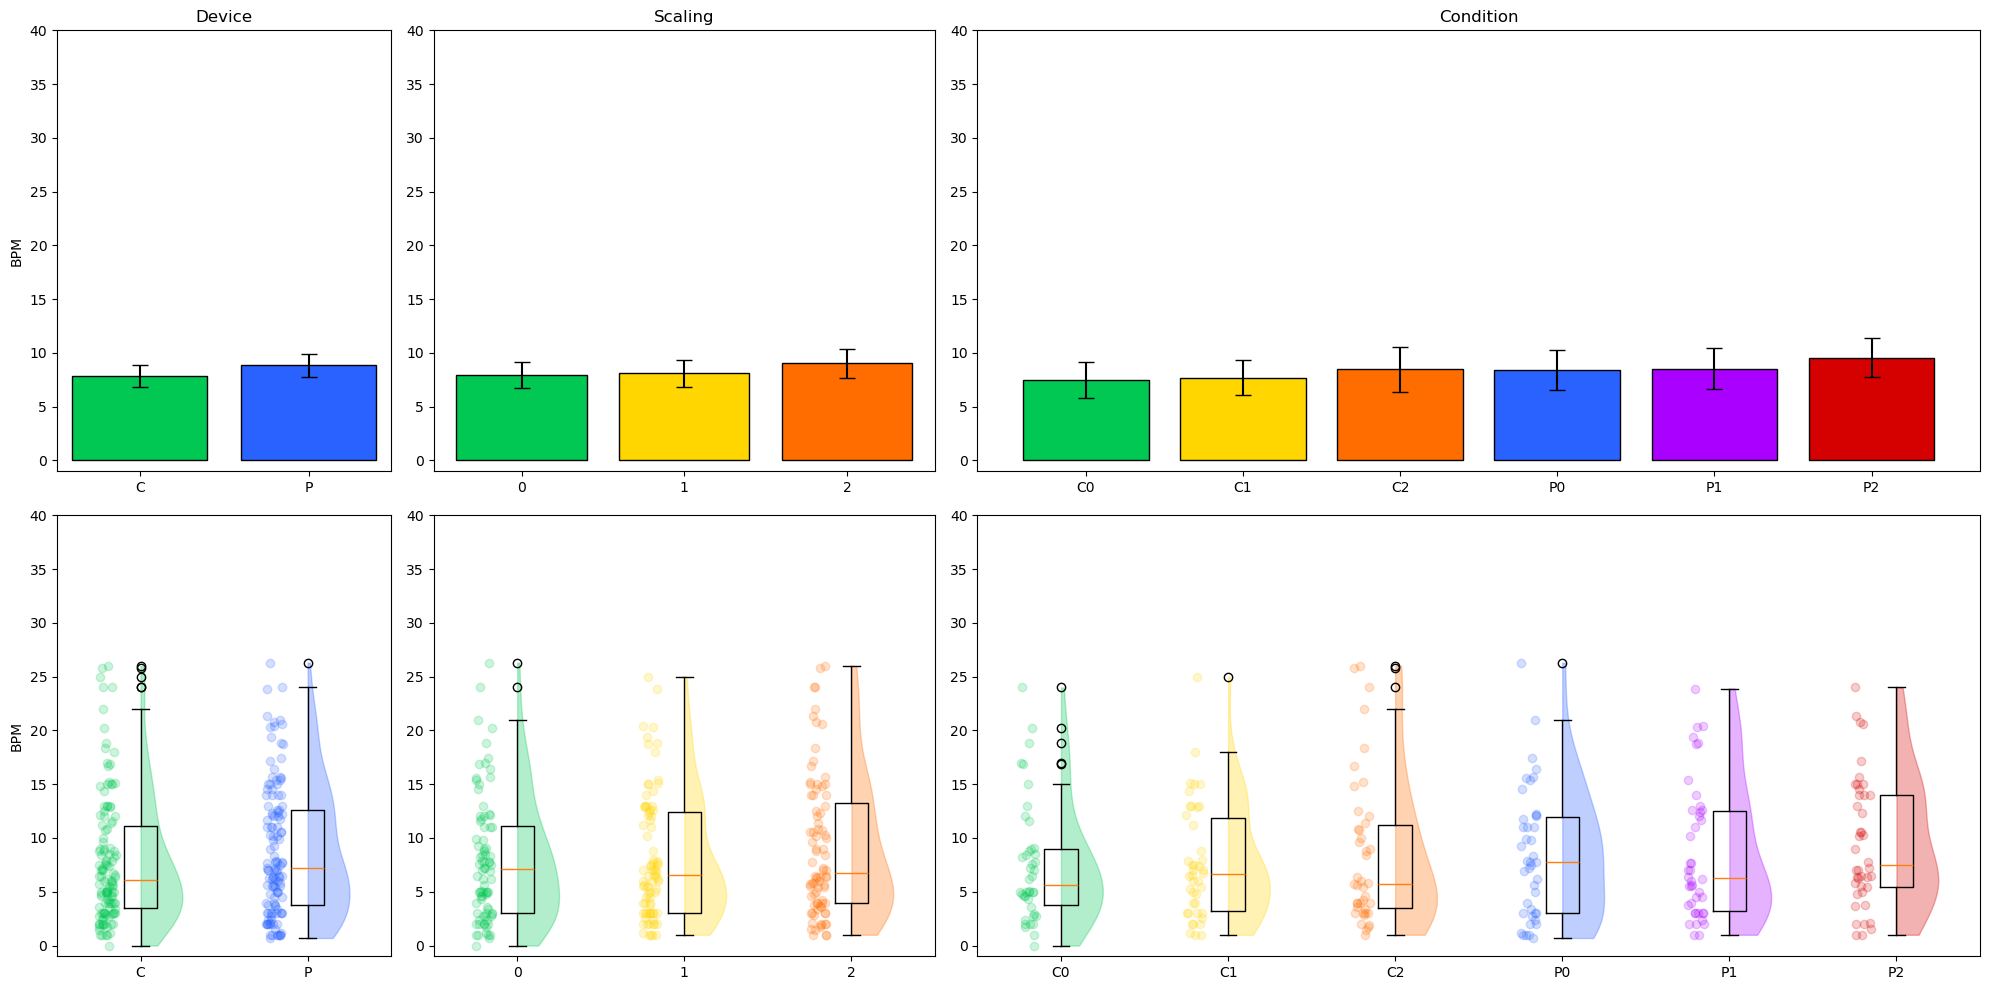

------ [Shovel] Heart Rate Delta ------
Mean & 16.86 & 16.6 & 16.74 & 17.9 & 19.73 & 17.3 \\
Standard Deviation & 6.78 & 6.74 & 6.75 & 7.67 & 6.73 & 7.84 \\
Minimum & 7.0 & 3.0 & 5.0 & 3.0 & 10.0 & 5.4 \\
Maximum & 34.0 & 34.0 & 36.0 & 35.0 & 38.0 & 38.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,156.200635,1,41,156.200635,4.834828,0.033589,0.033589,0.012141,1.000000,✅
1,Scaling,57.386270,2,82,28.693135,1.416168,0.248513,0.248755,0.004495,0.959115,❌
2,Device * Scaling,77.773889,2,82,38.886944,1.392907,0.254166,0.254271,0.006082,0.966643,❌


Device & (1, 41) & 4.83 & \textbf{0.033589} & 0.0121 \\
Scaling & (2, 82) & 1.42 & 0.248755 & 0.0045 \\
Device * Scaling & (2, 82) & 1.39 & 0.254271 & 0.0061 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.198824,41.0,two-sided,0.033589,NaN,NaN,1.449,-0.261467,✅


Device P-C & 41 & 2.2 & \textbf{0.033589} & 0.2615 \\


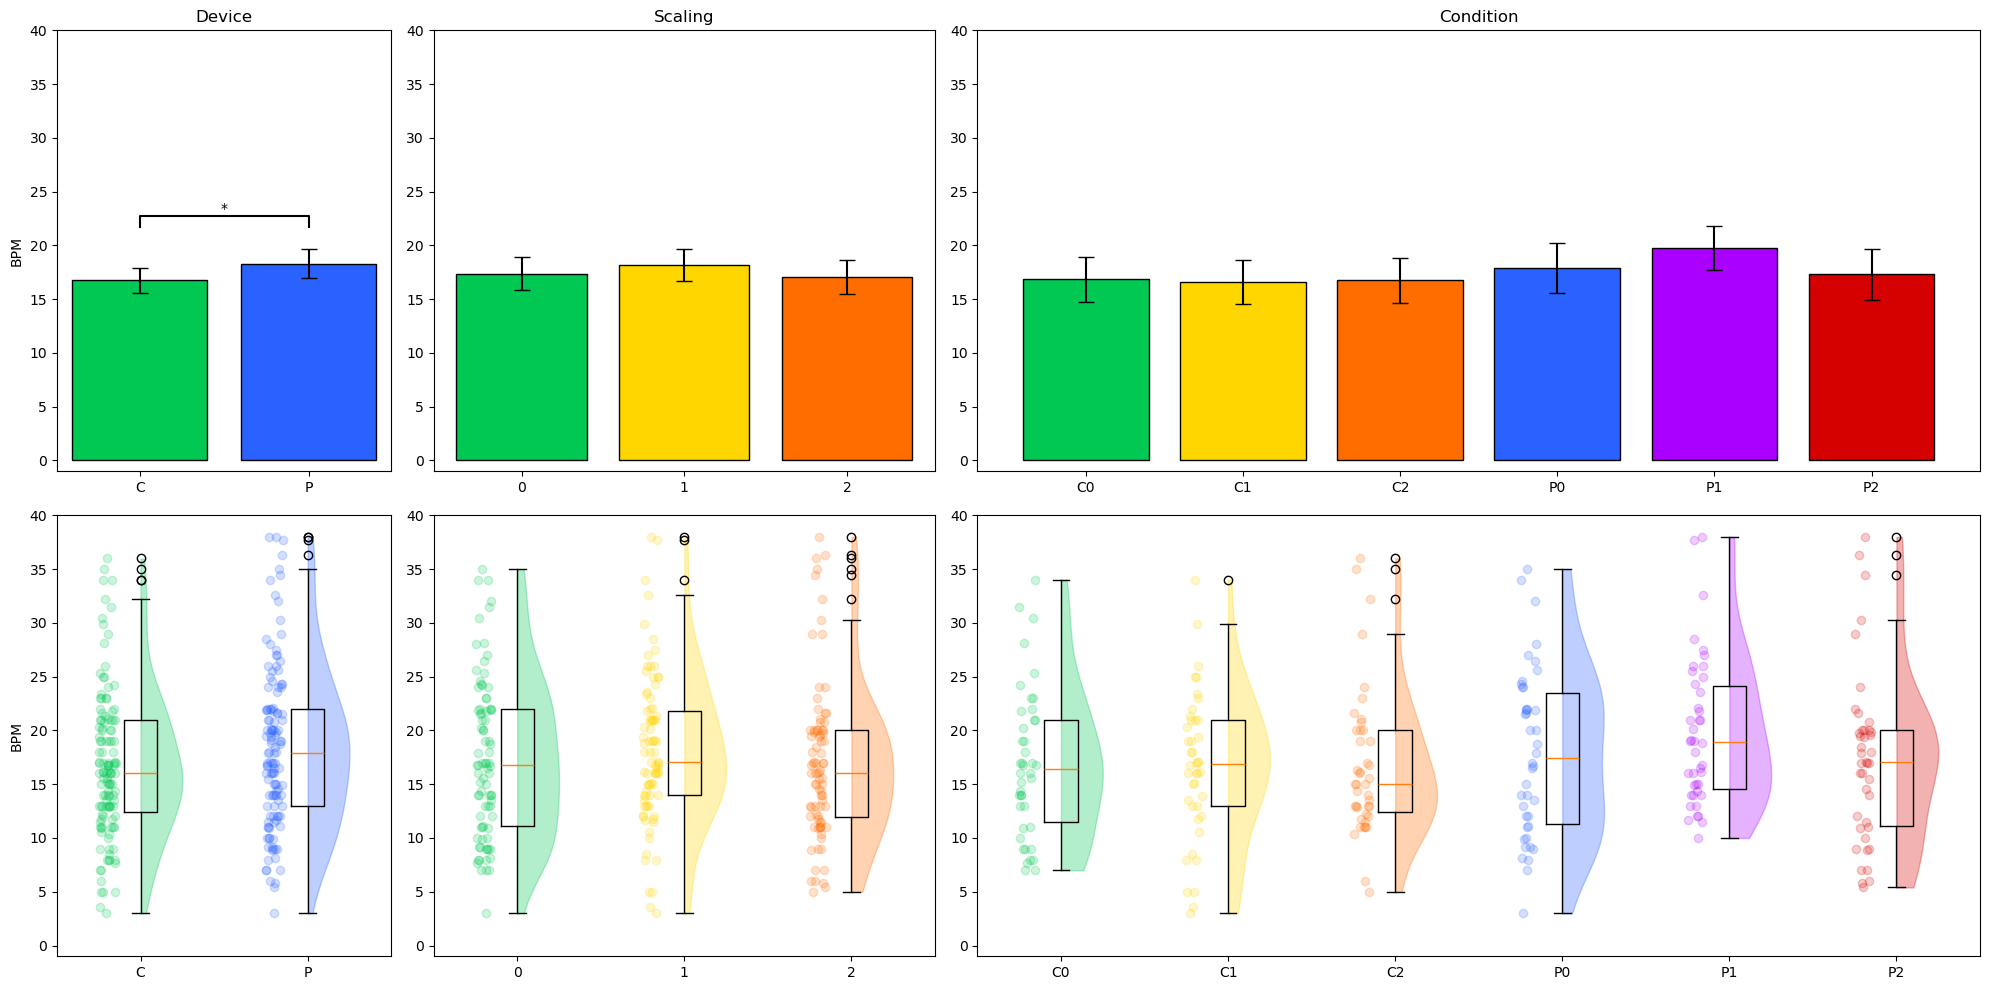

{'aov':              Source          SS  ddof1  ddof2          MS         F     p-unc  \
 0            Device  156.200635      1     41  156.200635  4.834828  0.033589   
 1           Scaling   57.386270      2     82   28.693135  1.416168  0.248513   
 2  Device * Scaling   77.773889      2     82   38.886944  1.392907  0.254166   
 
    p-GG-corr       ng2       eps Significance  
 0   0.033589  0.012141  1.000000            ✅  
 1   0.248755  0.004495  0.959115            ❌  
 2   0.254271  0.006082  0.966643            ❌  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -2.198824  41.0   two-sided   
 
       p-unc  p-corr p-adjust   BF10    hedges Significance  
 0  0.033589     NaN      NaN  1.449 -0.261467            ✅  }

In [24]:
ylabel = 'BPM'
ylim = [50, 150]

title = 'Mean Heart Rate'
def hr_mean(p): return mean_val(p, hr_key)
report_exeriment(data, hr_mean, cube, title, ylabel, ylim)
report_exeriment(data, hr_mean, shovel, title, ylabel, ylim)

title = 'Heart Rate Normalized AUC'
def hr_auc(p): return normalized_auc(p, hr_key)
report_exeriment(data, hr_auc, cube, title, ylabel, ylim)
report_exeriment(data, hr_auc, shovel, title, ylabel, ylim)

title = 'Sustained Peak Heart Rate'
def hr_peak(p): return peak_val(p, hr_key)
report_exeriment(data, hr_peak, cube, title, ylabel, ylim)
report_exeriment(data, hr_peak, shovel, title, ylabel, ylim)

title = 'Heart Rate Delta'
ylim = [-1, 40]
def hr_delta(p): return delta_val(p, hr_key)
report_exeriment(data, hr_delta, cube, title, ylabel, ylim)
report_exeriment(data, hr_delta, shovel, title, ylabel, ylim)

------ [Cube] Mean Skin Conductance ------
Mean & 7.04 & 7.36 & 7.09 & 6.52 & 6.35 & 7.43 \\
Standard Deviation & 4.87 & 5.54 & 5.32 & 3.95 & 4.26 & 5.9 \\
Minimum & 1.17 & 1.44 & 1.81 & 0.95 & 1.18 & 1.53 \\
Maximum & 18.51 & 20.06 & 22.62 & 18.23 & 18.32 & 24.07 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.795457,1,41,9.795457,2.968790,0.092421,0.092421,0.001540,1.000000,🟨
1,Scaling,11.349200,2,82,5.674600,1.343702,0.266561,0.260088,0.001784,0.629555,❌
2,Device * Scaling,19.859480,2,82,9.929740,3.044654,0.053029,0.077172,0.003117,0.639080,🟨


Device & (1, 41) & 2.97 & 0.092421 & 0.0015 \\
Scaling & (2, 82) & 1.34 & 0.260088 & 0.0018 \\
Device * Scaling & (2, 82) & 3.04 & 0.077172 & 0.0031 \\


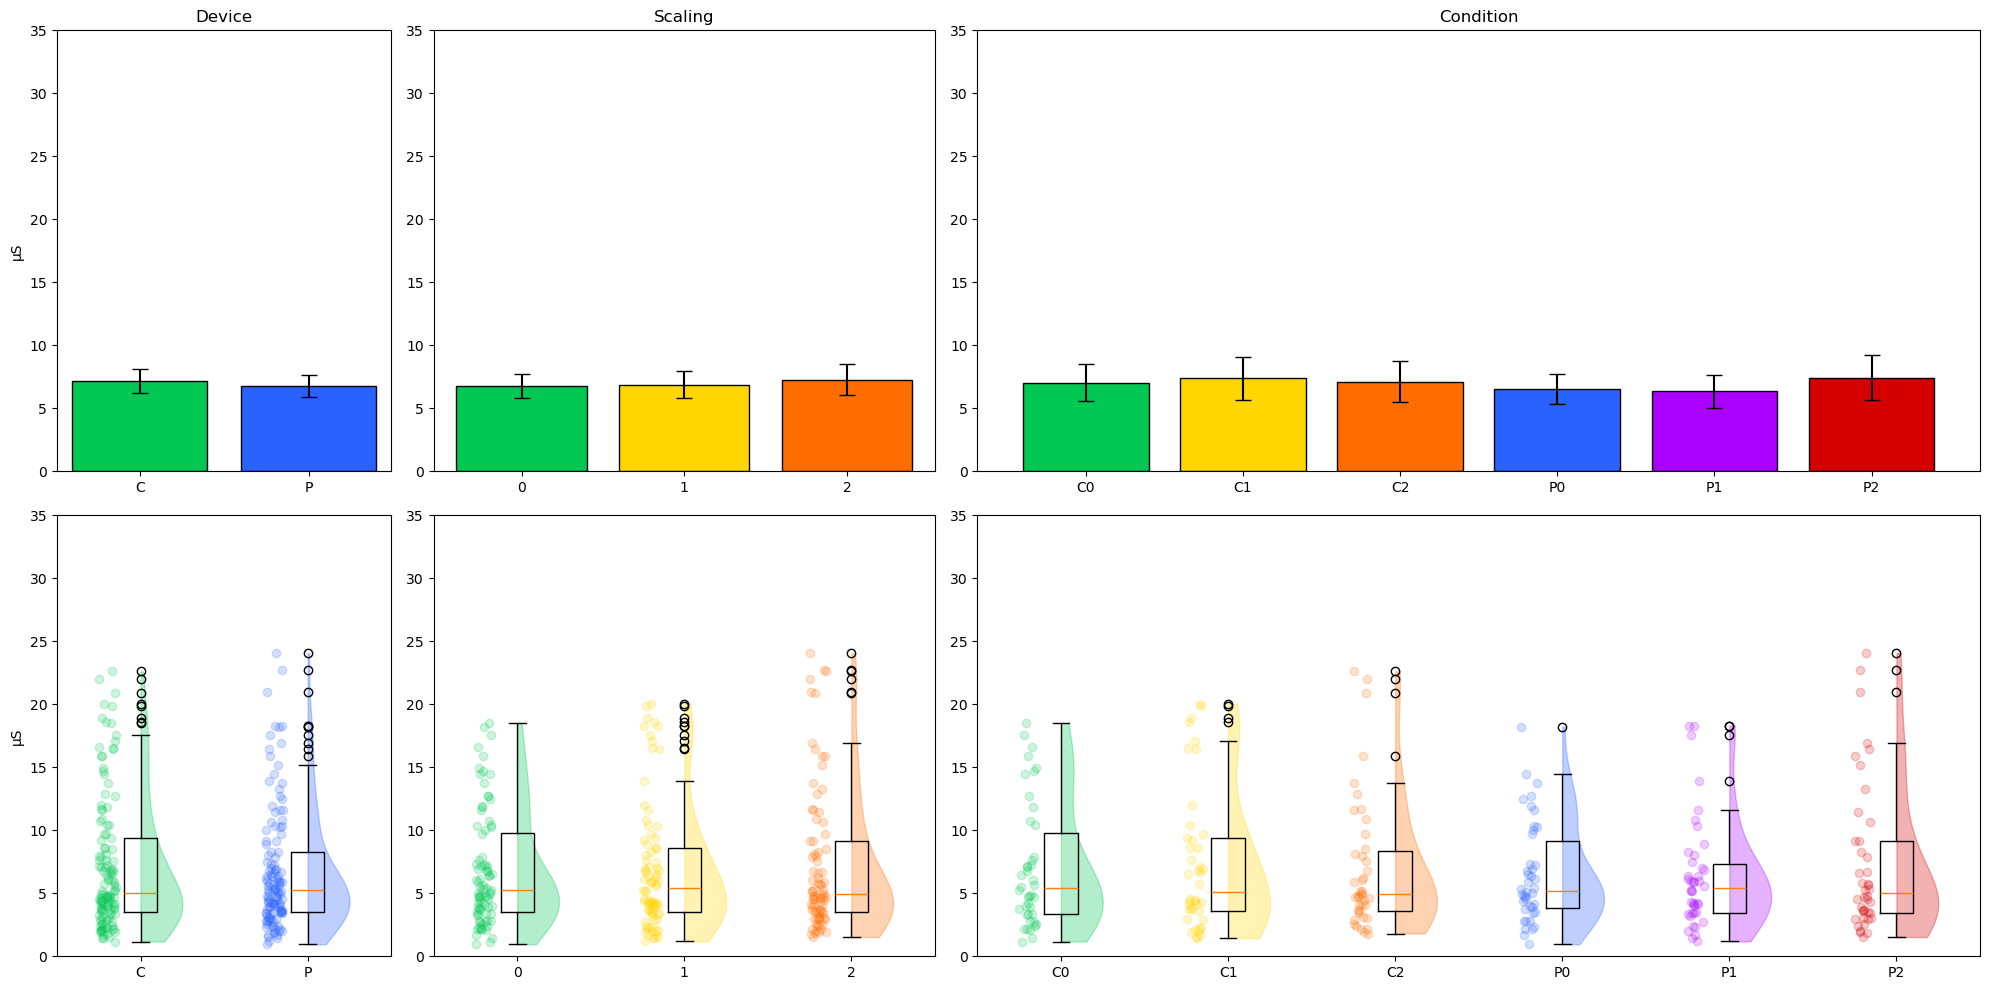

------ [Shovel] Mean Skin Conductance ------
Mean & 11.25 & 11.19 & 11.0 & 11.18 & 11.14 & 11.4 \\
Standard Deviation & 6.53 & 6.81 & 6.29 & 5.85 & 5.81 & 6.64 \\
Minimum & 2.74 & 2.81 & 2.84 & 2.83 & 2.71 & 2.68 \\
Maximum & 28.53 & 30.56 & 30.92 & 27.0 & 28.81 & 29.08 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553842,1,41,0.553842,0.354366,0.554924,0.554924,0.000055,1.000000,❌
1,Scaling,0.099651,2,82,0.049825,0.049382,0.951846,0.882025,0.000010,0.646207,❌
2,Device * Scaling,2.886870,2,82,1.443435,1.189137,0.309679,0.288961,0.000285,0.574847,❌


Device & (1, 41) & 0.35 & 0.554924 & 0.0001 \\
Scaling & (2, 82) & 0.05 & 0.882025 & 0.0 \\
Device * Scaling & (2, 82) & 1.19 & 0.288961 & 0.0003 \\


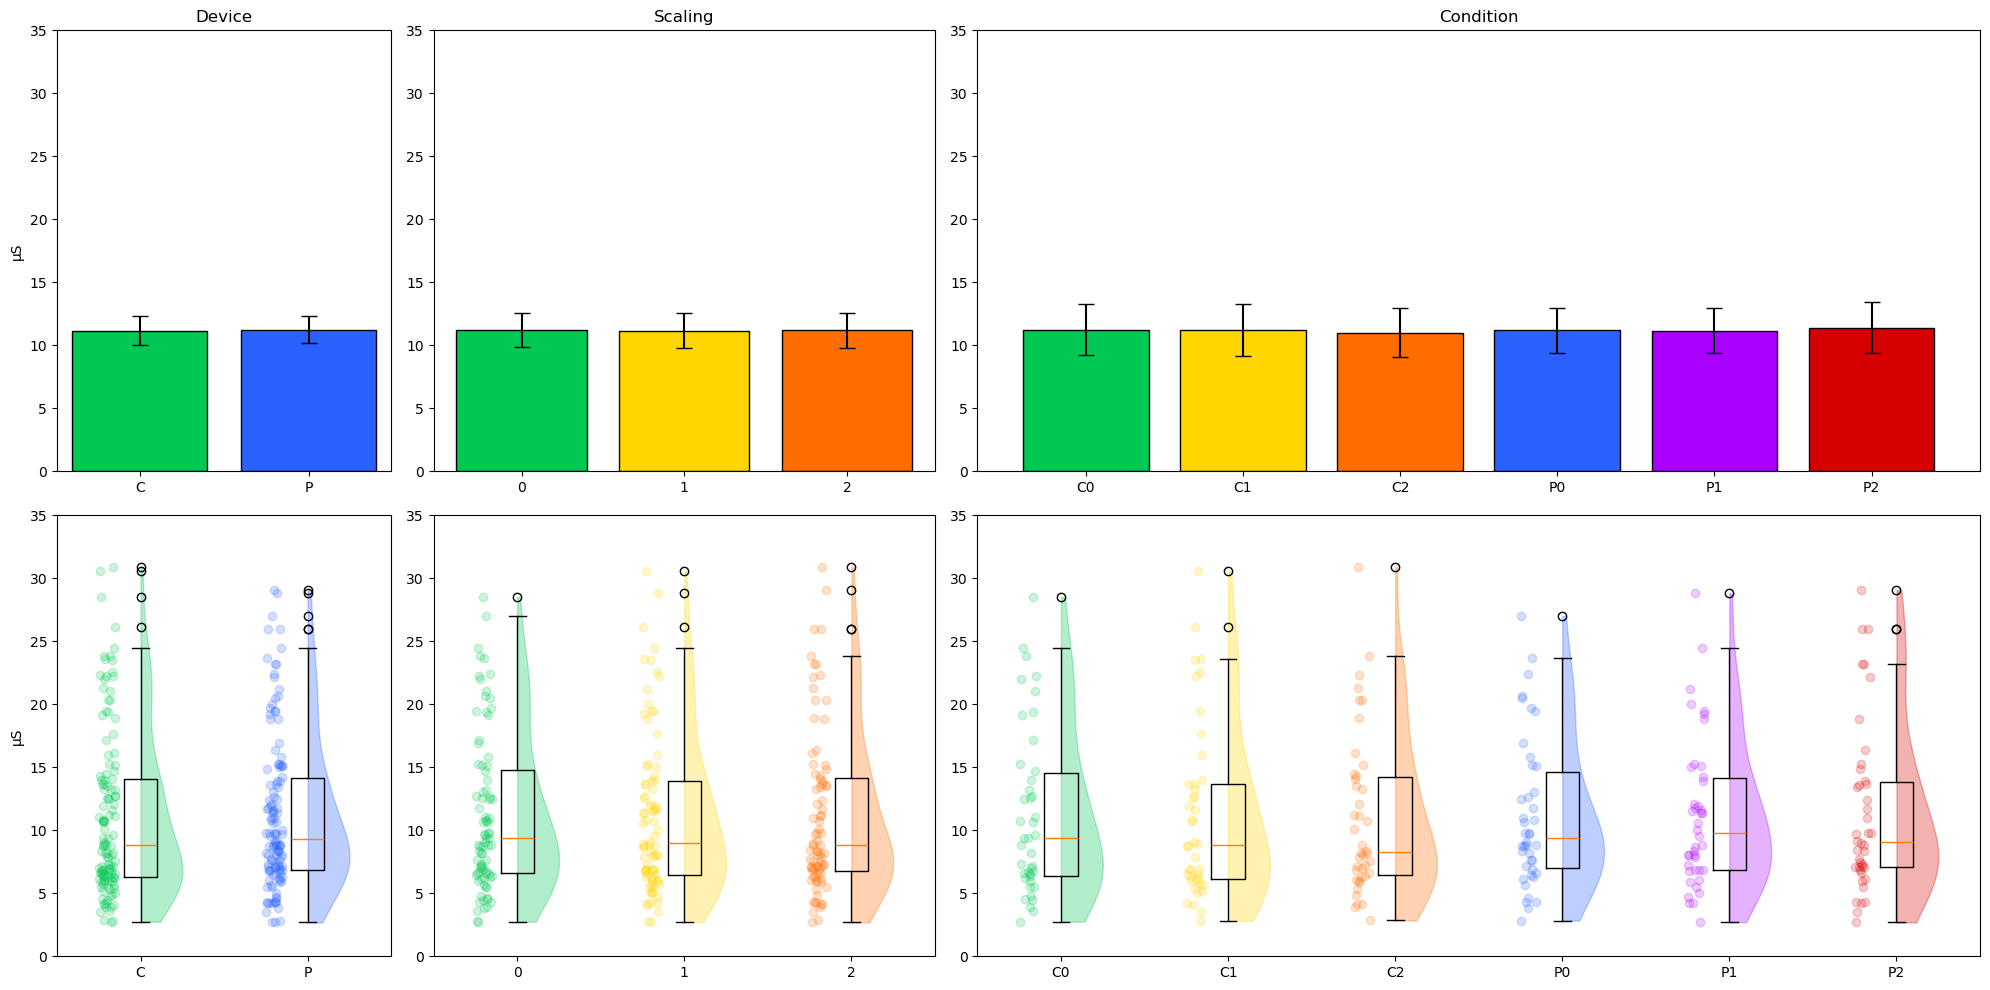

------ [Cube] Skin Conductance Normalized AUC ------
Mean & 7.03 & 7.36 & 7.08 & 6.51 & 6.35 & 7.43 \\
Standard Deviation & 4.87 & 5.53 & 5.32 & 3.94 & 4.26 & 5.9 \\
Minimum & 1.17 & 1.44 & 1.81 & 0.95 & 1.18 & 1.53 \\
Maximum & 18.5 & 20.05 & 22.61 & 18.22 & 18.31 & 24.06 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.765031,1,41,9.765031,2.965431,0.092599,0.092599,0.001537,1.000000,🟨
1,Scaling,11.354241,2,82,5.677120,1.345760,0.266030,0.259679,0.001786,0.629590,❌
2,Device * Scaling,19.842592,2,82,9.921296,3.046500,0.052938,0.077062,0.003118,0.639251,🟨


Device & (1, 41) & 2.97 & 0.092599 & 0.0015 \\
Scaling & (2, 82) & 1.35 & 0.259679 & 0.0018 \\
Device * Scaling & (2, 82) & 3.05 & 0.077062 & 0.0031 \\


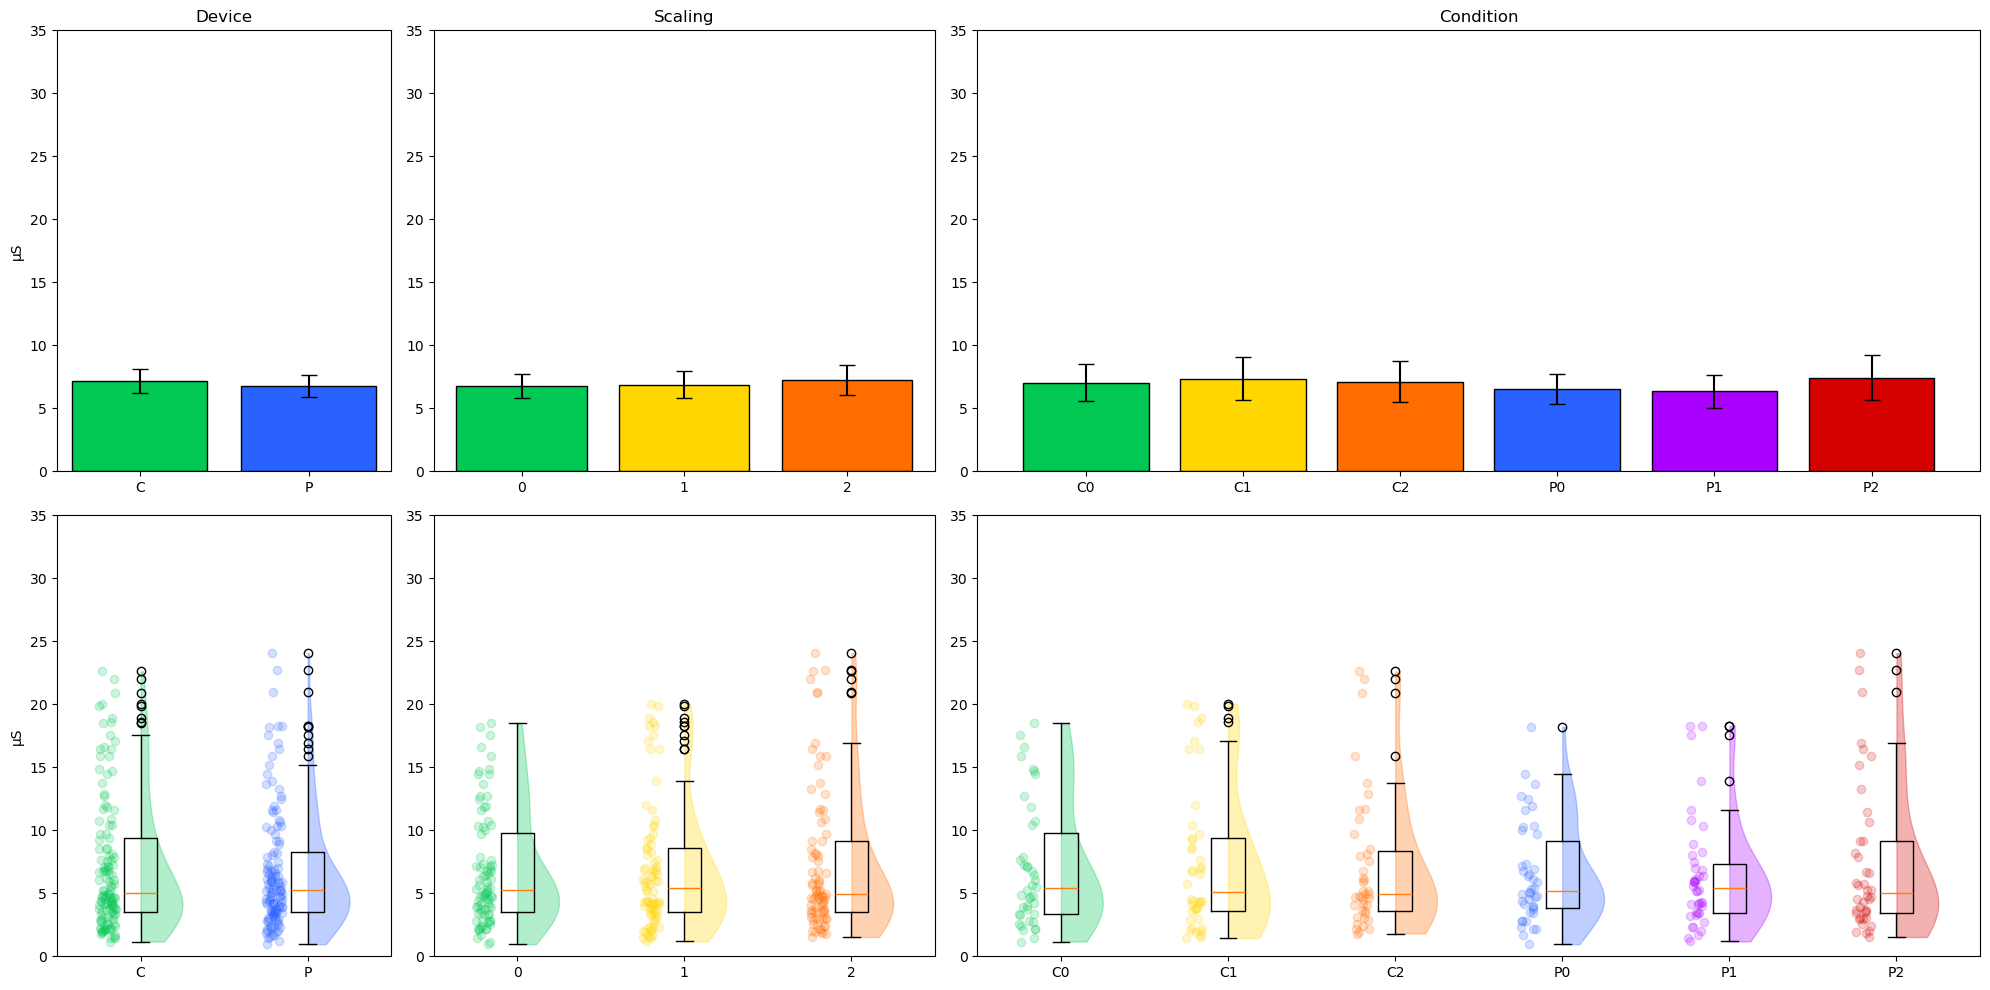

------ [Shovel] Skin Conductance Normalized AUC ------
Mean & 11.25 & 11.19 & 11.0 & 11.18 & 11.14 & 11.4 \\
Standard Deviation & 6.53 & 6.81 & 6.29 & 5.85 & 5.81 & 6.64 \\
Minimum & 2.74 & 2.81 & 2.84 & 2.83 & 2.71 & 2.68 \\
Maximum & 28.53 & 30.56 & 30.91 & 26.99 & 28.81 & 29.07 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553750,1,41,0.553750,0.354369,0.554922,0.554922,0.000055,1.000000,❌
1,Scaling,0.099541,2,82,0.049770,0.049350,0.951876,0.882070,0.000010,0.646199,❌
2,Device * Scaling,2.883409,2,82,1.441704,1.188249,0.309947,0.289162,0.000285,0.574937,❌


Device & (1, 41) & 0.35 & 0.554922 & 0.0001 \\
Scaling & (2, 82) & 0.05 & 0.88207 & 0.0 \\
Device * Scaling & (2, 82) & 1.19 & 0.289162 & 0.0003 \\


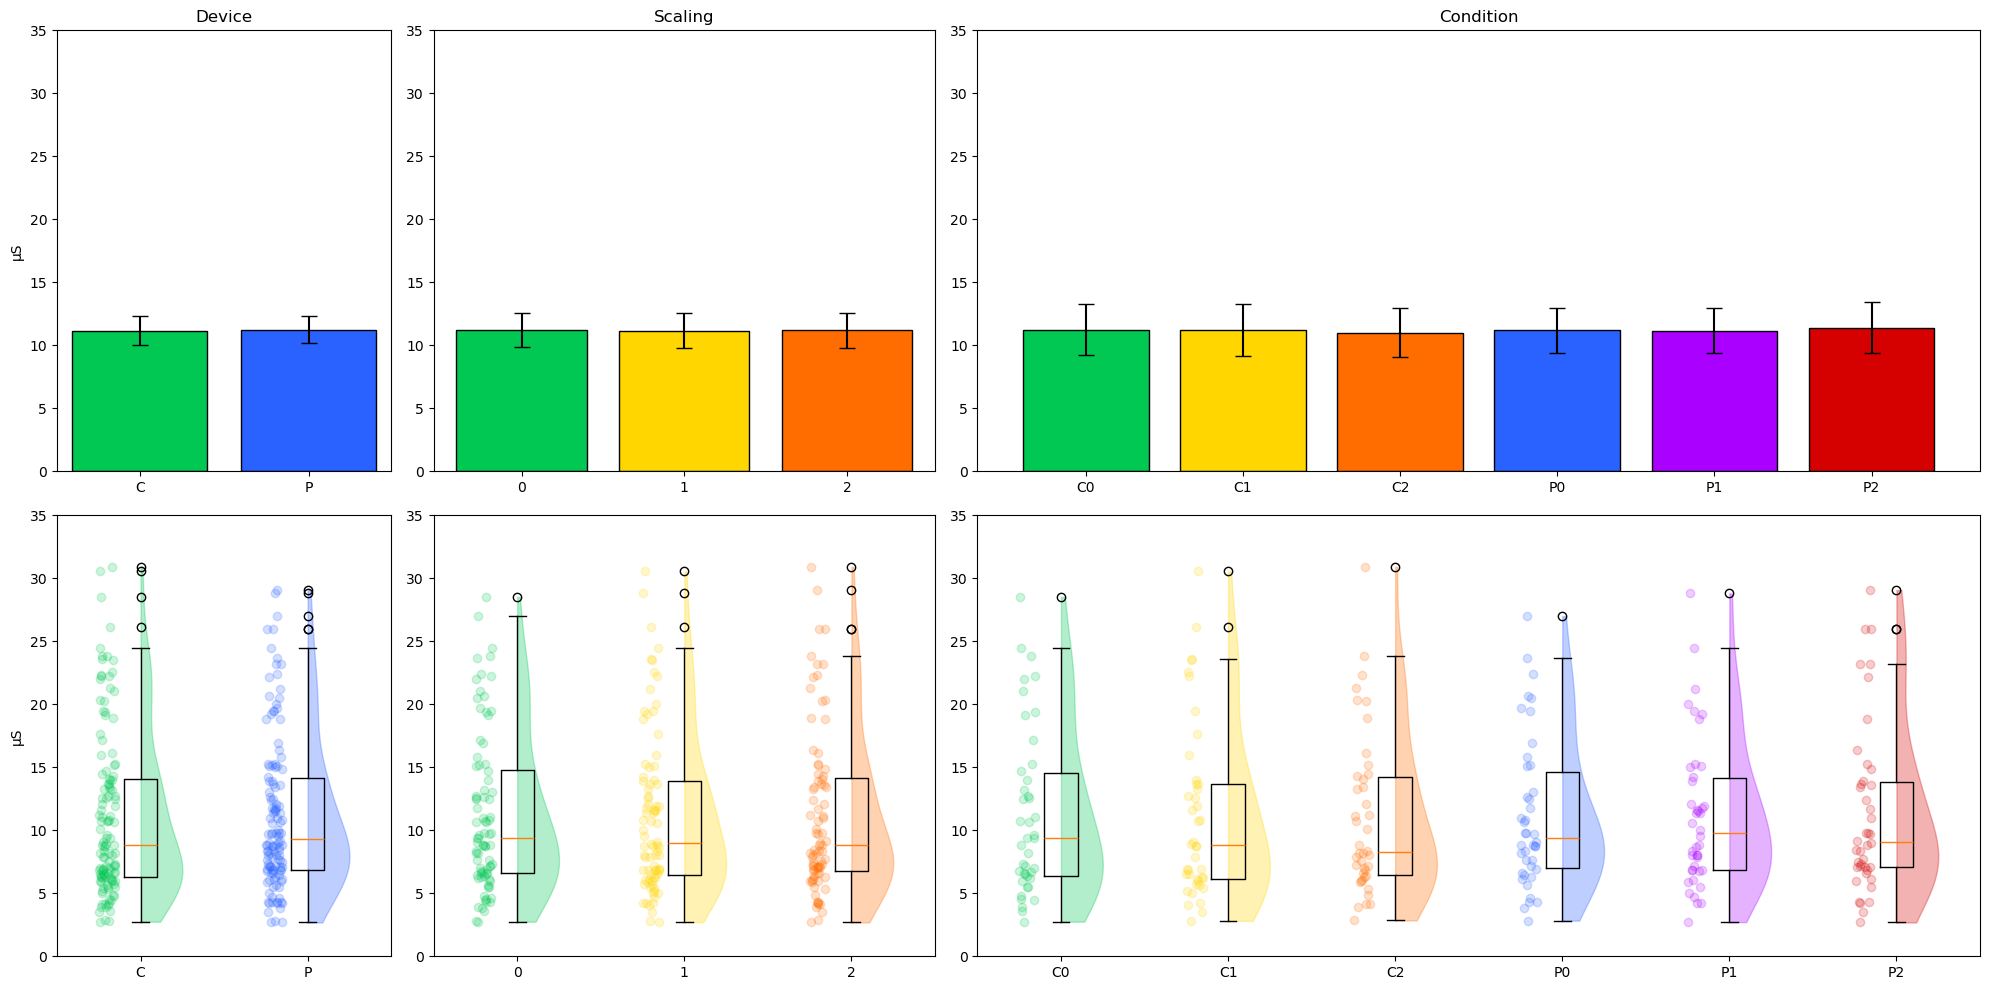

------ [Cube] Sustained Peak Skin Conductance ------
Mean & 7.27 & 7.61 & 7.42 & 6.93 & 6.74 & 7.91 \\
Standard Deviation & 5.0 & 5.66 & 5.55 & 4.11 & 4.41 & 6.13 \\
Minimum & 1.24 & 1.46 & 1.85 & 1.01 & 1.57 & 1.61 \\
Maximum & 19.12 & 20.65 & 23.93 & 18.83 & 19.08 & 25.53 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.568752,1,41,3.568752,1.232539,0.273383,0.273383,0.000525,1.000000,❌
1,Scaling,15.740759,2,82,7.870379,1.733870,0.183011,0.194325,0.002311,0.620245,❌
2,Device * Scaling,20.084506,2,82,10.042253,2.989213,0.055840,0.076141,0.002947,0.691073,🟨


Device & (1, 41) & 1.23 & 0.273383 & 0.0005 \\
Scaling & (2, 82) & 1.73 & 0.194325 & 0.0023 \\
Device * Scaling & (2, 82) & 2.99 & 0.076141 & 0.0029 \\


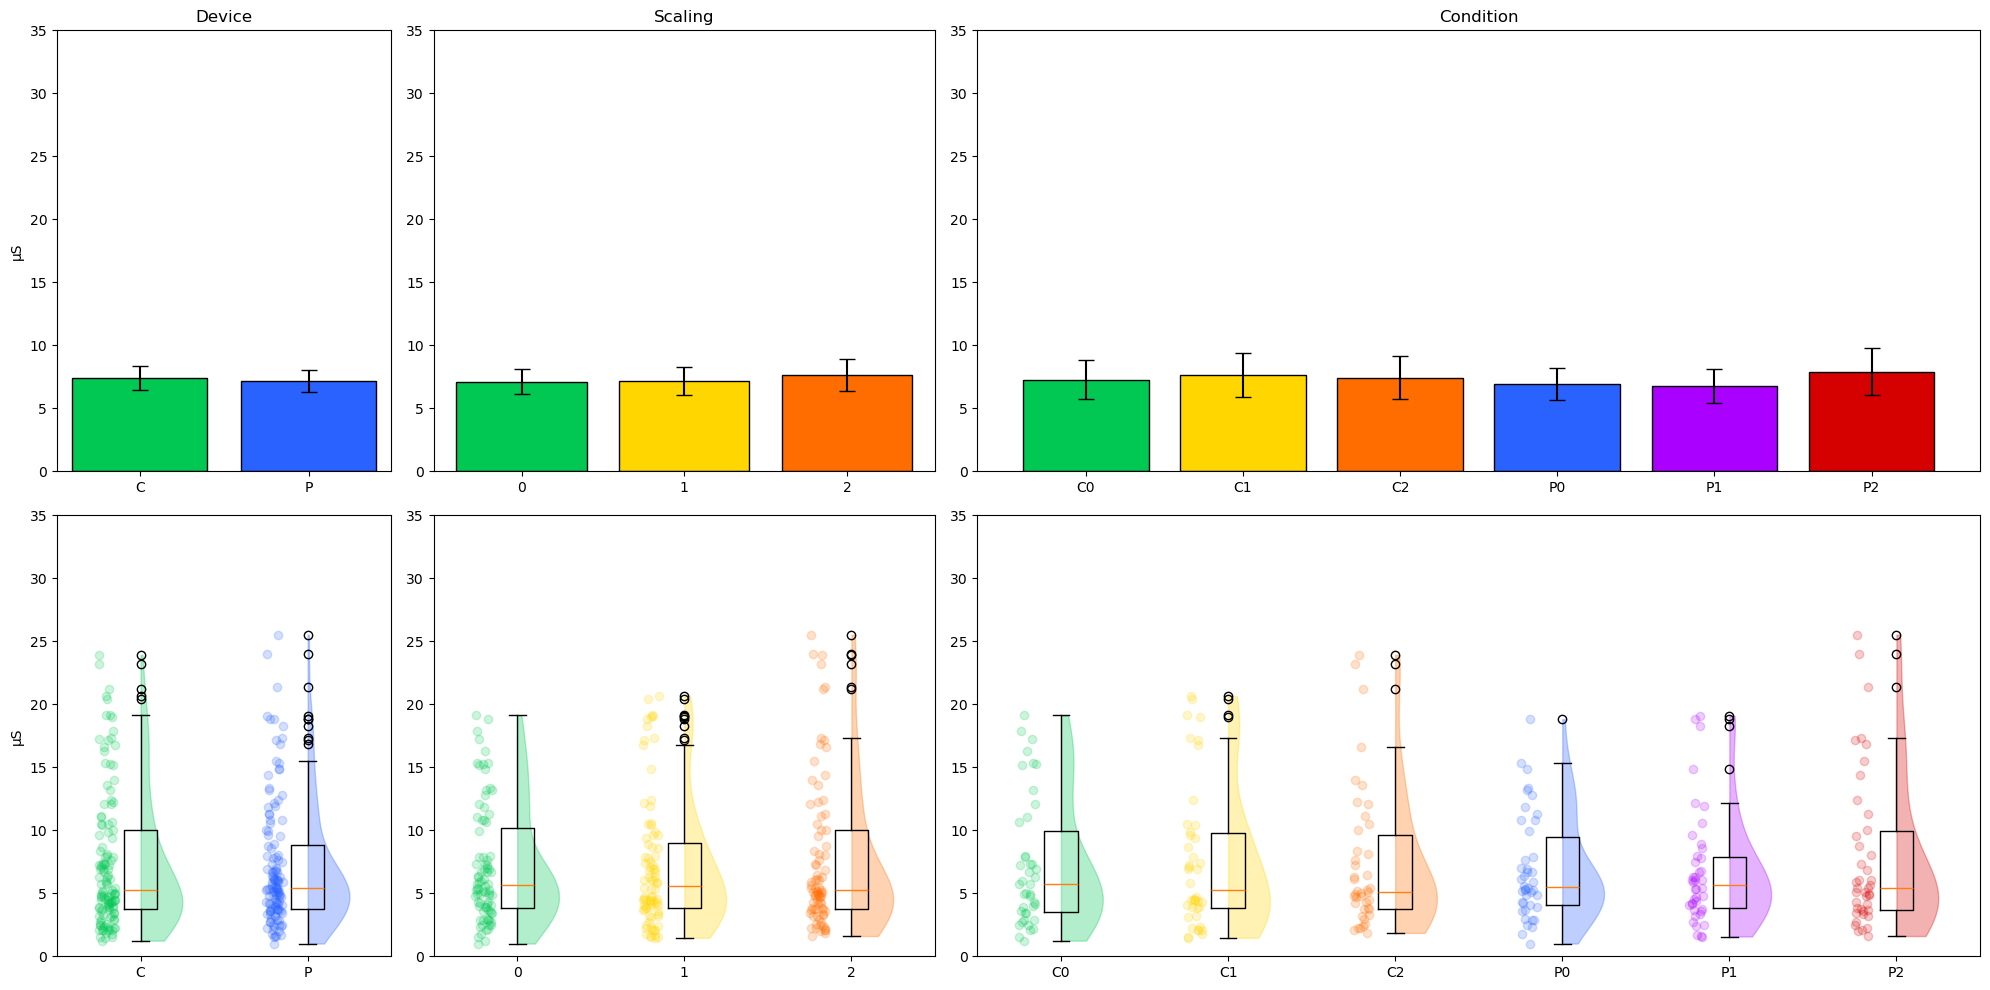

------ [Shovel] Sustained Peak Skin Conductance ------
Mean & 11.75 & 11.7 & 11.55 & 11.77 & 11.79 & 12.02 \\
Standard Deviation & 6.84 & 7.1 & 6.61 & 6.1 & 6.16 & 6.88 \\
Minimum & 2.85 & 2.9 & 2.97 & 2.96 & 2.86 & 2.77 \\
Maximum & 30.16 & 32.38 & 32.86 & 28.74 & 31.73 & 30.09 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.431900,1,41,2.431900,1.582693,0.215491,0.215491,0.000220,1.000000,❌
1,Scaling,0.064584,2,82,0.032292,0.027164,0.973210,0.934738,0.000006,0.712520,❌
2,Device * Scaling,2.400484,2,82,1.200242,0.859115,0.427313,0.377138,0.000217,0.595581,❌


Device & (1, 41) & 1.58 & 0.215491 & 0.0002 \\
Scaling & (2, 82) & 0.03 & 0.934738 & 0.0 \\
Device * Scaling & (2, 82) & 0.86 & 0.377138 & 0.0002 \\


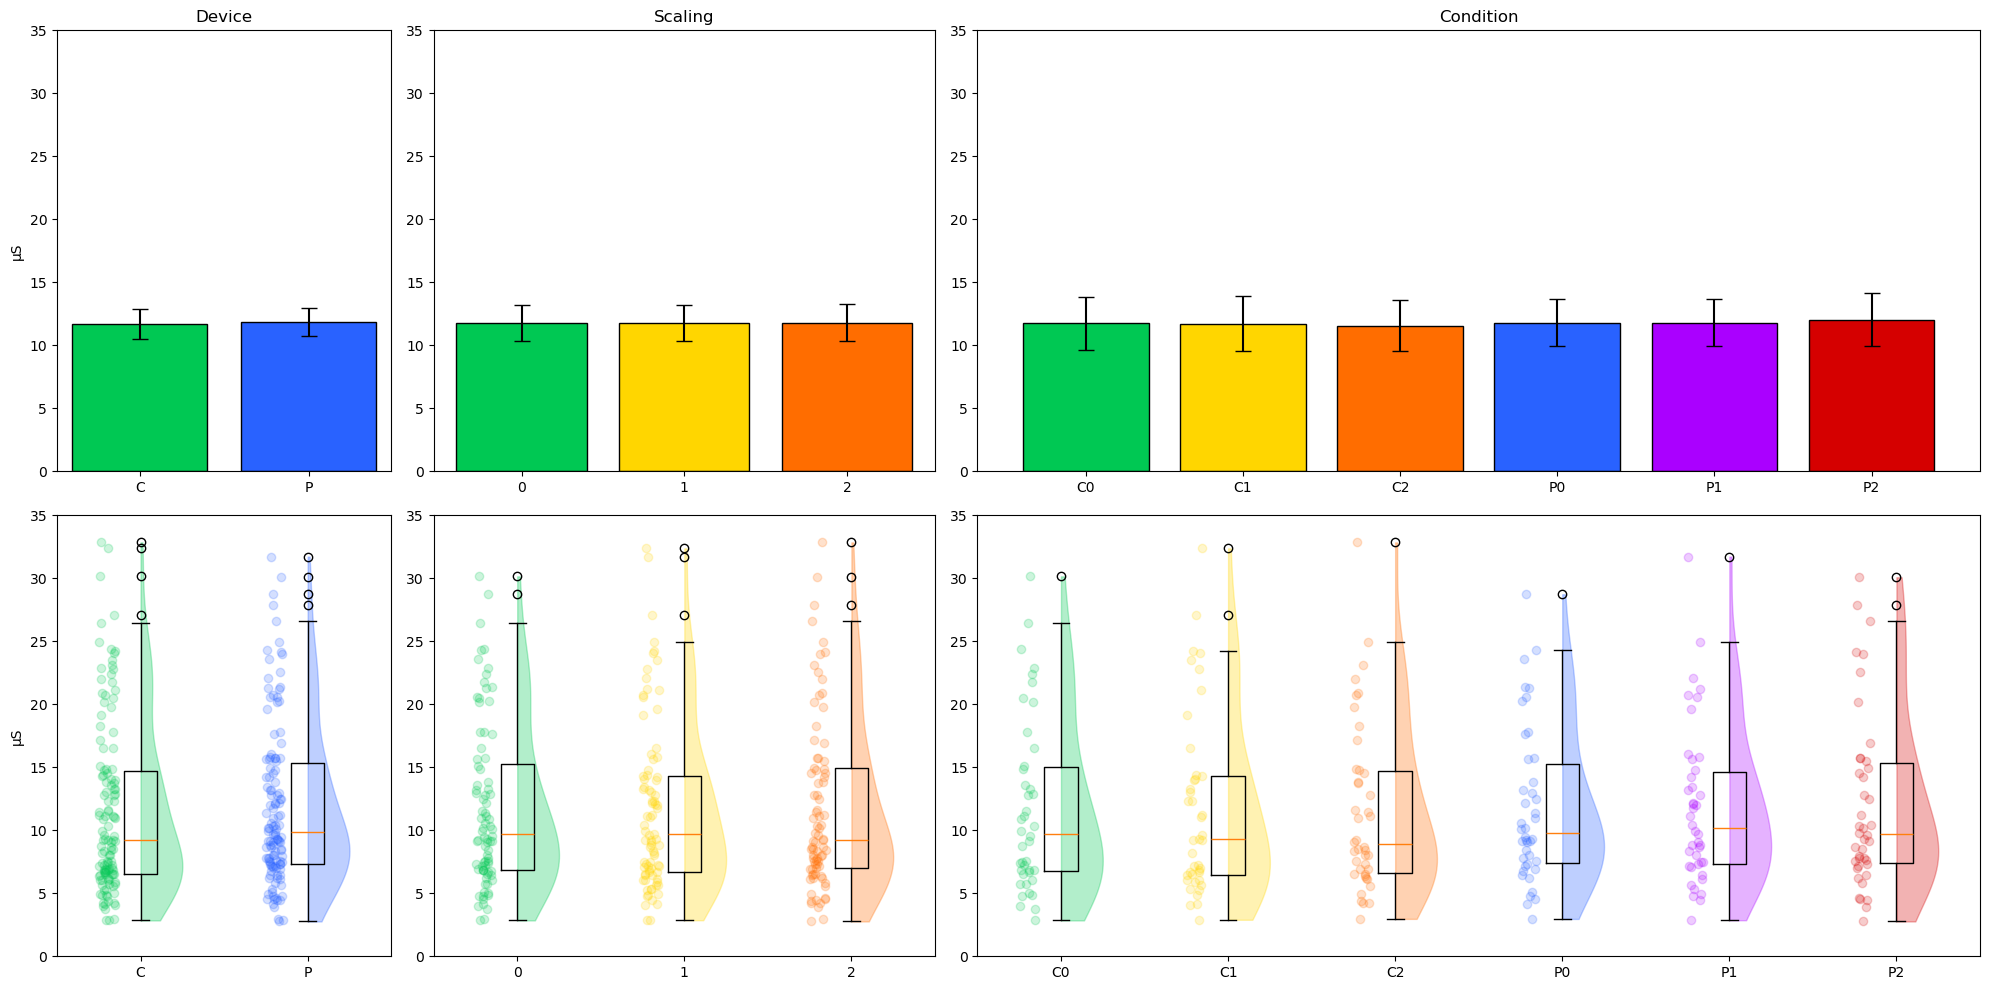

------ [Cube] Skin Conductance Delta ------
Mean & 0.46 & 0.49 & 0.67 & 0.83 & 0.79 & 0.92 \\
Standard Deviation & 0.31 & 0.41 & 0.86 & 0.74 & 0.66 & 0.74 \\
Minimum & 0.09 & 0.05 & 0.05 & 0.14 & 0.05 & 0.12 \\
Maximum & 1.49 & 1.99 & 4.34 & 2.75 & 3.05 & 3.17 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.734525,1,41,5.734525,13.064400,0.000815,0.000815,0.051081,1.000000,✅
1,Scaling,1.322656,2,82,0.661328,4.581205,0.012999,0.024303,0.012264,0.711015,✅
2,Device * Scaling,0.151884,2,82,0.075942,0.503197,0.606449,0.551287,0.001424,0.737726,❌


Device & (1, 41) & 13.06 & \textbf{0.000815} & 0.0511 \\
Scaling & (2, 82) & 4.58 & \textbf{0.024303} & 0.0123 \\
Device * Scaling & (2, 82) & 0.5 & 0.551287 & 0.0014 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.614471,41.0,two-sided,0.000815,NaN,NaN,36.108,-0.516777,✅
1,Scaling,-,0,1,True,True,0.242766,41.0,two-sided,0.809397,0.809397,holm,0.172,0.019148,❌
2,Scaling,-,0,2,True,True,-2.075600,41.0,two-sided,0.044243,0.088487,holm,1.158,-0.249575,🟨
3,Scaling,-,1,2,True,True,-2.575428,41.0,two-sided,0.013716,0.041147,holm,3.061,-0.261456,✅


Device P-C & 41 & 3.61 & \textbf{0.000815} & 0.5168 \\
Scaling 1-0 & 41 & -0.24 & 0.809397 & -0.0191 \\
Scaling 2-0 & 41 & 2.08 & 0.088487 & 0.2496 \\
Scaling 2-1 & 41 & 2.58 & \textbf{0.041147} & 0.2615 \\


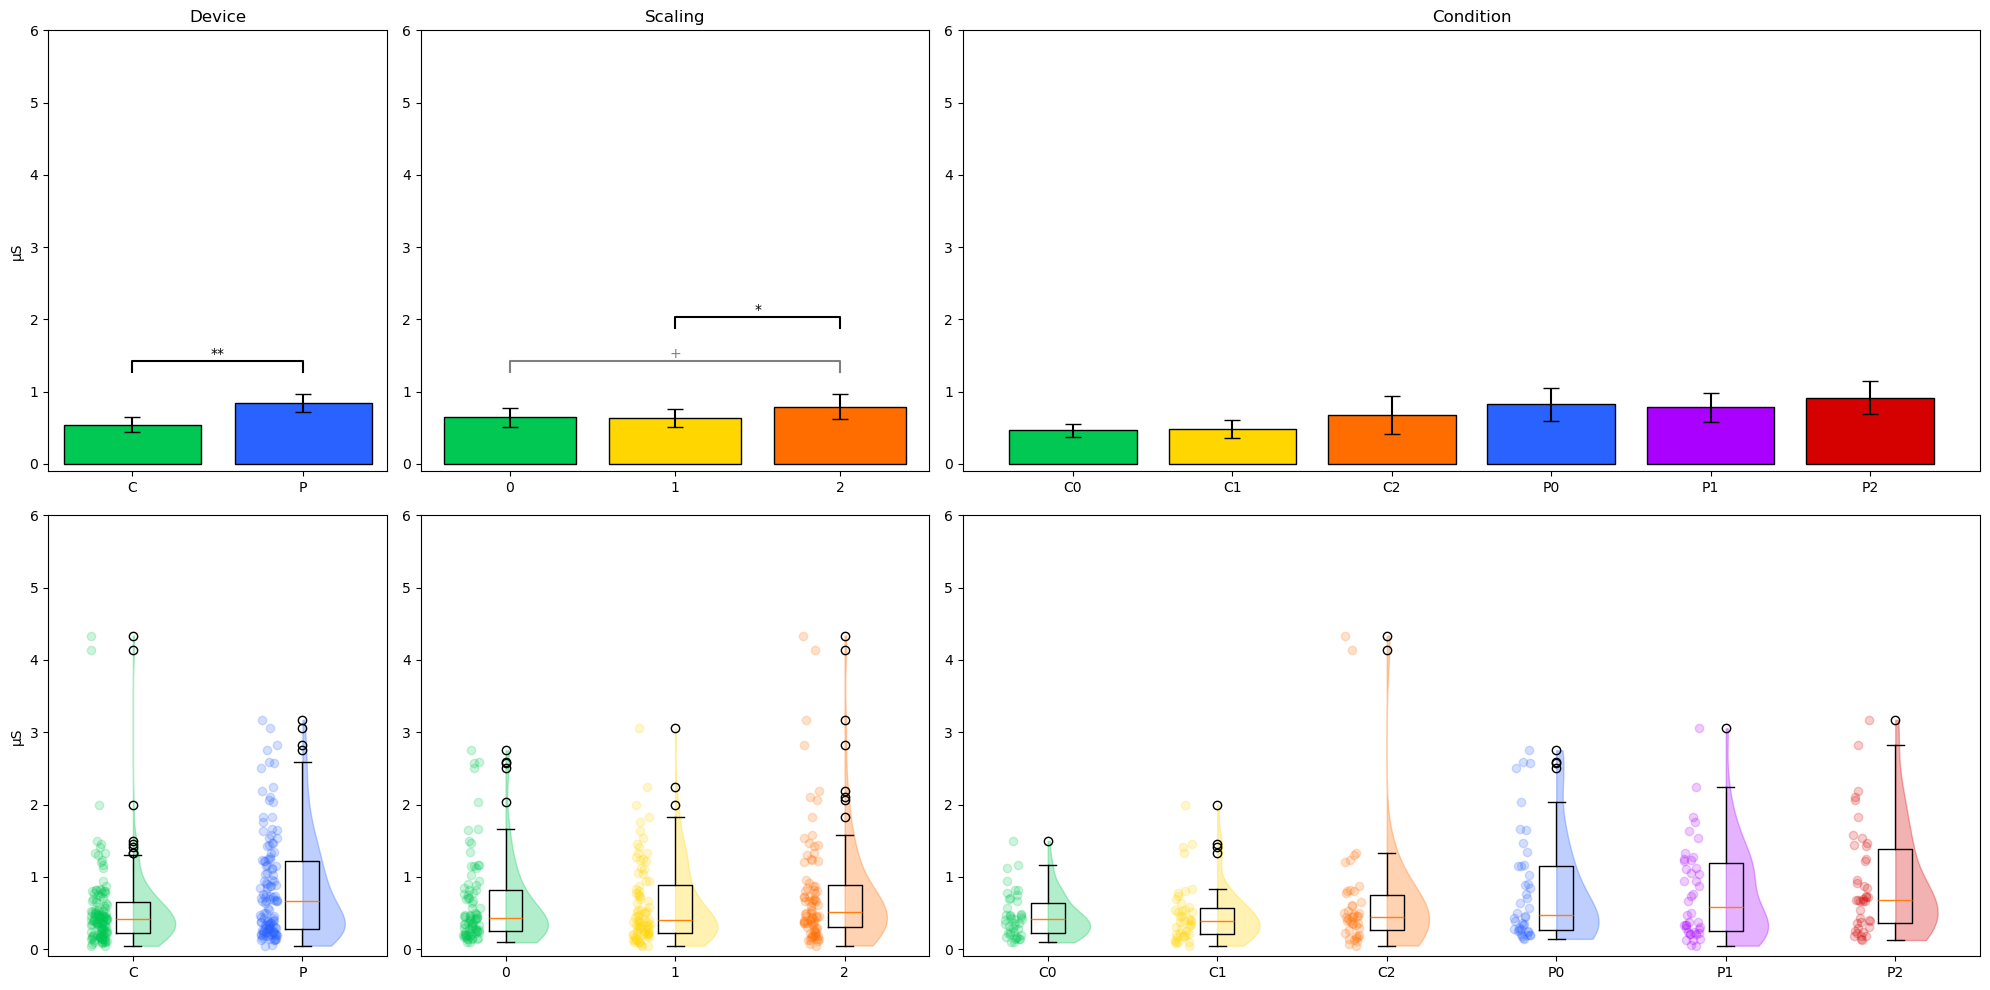

------ [Shovel] Skin Conductance Delta ------
Mean & 0.92 & 0.92 & 1.01 & 1.12 & 1.18 & 1.15 \\
Standard Deviation & 0.74 & 0.75 & 0.97 & 0.73 & 0.93 & 0.77 \\
Minimum & 0.18 & 0.12 & 0.22 & 0.23 & 0.24 & 0.16 \\
Maximum & 3.68 & 3.28 & 5.74 & 3.03 & 4.59 & 4.18 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.423546,1,41,2.423546,23.155965,0.000020,0.000020,0.014048,1.000000,✅
1,Scaling,0.134314,2,82,0.067157,0.309080,0.734974,0.720084,0.000789,0.933678,❌
2,Device * Scaling,0.130751,2,82,0.065375,0.347650,0.707382,0.689469,0.000768,0.919270,❌


Device & (1, 41) & 23.16 & \textbf{2e-05} & 0.014 \\
Scaling & (2, 82) & 0.31 & 0.720084 & 0.0008 \\
Device * Scaling & (2, 82) & 0.35 & 0.689469 & 0.0008 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.812065,41.0,two-sided,0.00002,NaN,NaN,1026.593,-0.260542,✅


Device P-C & 41 & 4.81 & \textbf{2e-05} & 0.2605 \\


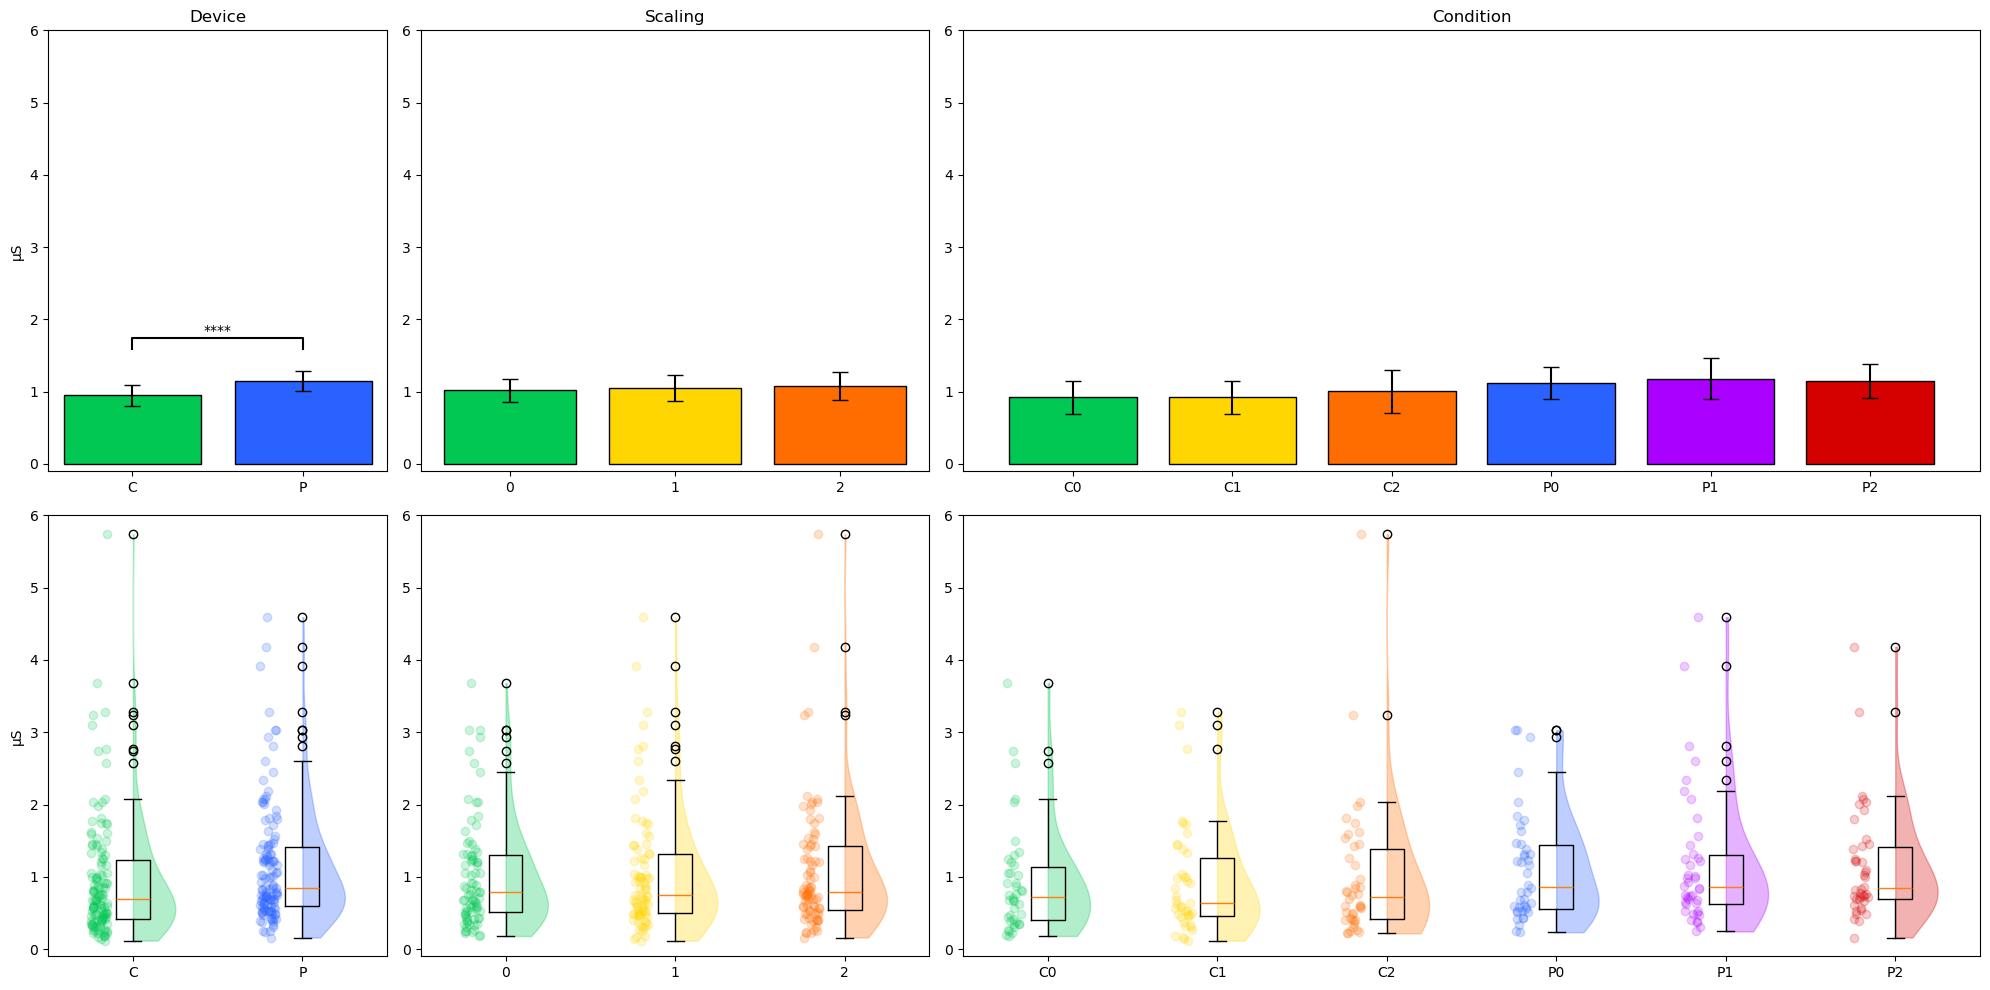

{'aov':              Source        SS  ddof1  ddof2        MS          F     p-unc  \
 0            Device  2.423546      1     41  2.423546  23.155965  0.000020   
 1           Scaling  0.134314      2     82  0.067157   0.309080  0.734974   
 2  Device * Scaling  0.130751      2     82  0.065375   0.347650  0.707382   
 
    p-GG-corr       ng2       eps Significance  
 0   0.000020  0.014048  1.000000            ✅  
 1   0.720084  0.000789  0.933678            ❌  
 2   0.689469  0.000768  0.919270            ❌  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -4.812065  41.0   two-sided   
 
      p-unc  p-corr p-adjust      BF10    hedges Significance  
 0  0.00002     NaN      NaN  1026.593 -0.260542            ✅  }

In [25]:
ylabel = 'µS'
ylim = [0,35]

title = 'Mean Skin Conductance'
def gsr_con_mean(p): return mean_val(p, gsr_con_key)
report_exeriment(data, gsr_con_mean, cube, title, ylabel, ylim)
report_exeriment(data, gsr_con_mean, shovel, title, ylabel, ylim)

title = 'Skin Conductance Normalized AUC'
def gsr_con_auc(p): return normalized_auc(p, gsr_con_key)
report_exeriment(data, gsr_con_auc, cube, title, ylabel, ylim)
report_exeriment(data, gsr_con_auc, shovel, title, ylabel, ylim)

title = 'Sustained Peak Skin Conductance'
def gsr_con_peak(p): return peak_val(p, gsr_con_key)
report_exeriment(data, gsr_con_peak, cube, title, ylabel, ylim)
report_exeriment(data, gsr_con_peak, shovel, title, ylabel, ylim)

title = 'Skin Conductance Delta'
ylim = [-0.1,6]
def gsr_con_delta(p): return delta_val(p, gsr_con_key)
report_exeriment(data, gsr_con_delta, cube, title, ylabel, ylim)
report_exeriment(data, gsr_con_delta, shovel, title, ylabel, ylim)

------ [Cube] 3D Head Travel ------
Mean & 13.28 & 13.43 & 14.46 & 13.98 & 13.98 & 15.29 \\
Standard Deviation & 3.15 & 2.83 & 3.68 & 2.68 & 1.99 & 3.81 \\
Minimum & 8.85 & 7.83 & 9.1 & 8.89 & 9.65 & 10.38 \\
Maximum & 23.95 & 22.33 & 26.6 & 20.19 & 19.13 & 27.39 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,30.792265,1,41,30.792265,3.410929,0.071992,0.071992,0.012686,1.000000,🟨
1,Scaling,81.780435,2,82,40.890218,5.177640,0.007628,0.017872,0.032998,0.674090,✅
2,Device * Scaling,0.833778,2,82,0.416889,0.080390,0.922829,0.898773,0.000348,0.865481,❌


Device & (1, 41) & 3.41 & 0.071992 & 0.0127 \\
Scaling & (2, 82) & 5.18 & \textbf{0.017872} & 0.033 \\
Device * Scaling & (2, 82) & 0.08 & 0.898773 & 0.0003 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-0.241983,41.0,two-sided,0.810000,0.810000,holm,0.171,-0.031062,❌
2,Scaling,-,0,2,True,True,-2.231153,41.0,two-sided,0.031201,0.062402,holm,1.54,-0.439349,🟨
3,Scaling,-,1,2,True,True,-2.861362,41.0,two-sided,0.006612,0.019835,holm,5.718,-0.454323,✅


Scaling 1-0 & 41 & 0.24 & 0.81 & 0.0311 \\
Scaling 2-0 & 41 & 2.23 & 0.062402 & 0.4393 \\
Scaling 2-1 & 41 & 2.86 & \textbf{0.019835} & 0.4543 \\


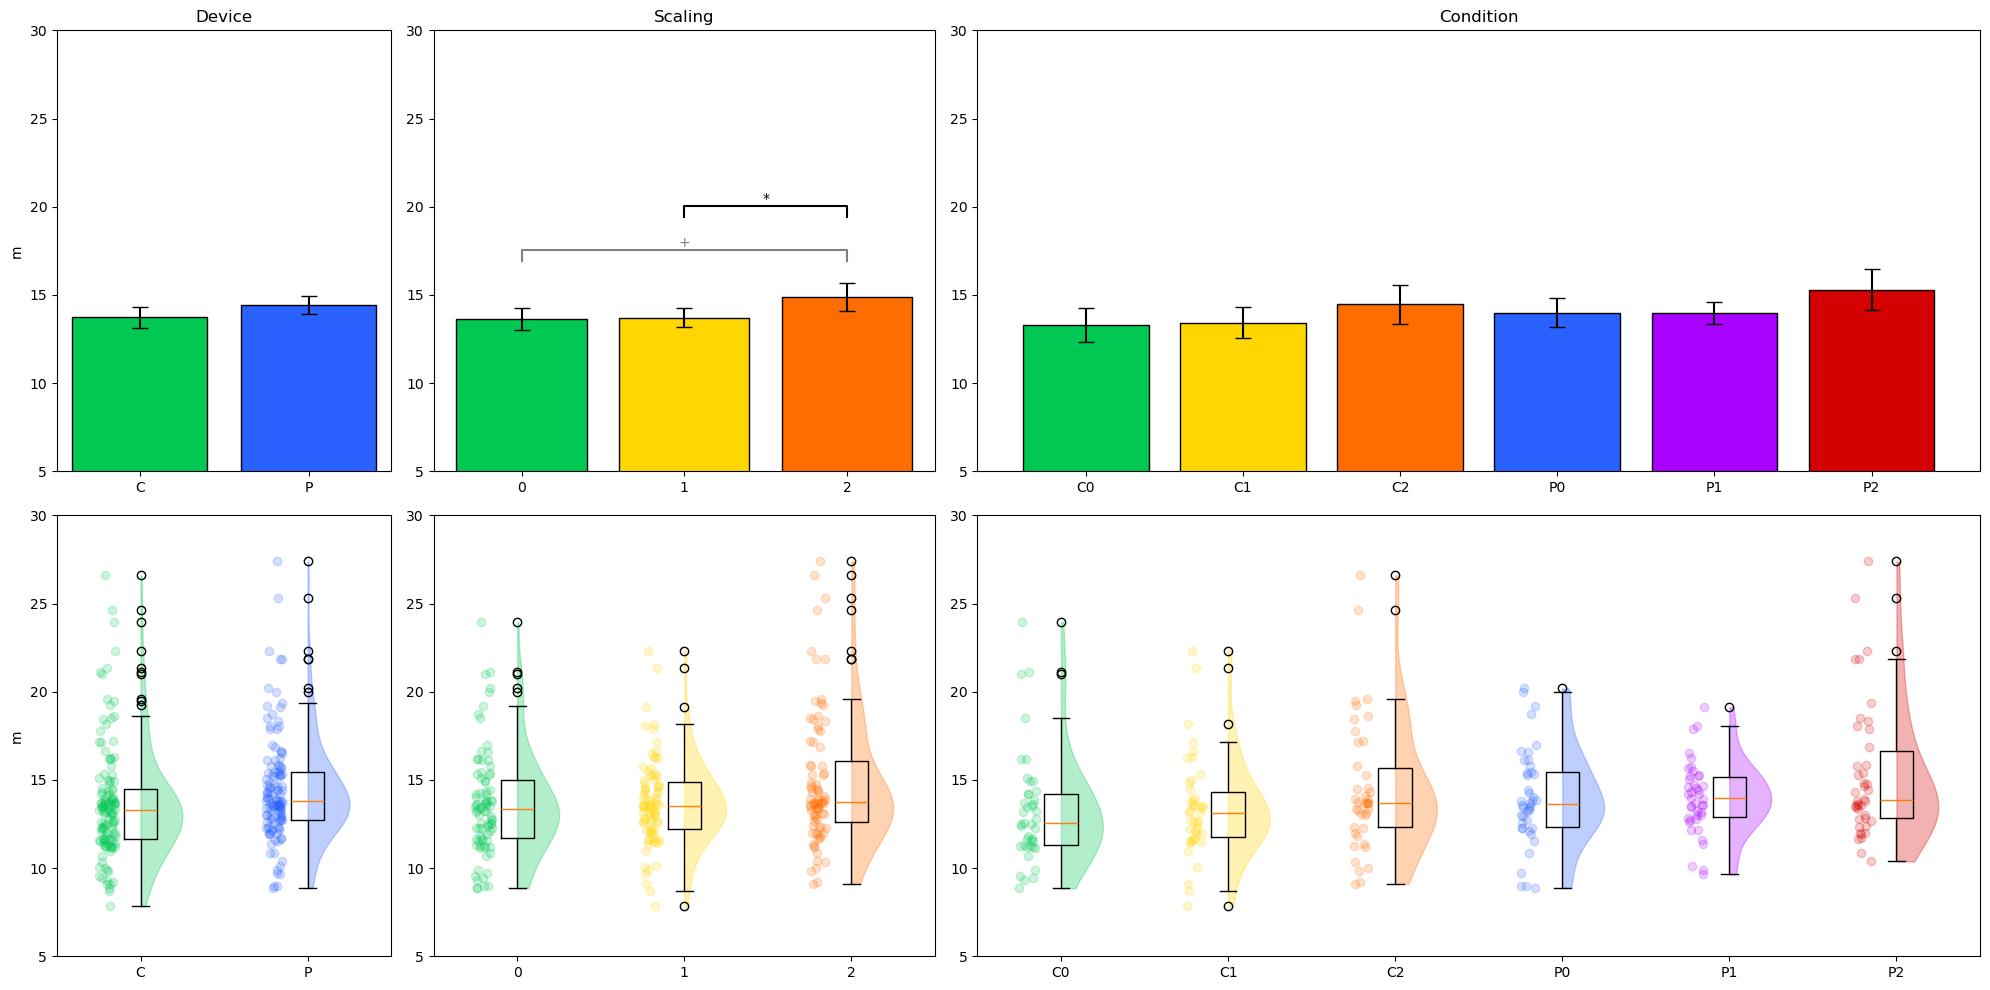

------ [Shovel] 3D Head Travel ------
Mean & 51.15 & 52.96 & 56.48 & 54.14 & 55.96 & 57.34 \\
Standard Deviation & 10.12 & 10.01 & 10.32 & 10.0 & 10.76 & 10.41 \\
Minimum & 31.26 & 31.49 & 28.9 & 30.72 & 20.07 & 25.01 \\
Maximum & 78.18 & 75.47 & 74.74 & 71.48 & 70.99 & 75.33 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,327.775103,1,41,327.775103,7.587084,0.008726,0.008726,0.012171,1.000000,✅
1,Scaling,769.411889,2,82,384.705945,8.802507,0.000344,0.001000,0.028108,0.799725,✅
2,Device * Scaling,63.770785,2,82,31.885393,1.064536,0.349605,0.335740,0.002391,0.769927,❌


Device & (1, 41) & 7.59 & \textbf{0.008726} & 0.0122 \\
Scaling & (2, 82) & 8.8 & \textbf{0.001} & 0.0281 \\
Device * Scaling & (2, 82) & 1.06 & 0.33574 & 0.0024 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.754466,41.0,two-sided,0.008726,NaN,NaN,4.503,-0.247187,✅
1,Scaling,-,0,1,True,True,-1.951355,41.0,two-sided,0.057870,0.057870,holm,0.933,-0.189555,🟨
2,Scaling,-,0,2,True,True,-3.420612,41.0,two-sided,0.001427,0.004280,holm,21.933,-0.440539,✅
3,Scaling,-,1,2,True,True,-2.917095,41.0,two-sided,0.005709,0.011417,holm,6.493,-0.254299,✅


Device P-C & 41 & 2.75 & \textbf{0.008726} & 0.2472 \\
Scaling 1-0 & 41 & 1.95 & 0.05787 & 0.1896 \\
Scaling 2-0 & 41 & 3.42 & \textbf{0.00428} & 0.4405 \\
Scaling 2-1 & 41 & 2.92 & \textbf{0.011417} & 0.2543 \\


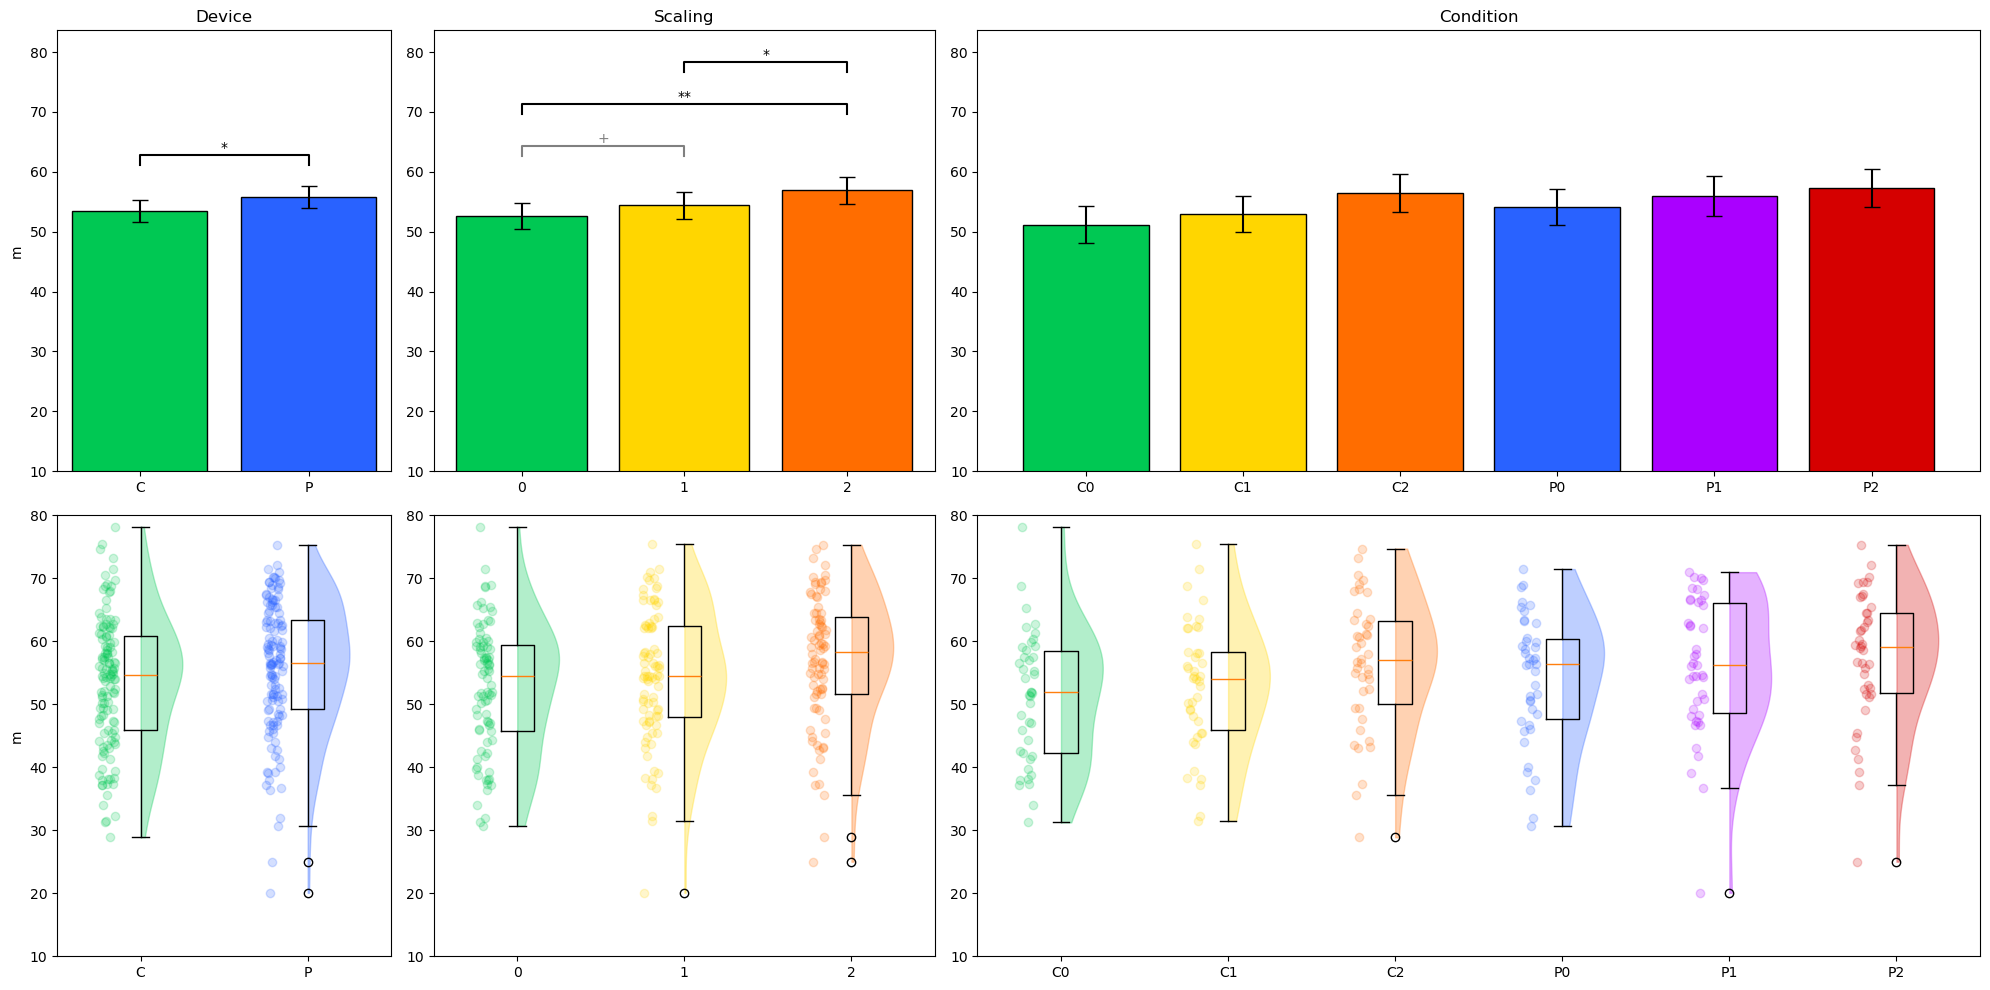

------ [Cube] Planar Horizontal Head Travel ------
Mean & 9.66 & 9.81 & 10.41 & 9.62 & 9.55 & 10.48 \\
Standard Deviation & 2.4 & 2.29 & 2.87 & 1.82 & 1.4 & 2.88 \\
Minimum & 6.6 & 6.29 & 6.25 & 6.14 & 7.03 & 7.03 \\
Maximum & 17.65 & 17.61 & 21.01 & 13.74 & 13.38 & 20.69 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.363061,1,41,0.363061,0.070874,0.791403,0.791403,0.000263,1.000000,❌
1,Scaling,34.670013,2,82,17.335006,4.264748,0.017297,0.030365,0.024540,0.708431,✅
2,Device * Scaling,1.212477,2,82,0.606239,0.210658,0.810488,0.780898,0.000879,0.873515,❌


Device & (1, 41) & 0.07 & 0.791403 & 0.0003 \\
Scaling & (2, 82) & 4.26 & \textbf{0.030365} & 0.0245 \\
Device * Scaling & (2, 82) & 0.21 & 0.780898 & 0.0009 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-0.166594,41.0,two-sided,0.868508,0.868508,holm,0.169,-0.022469,❌
2,Scaling,-,0,2,True,True,-2.033604,41.0,two-sided,0.048498,0.096996,holm,1.075,-0.376538,🟨
3,Scaling,-,1,2,True,True,-2.704041,41.0,two-sided,0.009927,0.029782,holm,4.031,-0.379381,✅


Scaling 1-0 & 41 & 0.17 & 0.868508 & 0.0225 \\
Scaling 2-0 & 41 & 2.03 & 0.096996 & 0.3765 \\
Scaling 2-1 & 41 & 2.7 & \textbf{0.029782} & 0.3794 \\


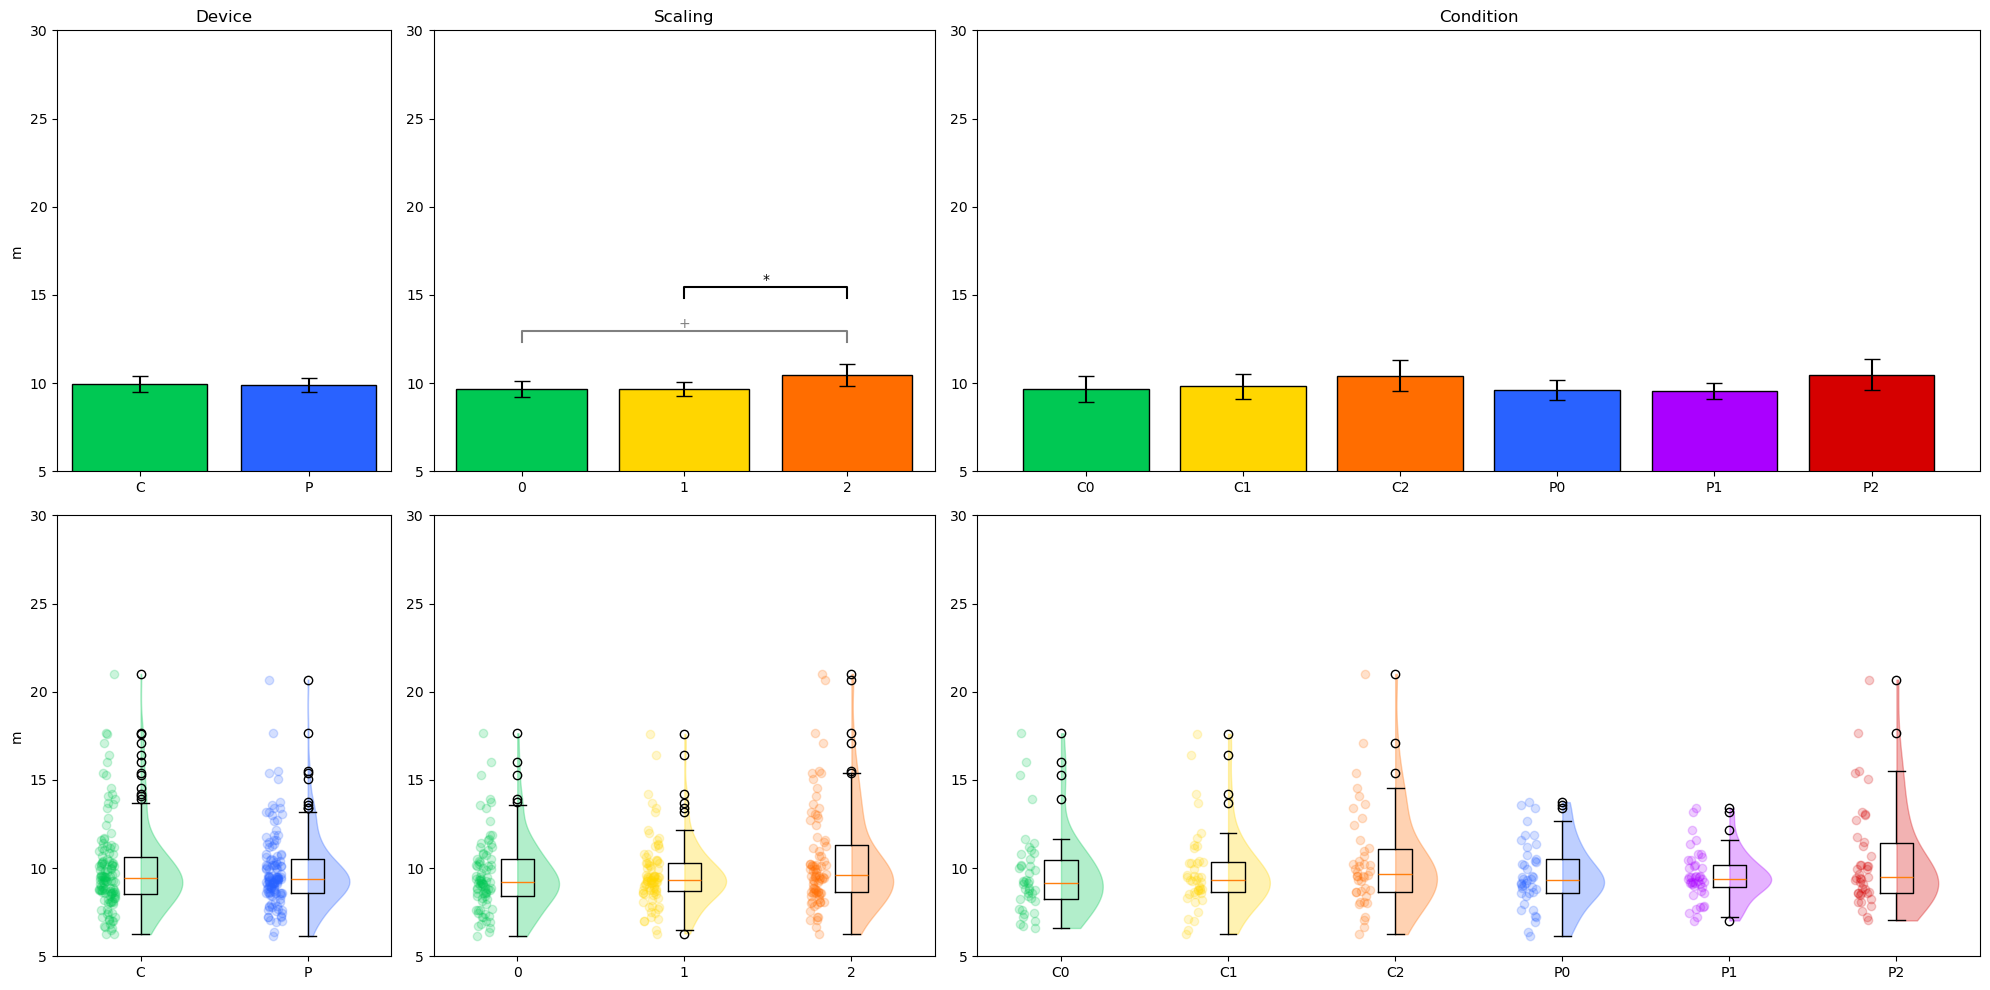

------ [Shovel] Planar Horizontal Head Travel ------
Mean & 43.11 & 45.25 & 48.46 & 44.53 & 46.9 & 48.18 \\
Standard Deviation & 8.65 & 8.6 & 9.33 & 8.73 & 9.44 & 9.49 \\
Minimum & 23.89 & 24.26 & 24.15 & 22.09 & 14.22 & 20.23 \\
Maximum & 65.66 & 61.02 & 65.16 & 59.78 & 59.31 & 60.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,54.685583,1,41,54.685583,1.687070,0.201245,0.201245,0.002645,1.000000,❌
1,Scaling,852.526240,2,82,426.263120,13.524445,0.000008,0.000071,0.039700,0.756174,✅
2,Device * Scaling,46.651286,2,82,23.325643,1.110819,0.334193,0.322281,0.002257,0.766394,❌


Device & (1, 41) & 1.69 & 0.201245 & 0.0026 \\
Scaling & (2, 82) & 13.52 & \textbf{7.1e-05} & 0.0397 \\
Device * Scaling & (2, 82) & 1.11 & 0.322281 & 0.0023 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.892196,41.0,two-sided,0.006097,0.006097,holm,6.134,-0.271576,✅
2,Scaling,-,0,2,True,True,-4.165965,41.0,two-sided,0.000156,0.000467,holm,160.554,-0.523544,✅
3,Scaling,-,1,2,True,True,-3.268886,41.0,two-sided,0.002190,0.004380,holm,15.011,-0.259408,✅


Scaling 1-0 & 41 & 2.89 & \textbf{0.006097} & 0.2716 \\
Scaling 2-0 & 41 & 4.17 & \textbf{0.000467} & 0.5235 \\
Scaling 2-1 & 41 & 3.27 & \textbf{0.00438} & 0.2594 \\


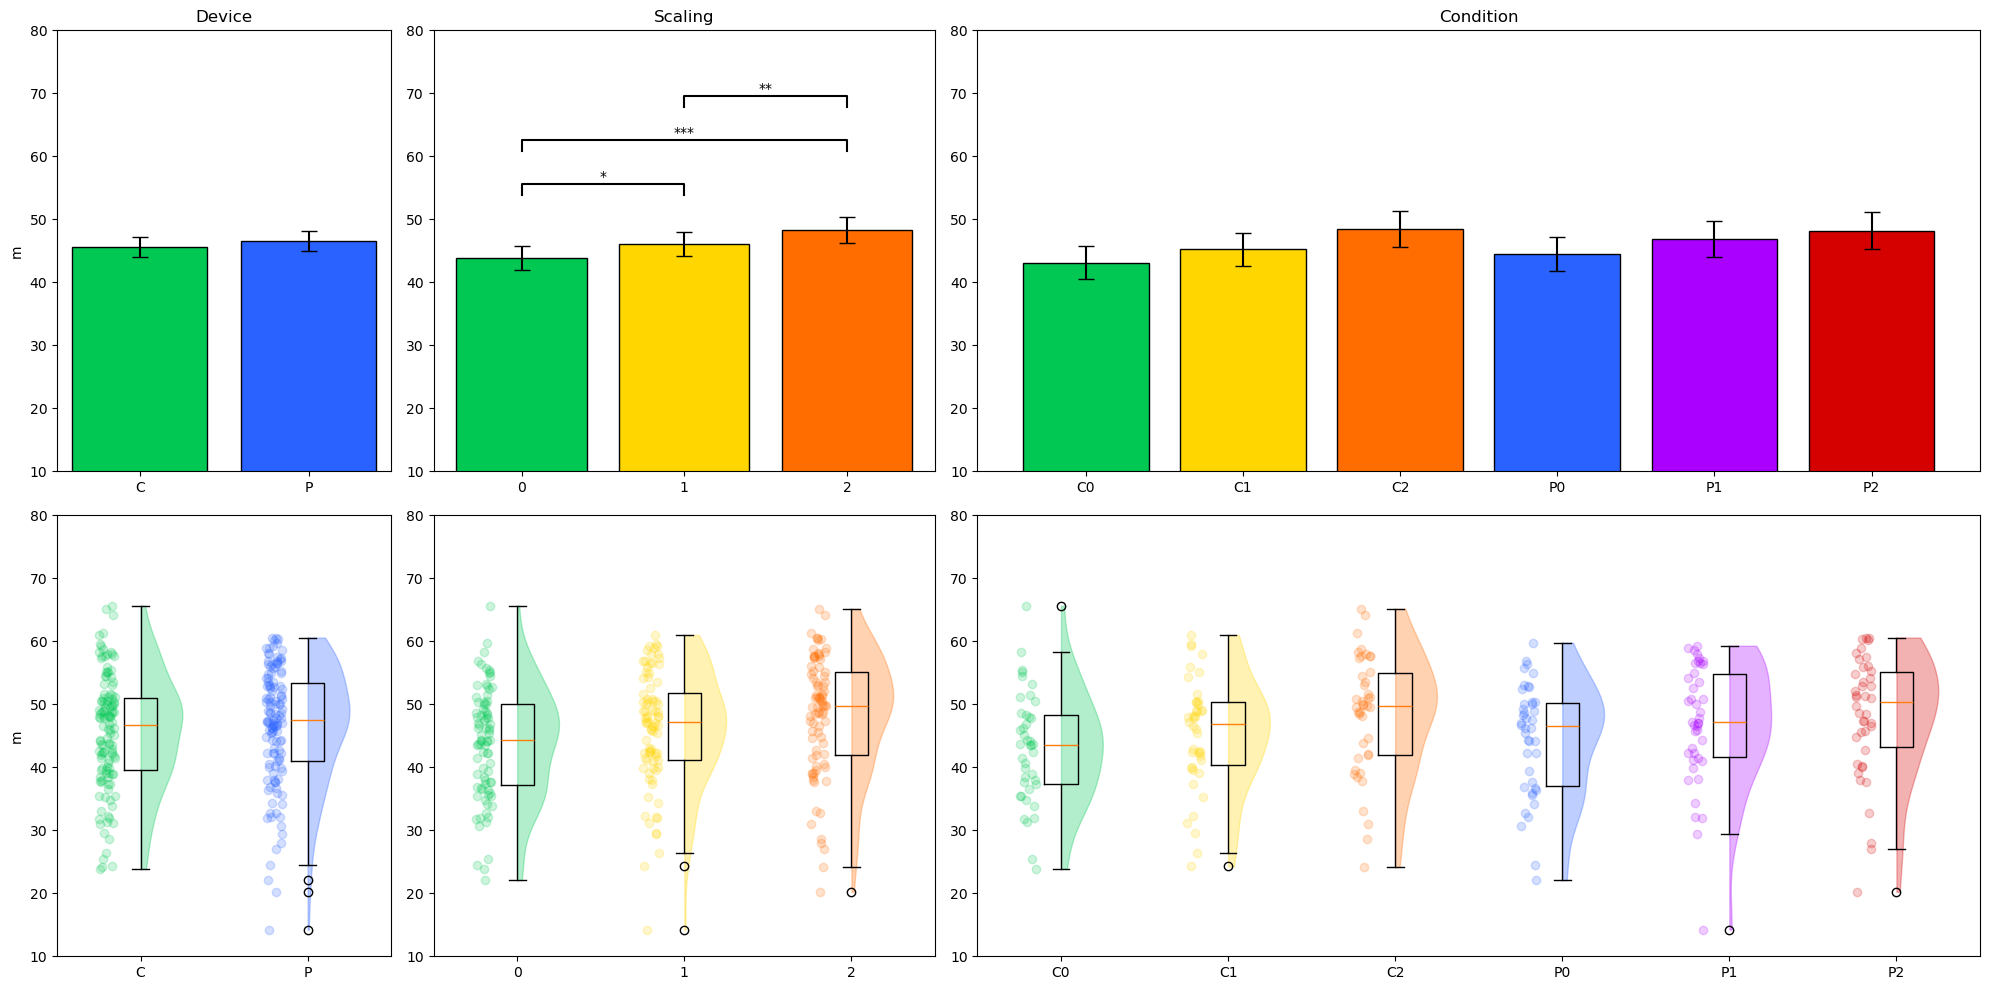

------ [Cube] Vertical Head Travel ------
Mean & 6.91 & 6.93 & 7.53 & 7.68 & 7.72 & 8.41 \\
Standard Deviation & 1.56 & 1.27 & 1.75 & 1.5 & 1.23 & 1.79 \\
Minimum & 4.42 & 4.01 & 4.37 & 3.68 & 4.36 & 6.17 \\
Maximum & 12.55 & 10.22 & 13.92 & 11.03 & 10.51 & 12.72 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,41.850918,1,41,41.850918,19.764167,0.000065,0.000065,0.065970,1.000000,✅
1,Scaling,24.512956,2,82,12.256478,5.655563,0.005001,0.013334,0.039726,0.670063,✅
2,Device * Scaling,0.132539,2,82,0.066269,0.048741,0.952456,0.936304,0.000224,0.882578,❌


Device & (1, 41) & 19.76 & \textbf{6.5e-05} & 0.066 \\
Scaling & (2, 82) & 5.66 & \textbf{0.013334} & 0.0397 \\
Device * Scaling & (2, 82) & 0.05 & 0.936304 & 0.0002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.445691,41.0,two-sided,0.000065,NaN,NaN,354.274,-0.727242,✅
1,Scaling,-,0,1,True,True,-0.237071,41.0,two-sided,0.813782,0.813782,holm,0.171,-0.027898,❌
2,Scaling,-,0,2,True,True,-2.363435,41.0,two-sided,0.022929,0.045857,holm,1.987,-0.484753,✅
3,Scaling,-,1,2,True,True,-2.796993,41.0,two-sided,0.007819,0.023457,holm,4.948,-0.520394,✅


Device P-C & 41 & 4.45 & \textbf{6.5e-05} & 0.7272 \\
Scaling 1-0 & 41 & 0.24 & 0.813782 & 0.0279 \\
Scaling 2-0 & 41 & 2.36 & \textbf{0.045857} & 0.4848 \\
Scaling 2-1 & 41 & 2.8 & \textbf{0.023457} & 0.5204 \\


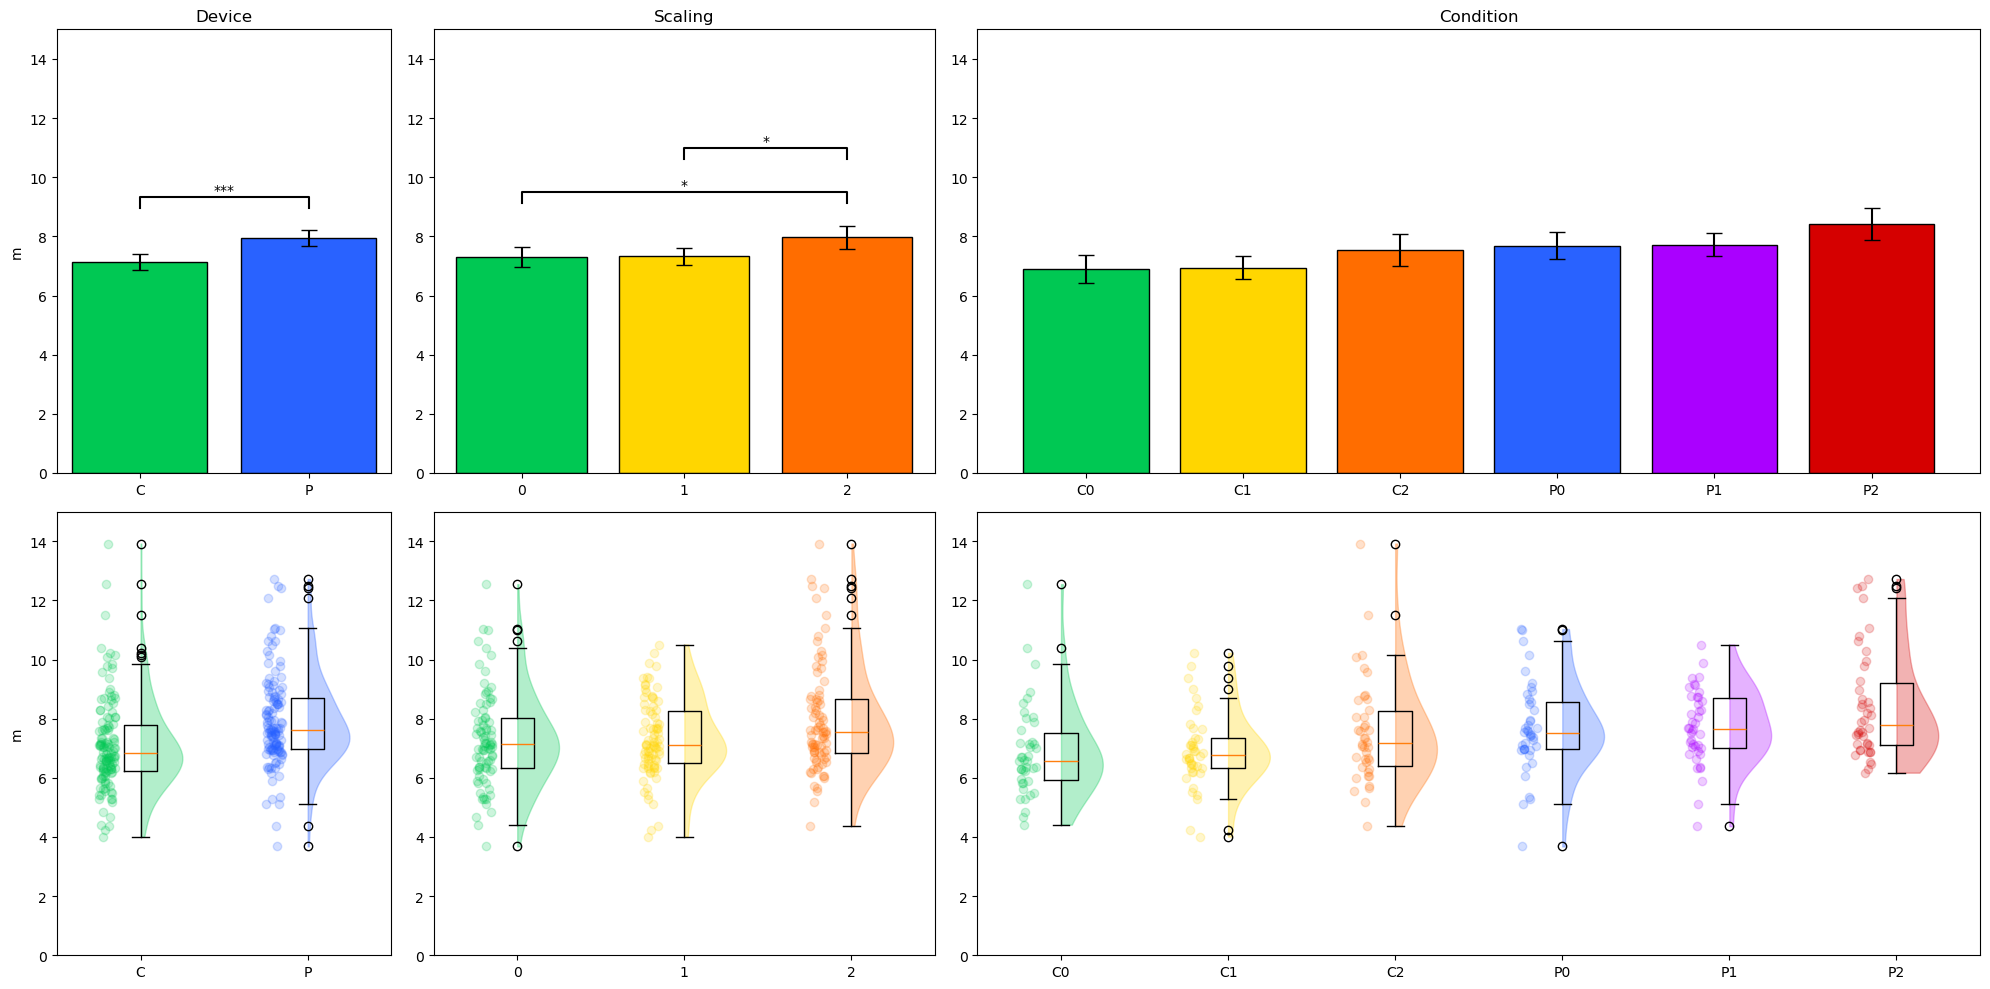

------ [Shovel] Vertical Head Travel ------
Mean & 20.35 & 19.97 & 20.71 & 22.69 & 22.21 & 22.6 \\
Standard Deviation & 5.22 & 4.91 & 5.13 & 4.75 & 5.02 & 4.79 \\
Minimum & 9.18 & 9.68 & 9.78 & 11.28 & 12.24 & 12.13 \\
Maximum & 30.92 & 32.53 & 31.72 & 32.74 & 33.42 & 33.75 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,292.319374,1,41,292.319374,35.961107,4.372807e-07,4.372807e-07,0.044800,1.000000,✅
1,Scaling,14.509060,2,82,7.254530,0.770776,4.659764e-01,4.537427e-01,0.002323,0.899287,❌
2,Device * Scaling,2.332305,2,82,1.166152,0.178450,8.368900e-01,8.107167e-01,0.000374,0.884441,❌


Device & (1, 41) & 35.96 & \textbf{0.0} & 0.0448 \\
Scaling & (2, 82) & 0.77 & 0.453743 & 0.0023 \\
Device * Scaling & (2, 82) & 0.18 & 0.810717 & 0.0004 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-5.996758,41.0,two-sided,4.372807e-07,NaN,NaN,3.659e+04,-0.477003,✅


Device P-C & 41 & 6.0 & \textbf{0.0} & 0.477 \\


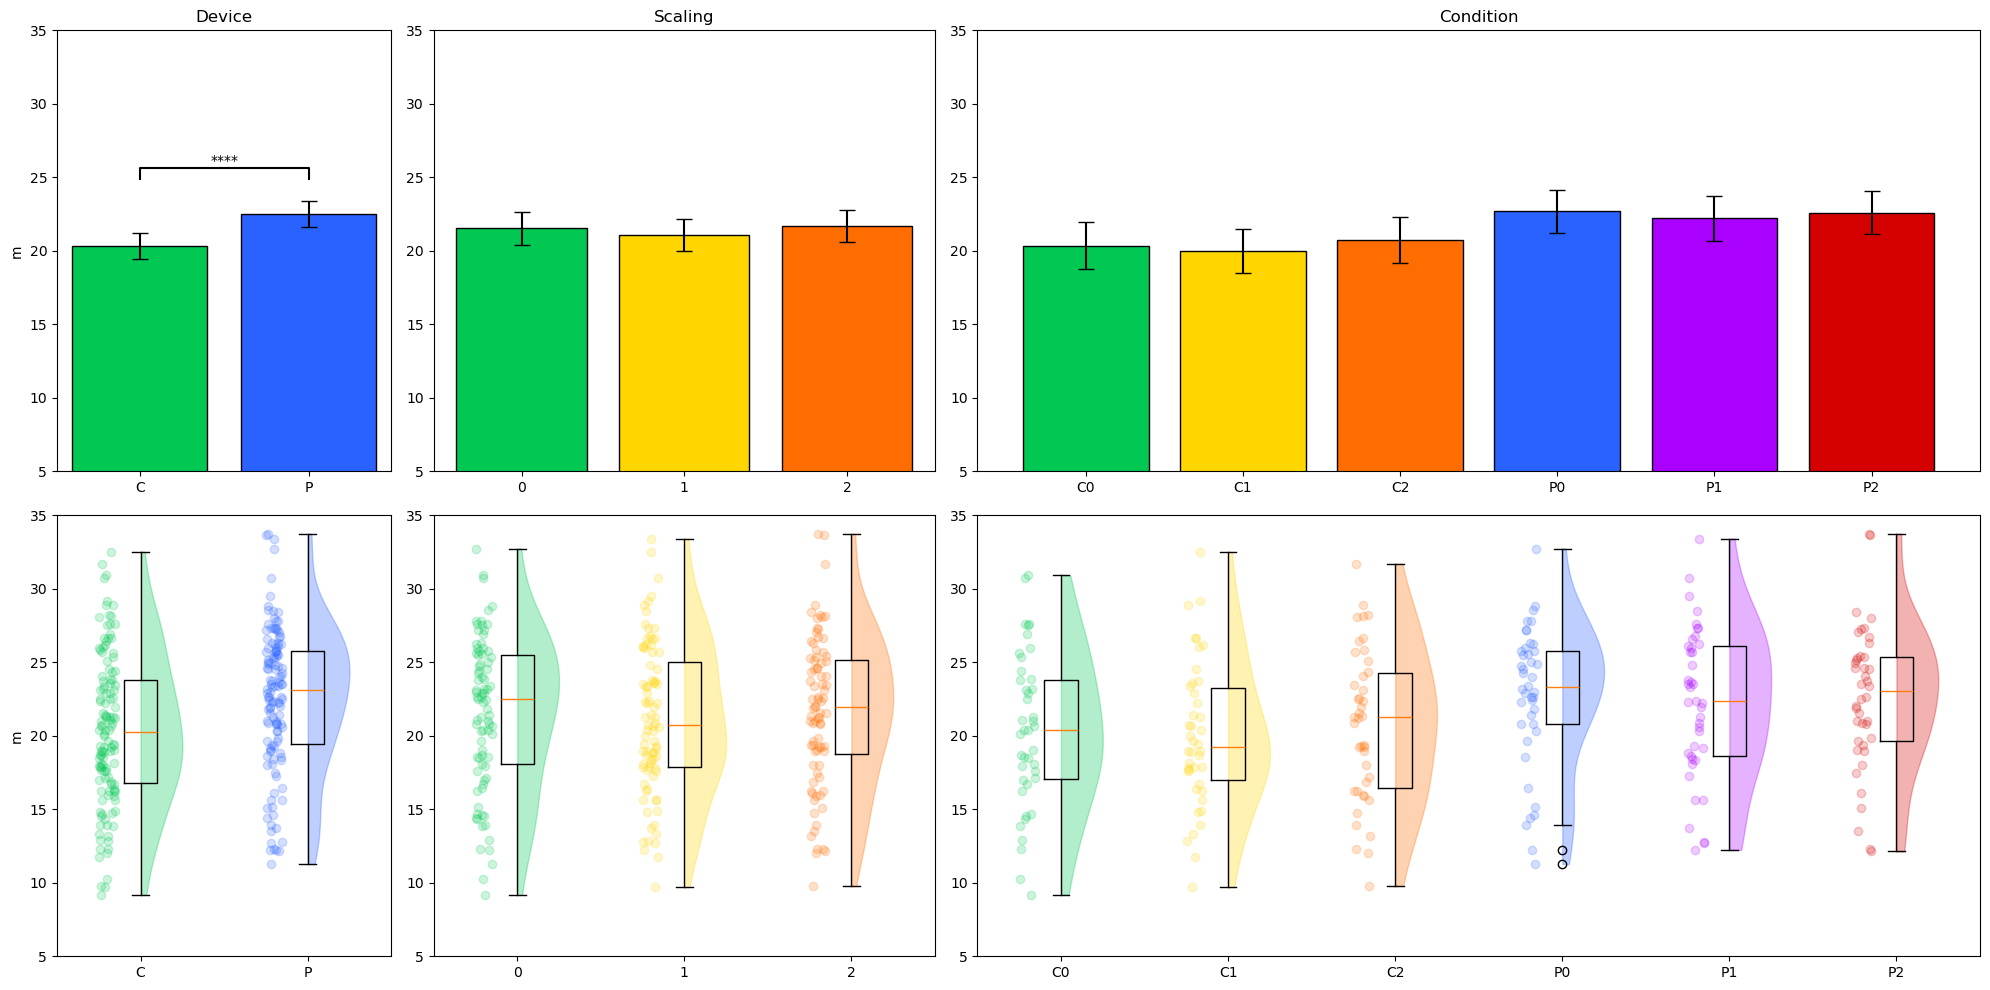

In [26]:
ylabel = 'm'

title = '3D Head Travel'
def hmd_path_len(p): return get_pt_path_len(p, hmd)
cube_3d_travel = report_exeriment(data, hmd_path_len, cube, title, ylabel, ylim=[5,30])
shovel_3d_travel = report_exeriment(data, hmd_path_len, shovel, title, ylabel, ylim=[10,80])

title = 'Planar Horizontal Head Travel'
def hmd_path_len_planar(p): return get_pt_path_len_planar(p, hmd)
cube_planar_travel = report_exeriment(data, hmd_path_len_planar, cube, title, ylabel, ylim=[5,30])
shovel_planar_travel = report_exeriment(data, hmd_path_len_planar, shovel, title, ylabel, ylim=[10,80])

title = 'Vertical Head Travel'
def hmd_path_len_vertical(p): return get_pt_path_len_vertical(p, hmd)
cube_vert_travel = report_exeriment(data, hmd_path_len_vertical, cube, title, ylabel, ylim=[0,15])
shovel_vert_travel = report_exeriment(data, hmd_path_len_vertical, shovel, title, ylabel, ylim=[5,35])

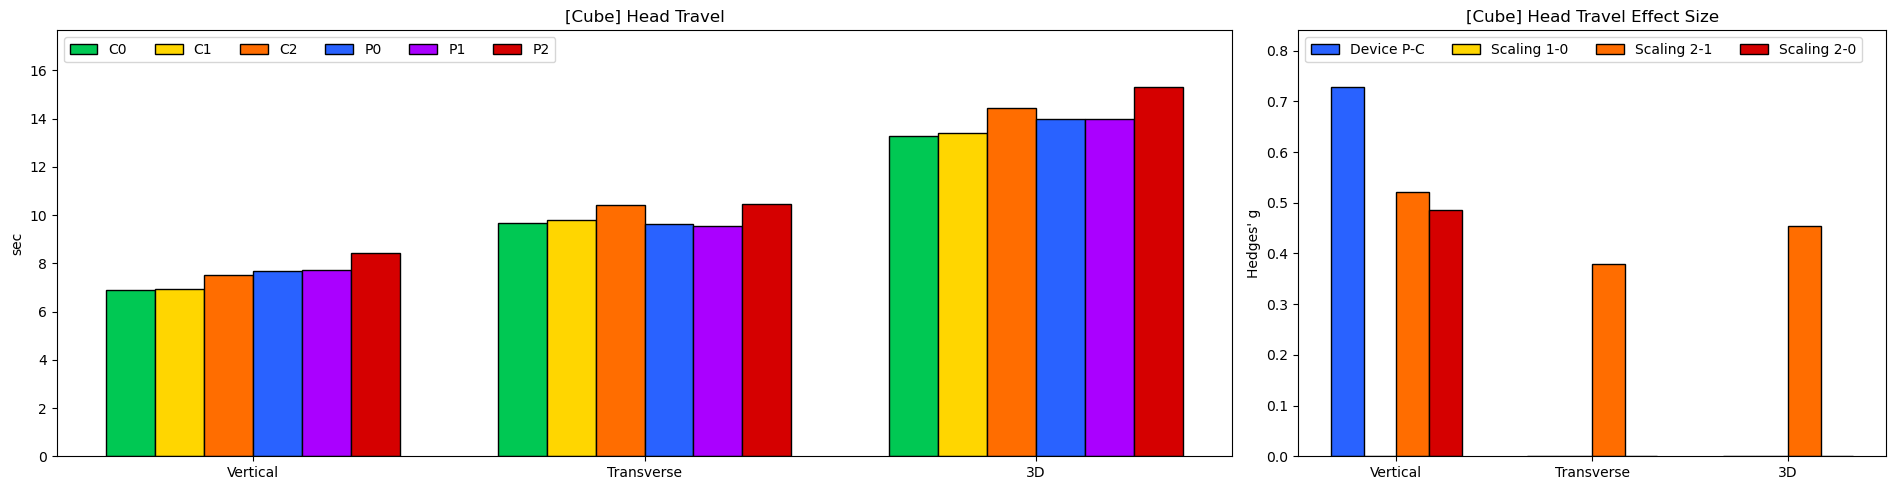

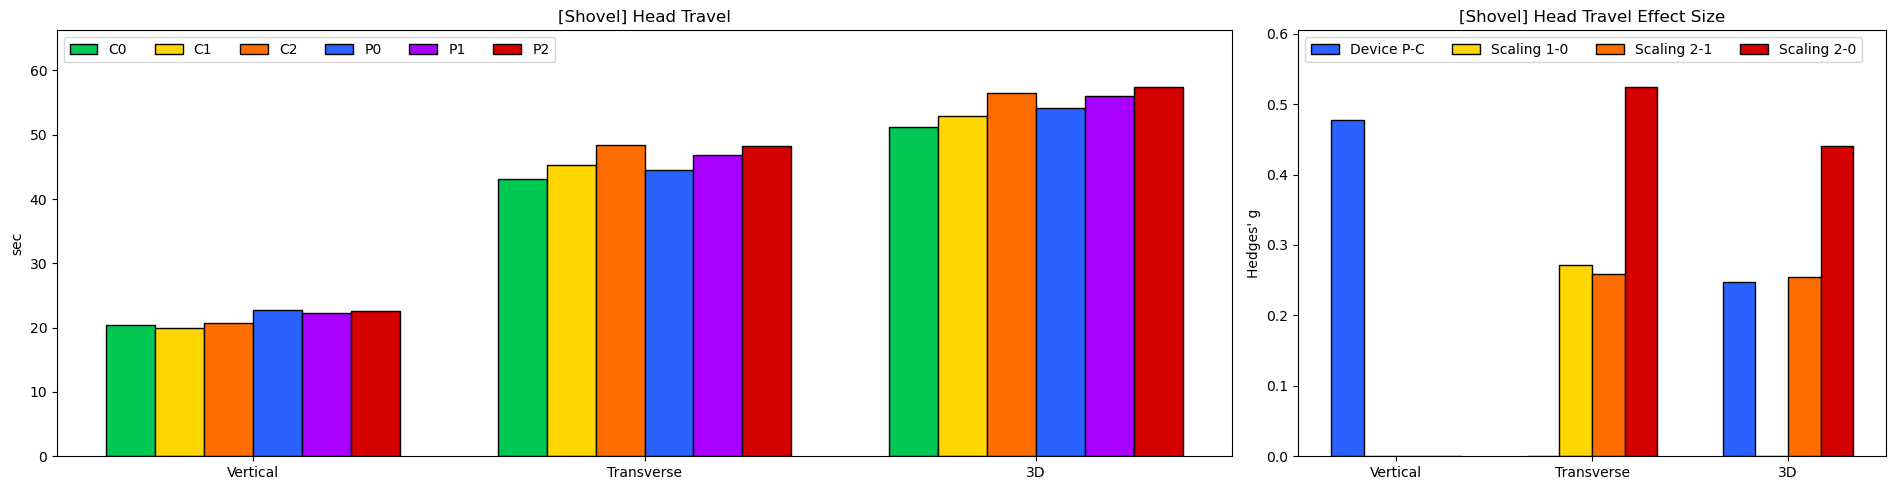

In [27]:
def get_head_travel_splits(data, e):
    total_travel = []
    planar_travel = []
    vert_travel = []

    for c in conditions:
        participant_values = list(map(lambda x: x[e][c], data))
        participant_totals = list(map(lambda x: get_pt_path_len(x, hmd), participant_values))
        participant_planars = list(map(lambda x: get_pt_path_len_planar(x, hmd), participant_values))
        participant_verts = list(map(lambda x: get_pt_path_len_vertical(x, hmd), participant_values))

        total_travel.append(np.mean(participant_totals))
        planar_travel.append(np.mean(participant_planars))
        vert_travel.append(np.mean(participant_verts))

    return [vert_travel, planar_travel, total_travel]

labels = ["Vertical", "Transverse", "3D"]
ylabel = 'sec'

cube_title = "[Cube] Head Travel"
cube_travel_splits = get_head_travel_splits(data, cube)
cube_travel_aovs = [cube_vert_travel, cube_planar_travel, cube_3d_travel]
report_comparison(cube_travel_splits, cube_travel_aovs, labels, cube_title, ylabel)

shovel_title = "[Shovel] Head Travel"
shovel_travel_splits = get_head_travel_splits(data, shovel)
shovel_travel_aovs = [shovel_vert_travel, shovel_planar_travel, shovel_3d_travel]
report_comparison(shovel_travel_splits, shovel_travel_aovs, labels, shovel_title, ylabel)


------ [Shovel] Average Hand Distance ------
Mean & 383.61 & 407.09 & 427.34 & 438.95 & 457.24 & 460.84 \\
Standard Deviation & 73.99 & 80.87 & 75.11 & 50.34 & 47.26 & 47.28 \\
Minimum & 242.92 & 217.45 & 251.55 & 313.7 & 348.81 & 349.05 \\
Maximum & 539.79 & 609.24 & 590.03 & 540.31 & 542.19 & 536.68 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,135220.234960,1,41,135220.234960,21.845864,3.180166e-05,3.180166e-05,0.115486,1.000000,✅
1,Scaling,46328.995440,2,82,23164.497720,20.928004,4.536988e-08,2.173738e-07,0.042819,0.885321,✅
2,Device * Scaling,5467.706967,2,82,2733.853484,2.850314,6.357069e-02,7.162487e-02,0.005252,0.869571,🟨


Device & (1, 41) & 21.85 & \textbf{3.2e-05} & 0.1155 \\
Scaling & (2, 82) & 20.93 & \textbf{0.0} & 0.0428 \\
Device * Scaling & (2, 82) & 2.85 & 0.071625 & 0.0053 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.673956,41.0,two-sided,0.000032,NaN,NaN,685.204,-0.773562,✅
1,Scaling,-,0,1,True,True,-4.212134,41.0,two-sided,0.000135,0.000270,holm,182.699,-0.384698,✅
2,Scaling,-,0,2,True,True,-5.520926,41.0,two-sided,0.000002,0.000006,holm,8564.456,-0.610009,✅
3,Scaling,-,1,2,True,True,-2.723940,41.0,two-sided,0.009436,0.009436,holm,4.211,-0.221618,✅


Device P-C & 41 & 4.67 & \textbf{3.2e-05} & 0.7736 \\
Scaling 1-0 & 41 & 4.21 & \textbf{0.00027} & 0.3847 \\
Scaling 2-0 & 41 & 5.52 & \textbf{6e-06} & 0.61 \\
Scaling 2-1 & 41 & 2.72 & \textbf{0.009436} & 0.2216 \\


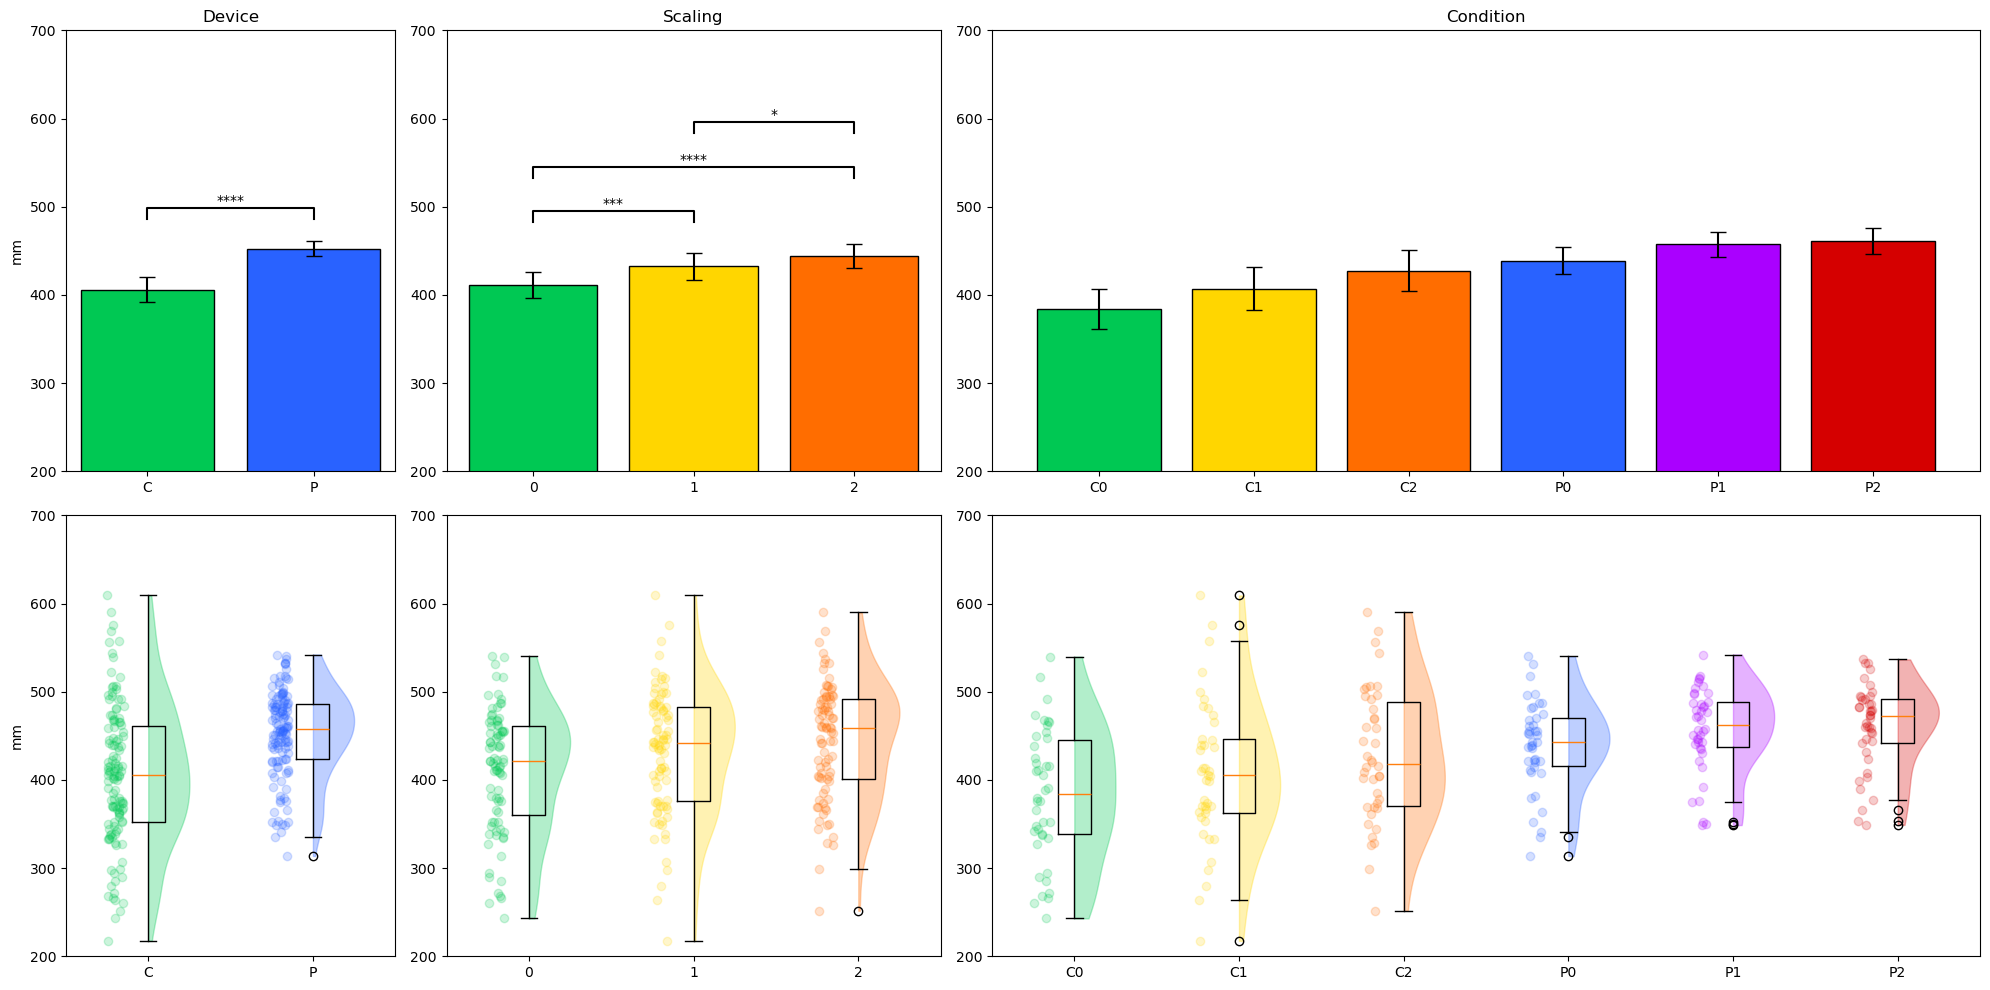

{'aov':              Source             SS  ddof1  ddof2             MS          F  \
 0            Device  135220.234960      1     41  135220.234960  21.845864   
 1           Scaling   46328.995440      2     82   23164.497720  20.928004   
 2  Device * Scaling    5467.706967      2     82    2733.853484   2.850314   
 
           p-unc     p-GG-corr       ng2       eps Significance  
 0  3.180166e-05  3.180166e-05  0.115486  1.000000            ✅  
 1  4.536988e-08  2.173738e-07  0.042819  0.885321            ✅  
 2  6.357069e-02  7.162487e-02  0.005252  0.869571            🟨  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -4.673956  41.0   two-sided   
 1  Scaling      -  0  1   True       True -4.212134  41.0   two-sided   
 2  Scaling      -  0  2   True       True -5.520926  41.0   two-sided   
 3  Scaling      -  1  2   True       True -2.723940  41.0   two-sided   
 
       p-unc    p-corr p-a

In [28]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def mean_pt_dist(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)
    return df["dist"].mean()

def tracked_hand_dist_mm(p):
    return mean_pt_dist(p, primary_tracked, secondary_tracked) * 1_000

title = "Average Hand Distance"
ylabel = "mm"
report_exeriment(data, tracked_hand_dist_mm, shovel, title, ylabel, ylim=[200,700])

------ [Cube] Task Duration ------
Mean & 21.5 & 20.94 & 23.64 & 22.54 & 22.52 & 26.12 \\
Standard Deviation & 9.84 & 8.62 & 10.24 & 8.43 & 5.87 & 10.83 \\
Minimum & 9.04 & 10.36 & 10.18 & 9.6 & 13.19 & 13.43 \\
Maximum & 51.69 & 55.26 & 49.97 & 47.29 & 37.93 & 57.51 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,182.927808,1,41,182.927808,2.978326,0.091917,0.091917,0.008656,1.000000,🟨
1,Scaling,509.542389,2,82,254.771194,4.594288,0.012847,0.023756,0.023743,0.717352,✅
2,Device * Scaling,22.108316,2,82,11.054158,0.253489,0.776694,0.729074,0.001054,0.807523,❌


Device & (1, 41) & 2.98 & 0.091917 & 0.0087 \\
Scaling & (2, 82) & 4.59 & \textbf{0.023756} & 0.0237 \\
Device * Scaling & (2, 82) & 0.25 & 0.729074 & 0.0011 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,0.286750,41.0,two-sided,0.775748,0.775748,holm,0.173,0.040120,❌
2,Scaling,-,0,2,True,True,-1.955991,41.0,two-sided,0.057303,0.114606,holm,0.94,-0.330199,❌
3,Scaling,-,1,2,True,True,-3.503763,41.0,two-sided,0.001124,0.003372,holm,27.112,-0.414565,✅


Scaling 1-0 & 41 & -0.29 & 0.775748 & -0.0401 \\
Scaling 2-0 & 41 & 1.96 & 0.114606 & 0.3302 \\
Scaling 2-1 & 41 & 3.5 & \textbf{0.003372} & 0.4146 \\


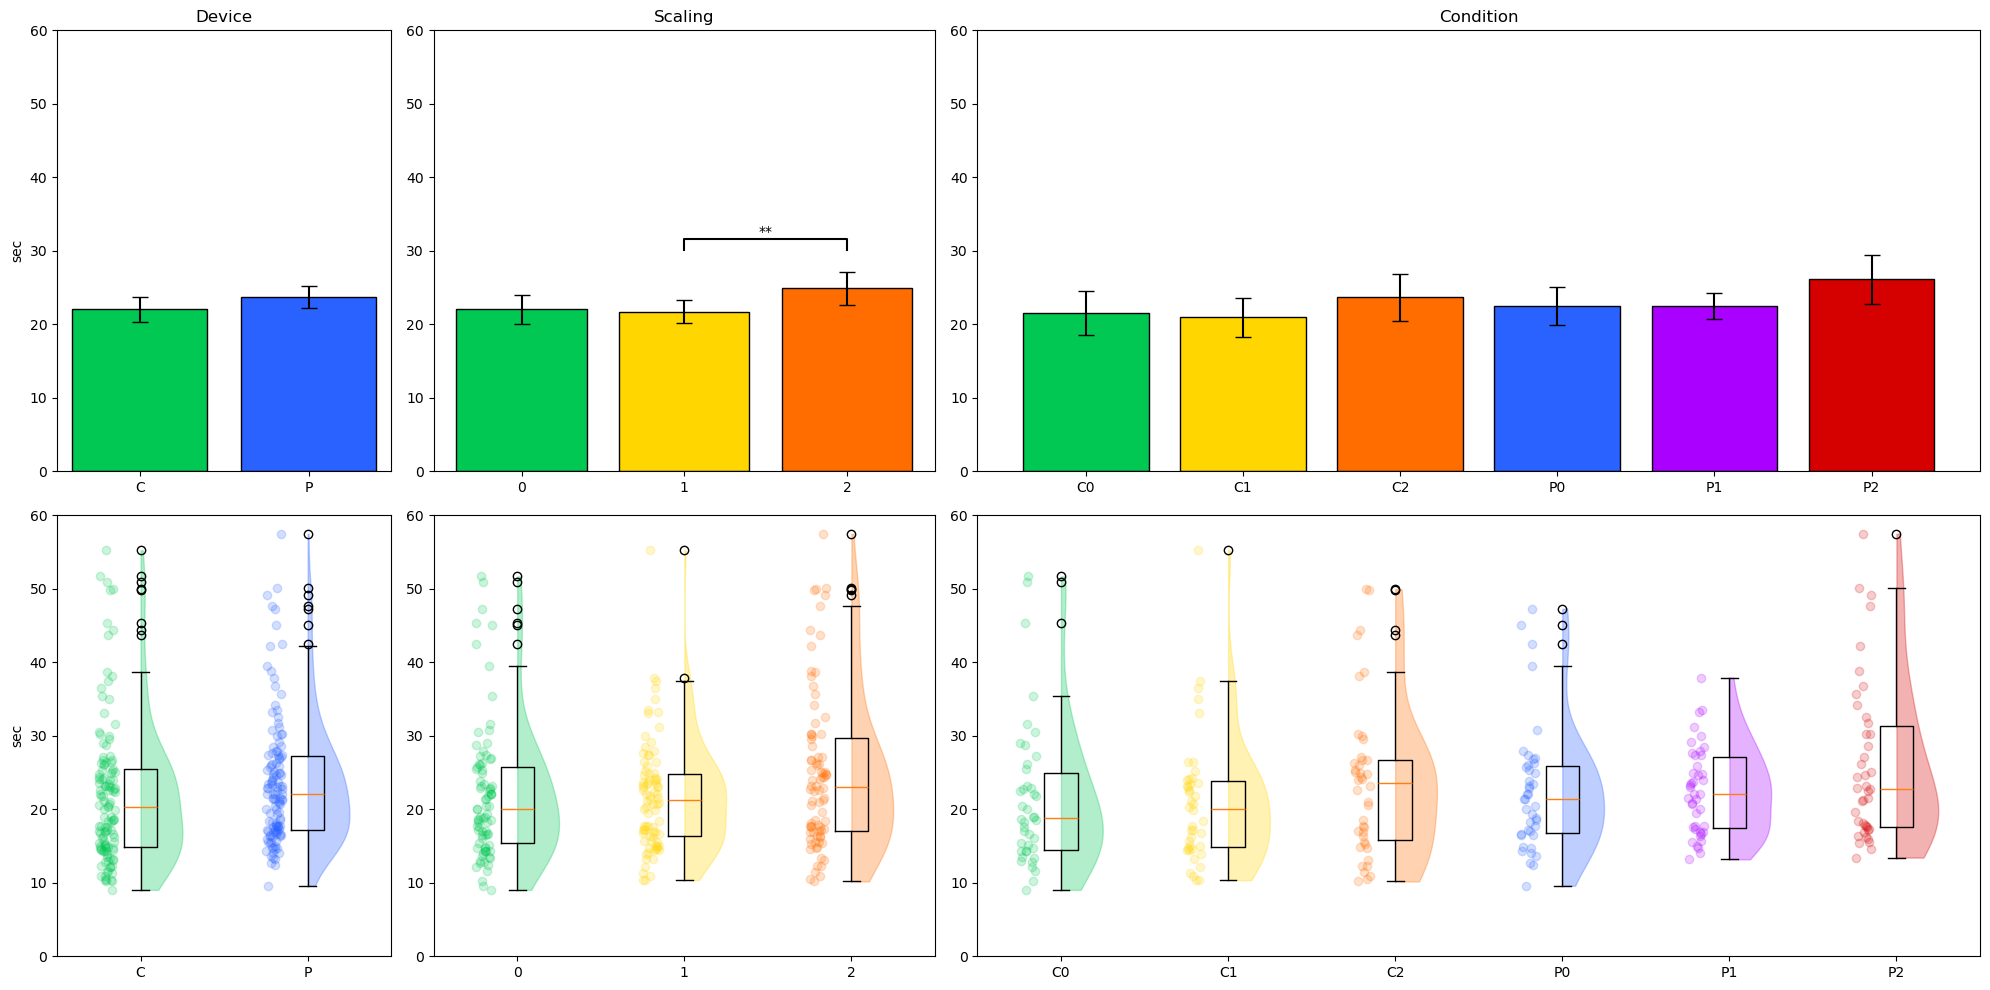

------ [Shovel] Task Duration ------
Mean & 74.68 & 78.99 & 87.96 & 76.66 & 81.02 & 88.95 \\
Standard Deviation & 18.22 & 21.11 & 20.21 & 17.96 & 18.55 & 19.02 \\
Minimum & 41.33 & 50.2 & 50.37 & 41.37 & 47.14 & 47.5 \\
Maximum & 117.43 & 160.44 & 147.91 & 113.42 & 122.85 & 126.48 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,174.495364,1,41,174.495364,0.839379,0.364932,0.364932,0.001872,1.000000,❌
1,Scaling,7102.383999,2,82,3551.192000,15.168288,0.000002,0.000015,0.070940,0.815774,✅
2,Device * Scaling,14.563805,2,82,7.281902,0.039588,0.961204,0.925526,0.000157,0.760083,❌


Device & (1, 41) & 0.84 & 0.364932 & 0.0019 \\
Scaling & (2, 82) & 15.17 & \textbf{1.5e-05} & 0.0709 \\
Device * Scaling & (2, 82) & 0.04 & 0.925526 & 0.0002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.012462,41.0,two-sided,0.050771,0.050771,holm,1.036,-0.263000,🟨
2,Scaling,-,0,2,True,True,-4.467527,41.0,two-sided,0.000061,0.000183,holm,377.161,-0.740061,✅
3,Scaling,-,1,2,True,True,-4.280168,41.0,two-sided,0.000109,0.000219,holm,221.251,-0.494258,✅


Scaling 1-0 & 41 & 2.01 & 0.050771 & 0.263 \\
Scaling 2-0 & 41 & 4.47 & \textbf{0.000183} & 0.7401 \\
Scaling 2-1 & 41 & 4.28 & \textbf{0.000219} & 0.4943 \\


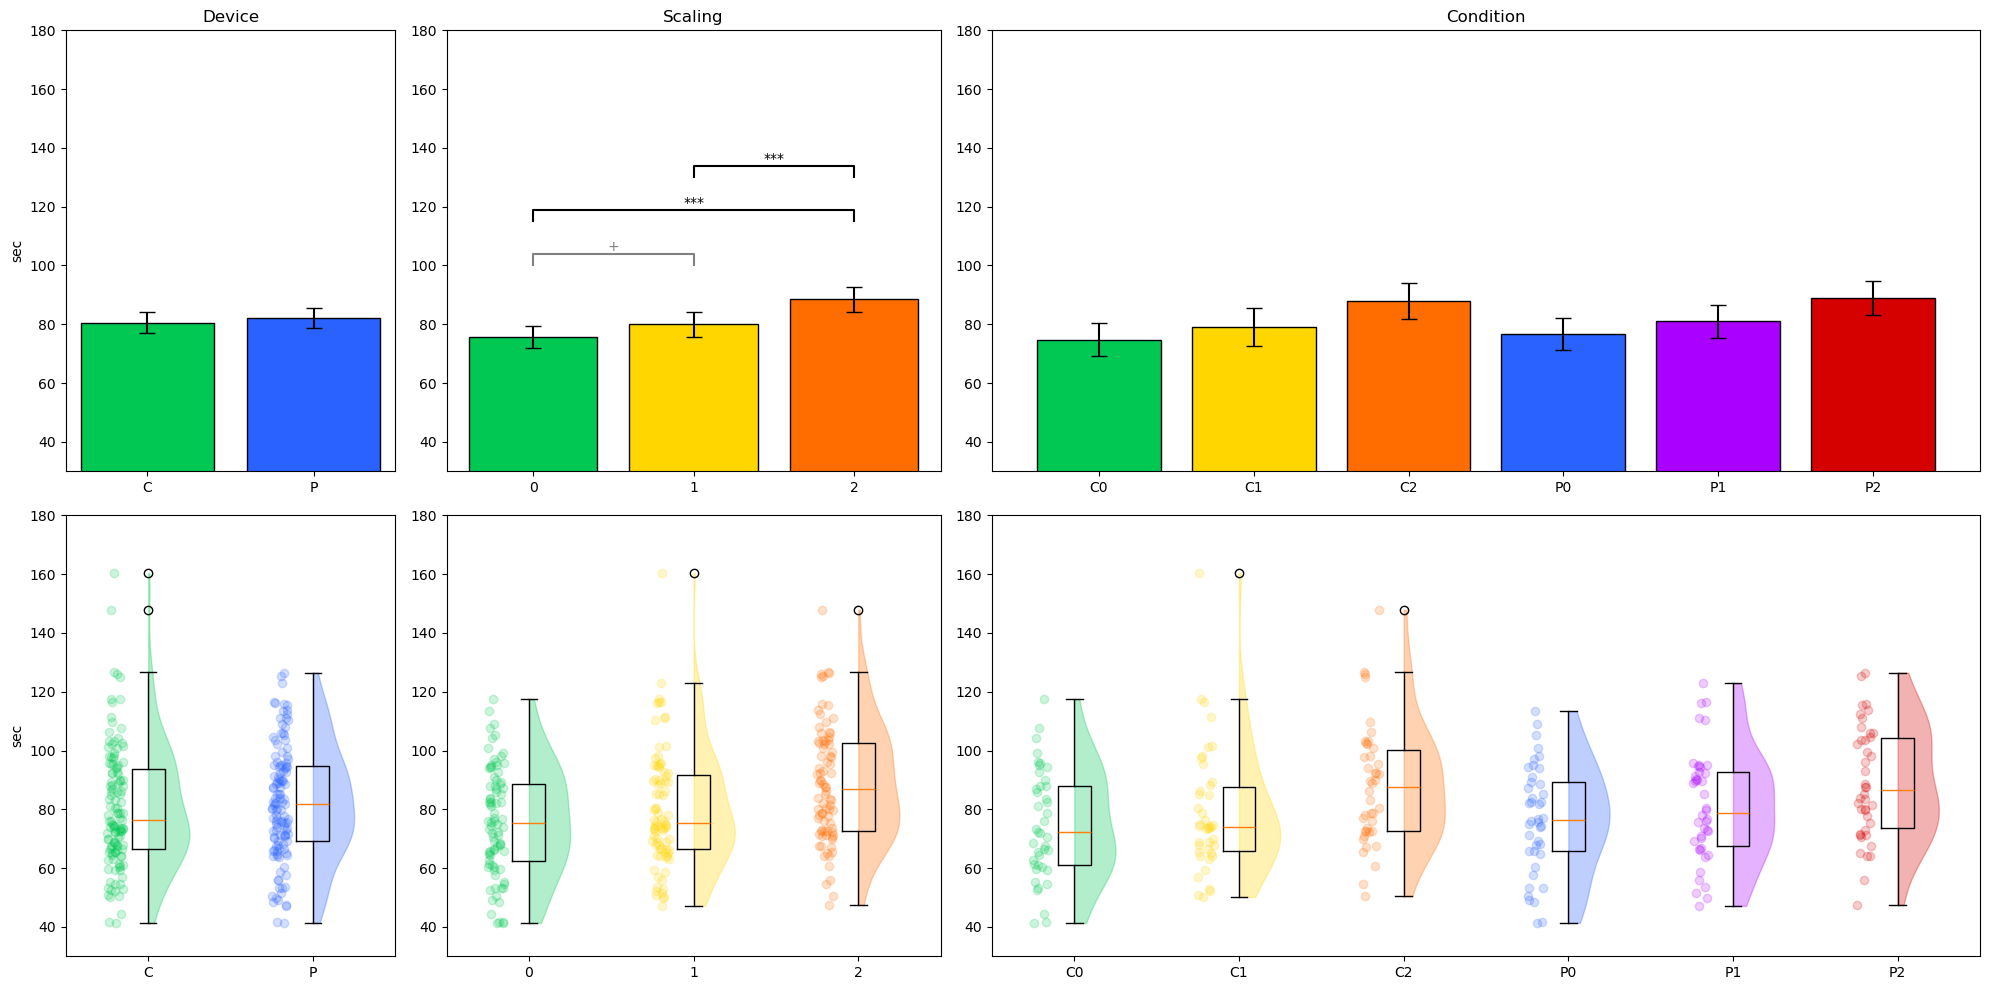

In [29]:
def task_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

title = 'Task Duration'
ylabel = 'sec'
cube_duration = report_exeriment(data, task_duration, cube, title, ylabel, ylim=[0,60])
shovel_duration = report_exeriment(data, task_duration, shovel, title, ylabel, ylim=[30,180])

------ [Cube] No Barrier Duration ------
Mean & 3.85 & 4.02 & 4.16 & 4.71 & 4.52 & 5.52 \\
Standard Deviation & 1.39 & 1.87 & 1.92 & 1.74 & 1.21 & 4.93 \\
Minimum & 1.64 & 1.58 & 2.04 & 1.85 & 2.6 & 2.17 \\
Maximum & 9.78 & 10.9 & 13.67 & 10.97 & 7.75 & 34.36 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,51.728071,1,41,51.728071,7.861990,0.007680,0.007680,0.031440,1.000000,✅
1,Scaling,17.706917,2,82,8.853458,1.697802,0.189457,0.198250,0.010989,0.696471,❌
2,Device * Scaling,7.758596,2,82,3.879298,0.620894,0.539971,0.472949,0.004845,0.643212,❌


Device & (1, 41) & 7.86 & \textbf{0.00768} & 0.0314 \\
Scaling & (2, 82) & 1.7 & 0.19825 & 0.011 \\
Device * Scaling & (2, 82) & 0.62 & 0.472949 & 0.0048 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.803924,41.0,two-sided,0.00768,NaN,NaN,5.025,-0.550788,✅


Device P-C & 41 & 2.8 & \textbf{0.00768} & 0.5508 \\


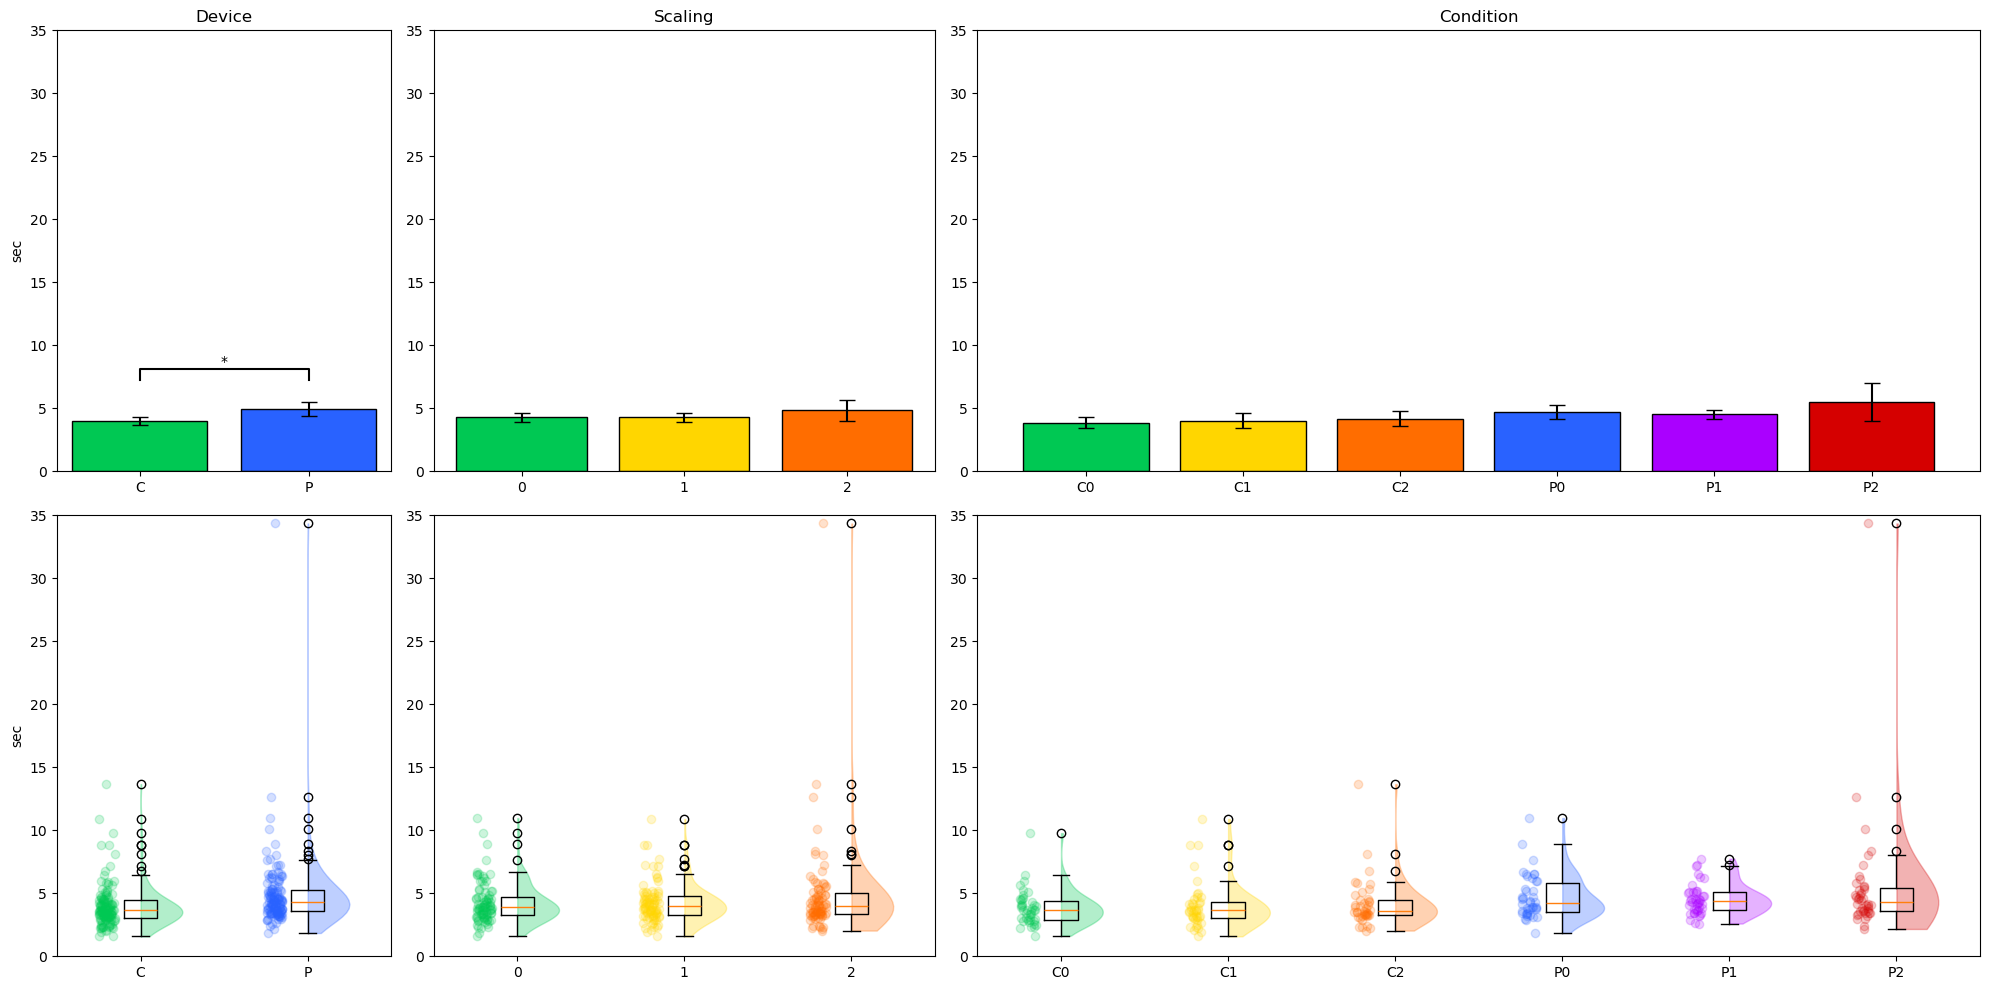

------ [Cube] Medium Gap Duration ------
Mean & 4.66 & 4.91 & 5.77 & 4.62 & 4.8 & 4.99 \\
Standard Deviation & 2.08 & 2.78 & 4.69 & 1.8 & 1.95 & 2.42 \\
Minimum & 1.54 & 1.96 & 2.35 & 1.78 & 1.97 & 2.65 \\
Maximum & 12.69 & 16.1 & 29.19 & 11.0 & 13.6 & 15.93 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,6.000789,1,41,6.000789,1.044895,0.312680,0.312680,0.003035,1.000000,❌
1,Scaling,24.331919,2,82,12.165959,2.200411,0.117256,0.129273,0.012194,0.794572,❌
2,Device * Scaling,6.875315,2,82,3.437658,0.827098,0.440931,0.419121,0.003476,0.807764,❌


Device & (1, 41) & 1.04 & 0.31268 & 0.003 \\
Scaling & (2, 82) & 2.2 & 0.129273 & 0.0122 \\
Device * Scaling & (2, 82) & 0.83 & 0.419121 & 0.0035 \\


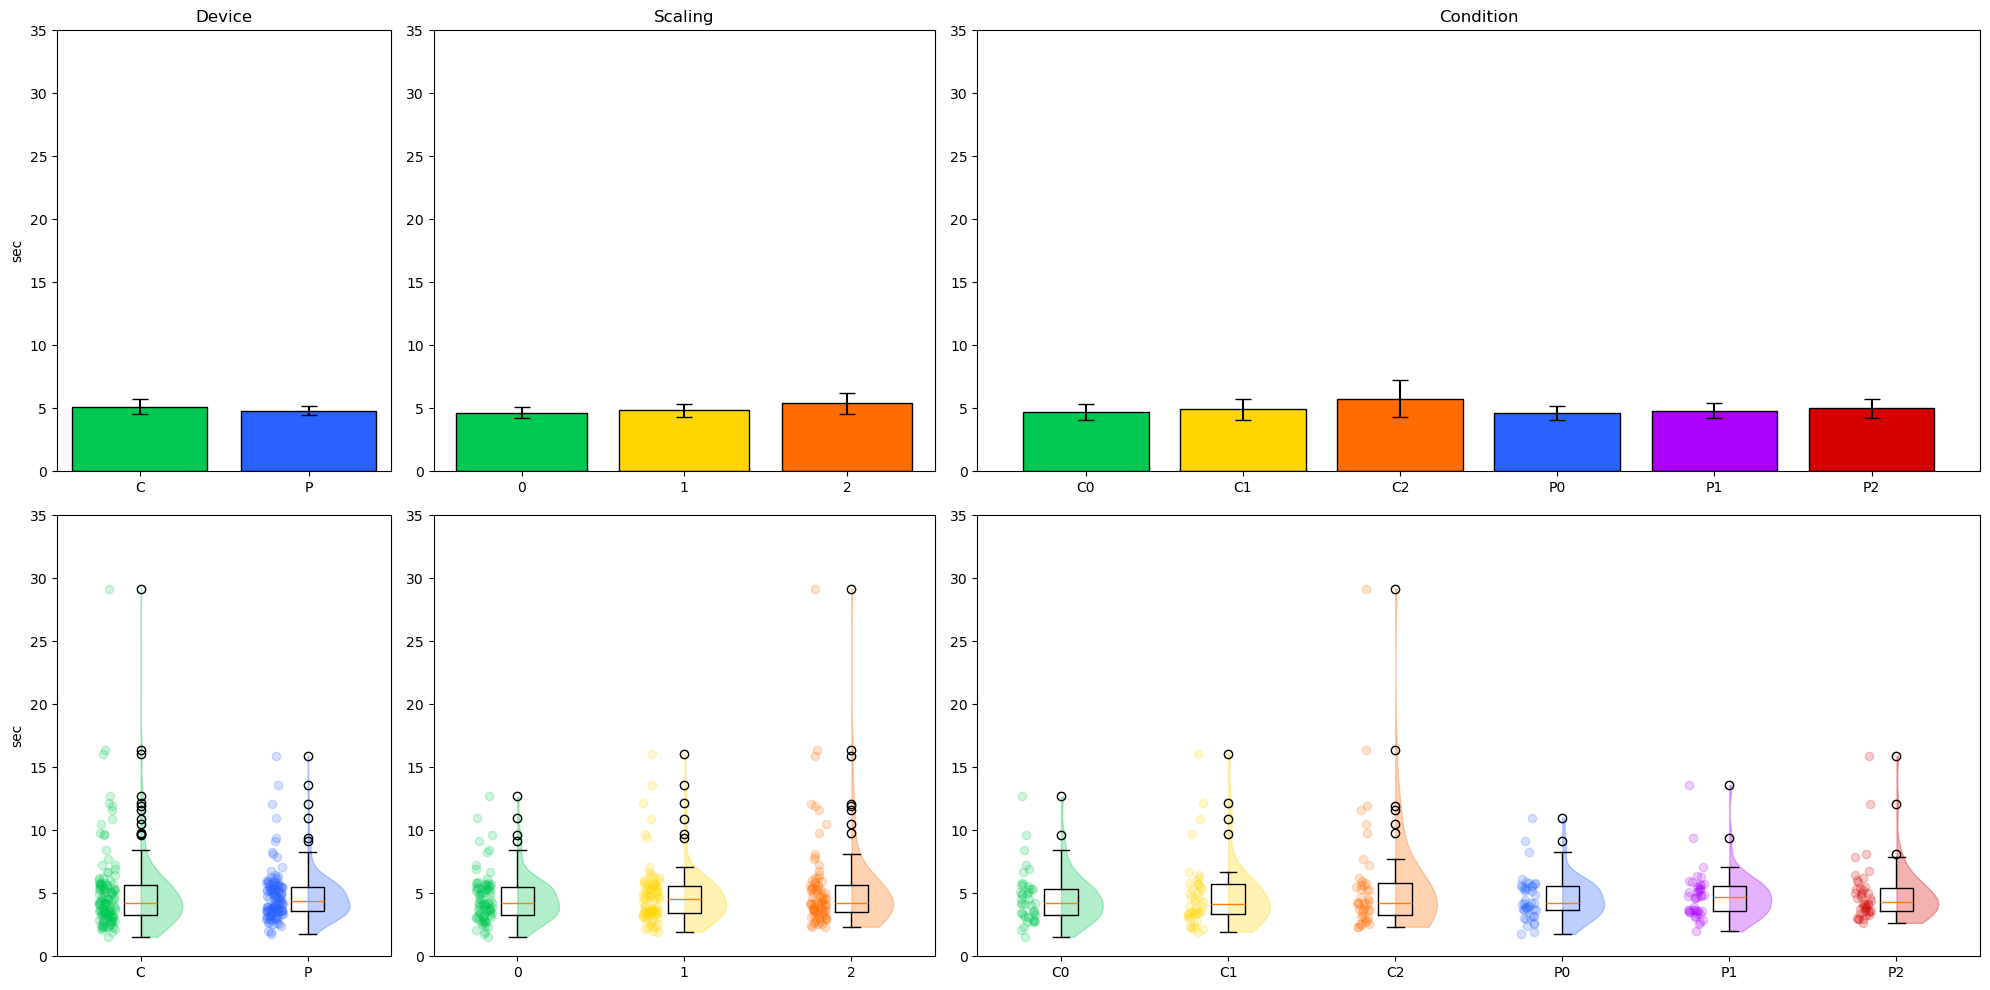

------ [Cube] Low Gap Duration ------
Mean & 6.32 & 5.66 & 6.15 & 5.58 & 5.36 & 7.23 \\
Standard Deviation & 5.47 & 3.41 & 3.74 & 3.64 & 2.02 & 5.44 \\
Minimum & 1.87 & 2.06 & 2.12 & 1.92 & 2.39 & 2.67 \\
Maximum & 26.34 & 17.51 & 16.75 & 20.99 & 10.73 & 26.17 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.016160,1,41,0.016160,0.000908,0.976109,0.976109,0.000004,1.000000,❌
1,Scaling,59.694881,2,82,29.847441,2.036516,0.137030,0.149660,0.013676,0.759533,❌
2,Device * Scaling,37.937940,2,82,18.968970,1.687544,0.191333,0.194037,0.008735,0.917295,❌


Device & (1, 41) & 0.0 & 0.976109 & 0.0 \\
Scaling & (2, 82) & 2.04 & 0.14966 & 0.0137 \\
Device * Scaling & (2, 82) & 1.69 & 0.194037 & 0.0087 \\


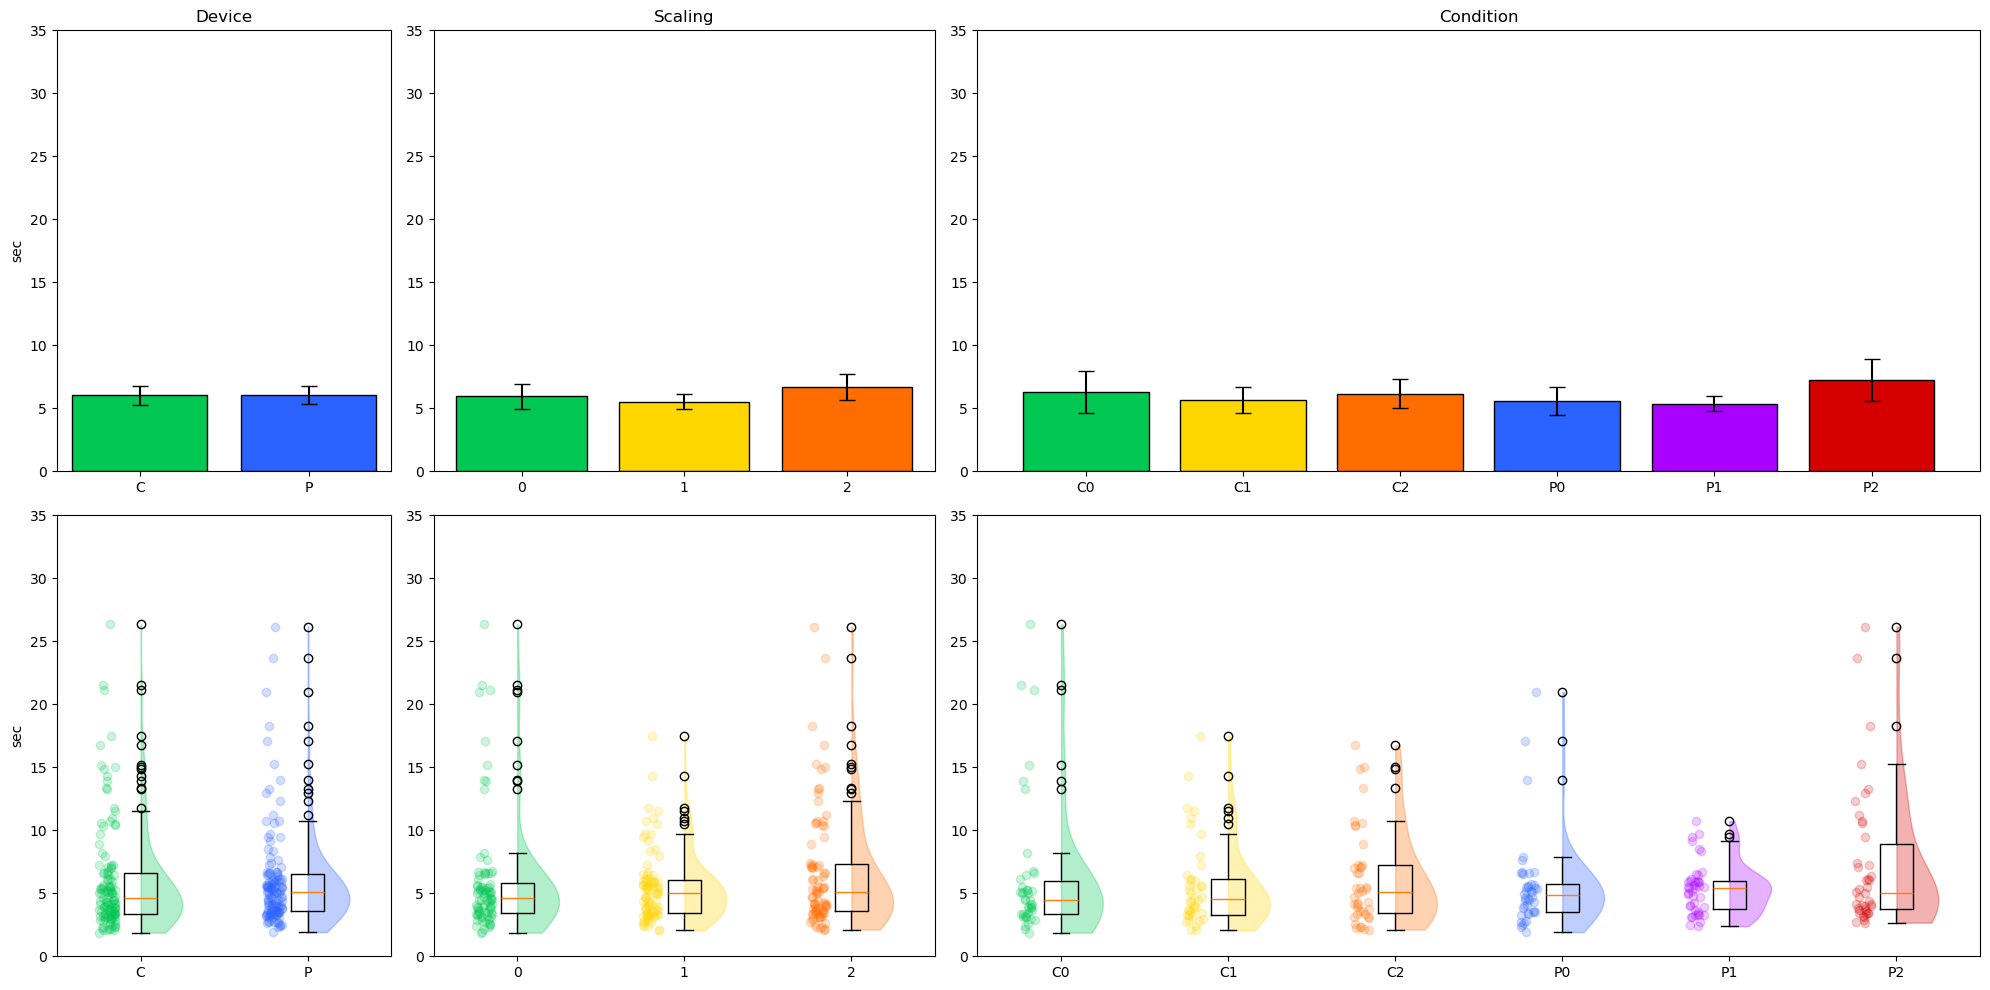

------ [Cube] High Gap Duration ------
Mean & 6.58 & 6.26 & 7.48 & 7.55 & 7.76 & 8.29 \\
Standard Deviation & 2.5 & 2.54 & 3.32 & 3.09 & 2.05 & 2.67 \\
Minimum & 3.14 & 3.29 & 3.08 & 3.96 & 4.18 & 4.21 \\
Maximum & 13.22 & 15.96 & 18.1 & 23.16 & 13.57 & 17.93 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,75.160180,1,41,75.160180,15.917703,0.000267,0.000267,0.038639,1.000000,✅
1,Scaling,40.372807,2,82,20.186404,3.813254,0.026090,0.034997,0.021133,0.816239,✅
2,Device * Scaling,5.416871,2,82,2.708436,0.668588,0.515203,0.504155,0.002888,0.924583,❌


Device & (1, 41) & 15.92 & \textbf{0.000267} & 0.0386 \\
Scaling & (2, 82) & 3.81 & \textbf{0.034997} & 0.0211 \\
Device * Scaling & (2, 82) & 0.67 & 0.504155 & 0.0029 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.989700,41.0,two-sided,0.000267,NaN,NaN,98.592,-0.510919,✅
1,Scaling,-,0,1,True,True,0.166456,41.0,two-sided,0.868616,0.868616,holm,0.169,0.023516,❌
2,Scaling,-,0,2,True,True,-1.906594,41.0,two-sided,0.063598,0.127196,holm,0.866,-0.320176,❌
3,Scaling,-,1,2,True,True,-2.841588,41.0,two-sided,0.006963,0.020888,holm,5.468,-0.382761,✅


Device P-C & 41 & 3.99 & \textbf{0.000267} & 0.5109 \\
Scaling 1-0 & 41 & -0.17 & 0.868616 & -0.0235 \\
Scaling 2-0 & 41 & 1.91 & 0.127196 & 0.3202 \\
Scaling 2-1 & 41 & 2.84 & \textbf{0.020888} & 0.3828 \\


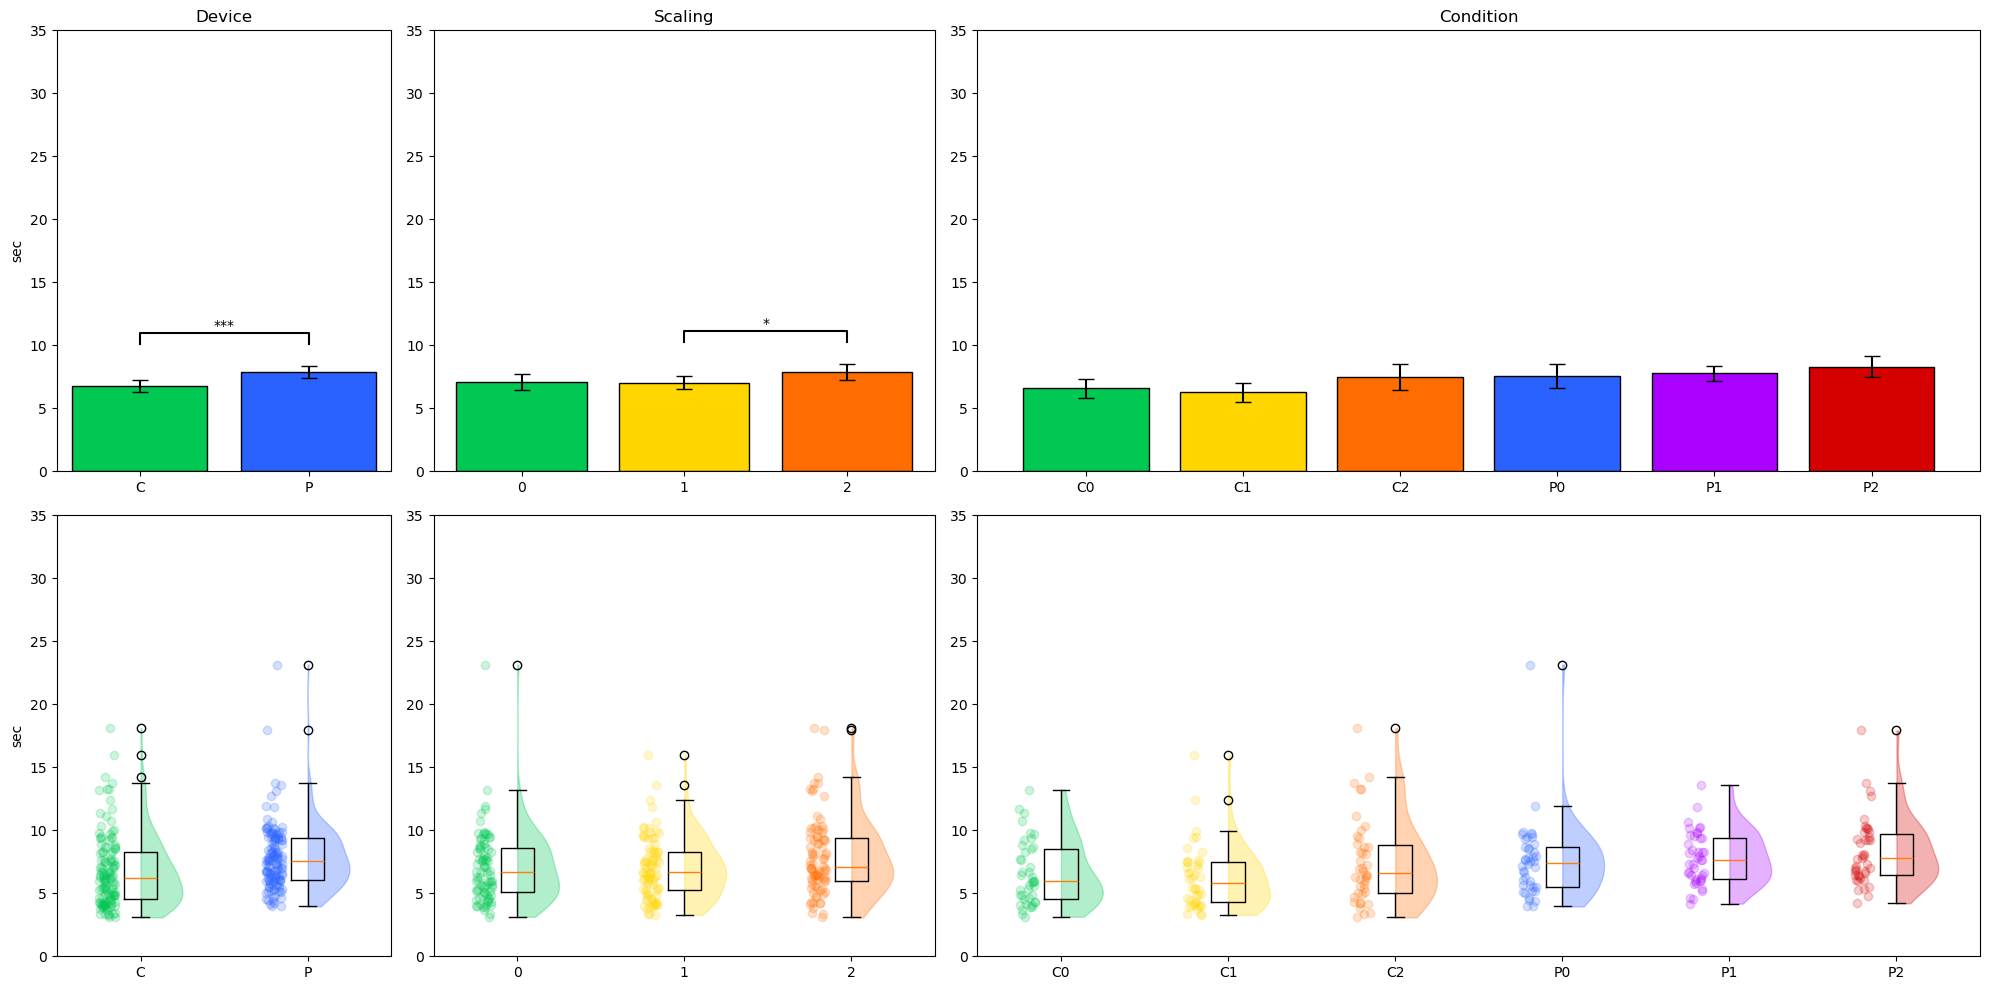

In [30]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

ylabel = "sec"
ylim=[0,35]

title = "No Barrier Duration"
def single_first(p): return single_target_split(p)[0]
no_barrier_duration = report_exeriment(data, single_first, cube, title, ylabel, ylim)

title = "Medium Gap Duration"
def single_third(p): return single_target_split(p)[2]
medium_barrier_duration = report_exeriment(data, single_third, cube, title, ylabel, ylim)

title = "Low Gap Duration"
def single_second(p): return single_target_split(p)[1]
low_barrier_duration = report_exeriment(data, single_second, cube, title, ylabel, ylim)

title = "High Gap Duration"
def single_fourth(p): return single_target_split(p)[3]
high_barrier_duration = report_exeriment(data, single_fourth, cube, title, ylabel, ylim)

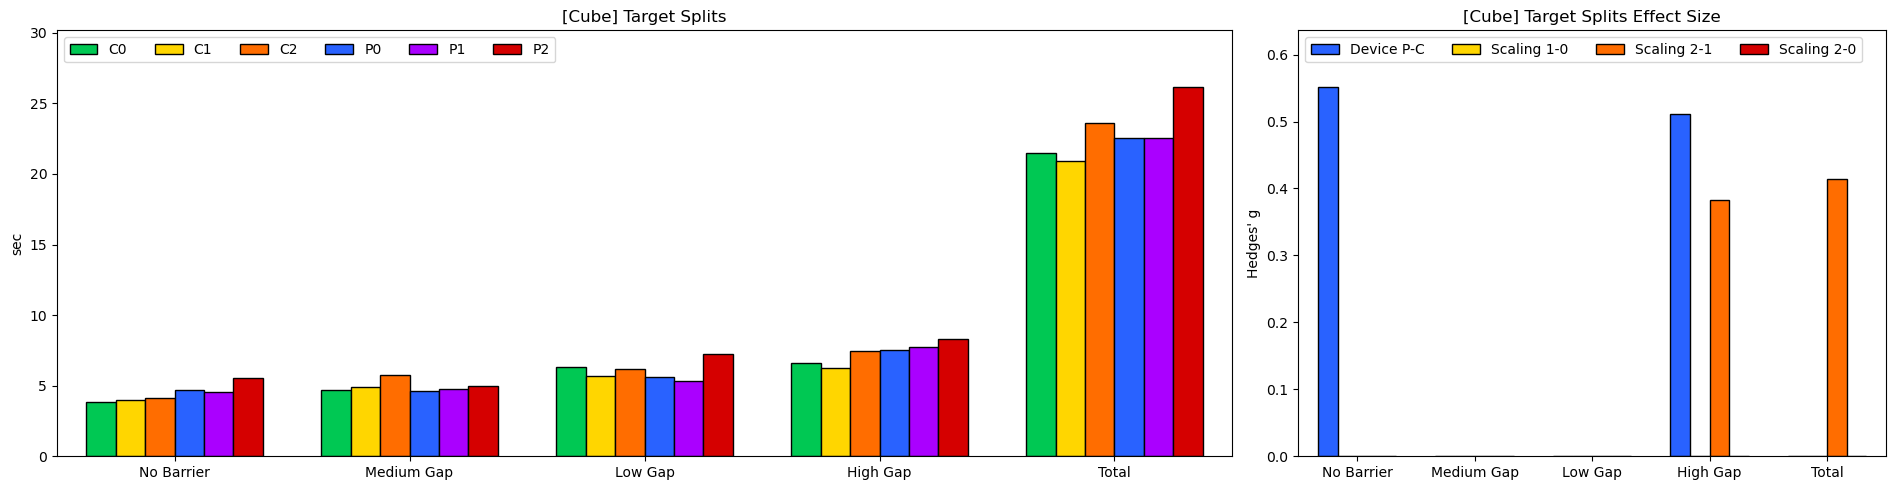

In [31]:
def get_cube_target_splits(data):
    total_durations = []
    no_barrier_durations = []
    medium_barrier_durations = []
    low_barrier_durations = []
    high_barrier_durations = []

    for c in conditions:
        participant_values = list(map(lambda x: x[cube][c], data))
        participant_totals = list(map(lambda x: task_duration(x), participant_values))
        participant_splits = list(map(lambda x: single_target_split(x), participant_values))

        total_durations.append(np.mean(participant_totals))

        no_barrier = list(map(lambda x: x[0],  participant_splits)) #No barrier is first target
        no_barrier_durations.append(np.mean(no_barrier))
        
        medium_barrier = list(map(lambda x: x[2],  participant_splits)) #Medium barrier is third taret (!)
        medium_barrier_durations.append(np.mean(medium_barrier))

        low_barrier = list(map(lambda x: x[1],  participant_splits)) #Low barrier is second target (!)
        low_barrier_durations.append(np.mean(low_barrier))

        high_barrier = list(map(lambda x: x[3],  participant_splits)) #High barrier is fourth target
        high_barrier_durations.append(np.mean(high_barrier))

    return [no_barrier_durations, medium_barrier_durations, low_barrier_durations, high_barrier_durations, total_durations]

title = "[Cube] Target Splits"
target_labels = ["No Barrier", "Medium Gap", "Low Gap", "High Gap", "Total"]
ylabel='sec'
target_splits = get_cube_target_splits(data)
cube_duration_aovs = [no_barrier_duration, medium_barrier_duration, low_barrier_duration, high_barrier_duration, cube_duration]
report_comparison(target_splits, cube_duration_aovs, target_labels, title, ylabel)


------ [Shovel] Unloaded Duration ------
Mean & 33.79 & 34.67 & 37.22 & 35.74 & 36.47 & 39.49 \\
Standard Deviation & 7.2 & 8.32 & 7.01 & 7.81 & 8.32 & 9.41 \\
Minimum & 18.47 & 21.68 & 24.59 & 19.01 & 21.97 & 18.83 \\
Maximum & 49.15 & 64.46 & 53.78 & 51.09 & 61.47 & 59.81 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,253.783143,1,41,253.783143,5.819635,0.020407,0.020407,0.015293,1.000000,✅
1,Scaling,596.233330,2,82,298.116665,6.249929,0.002976,0.005059,0.035203,0.844454,✅
2,Device * Scaling,2.448700,2,82,1.224350,0.043354,0.957595,0.937373,0.000150,0.850618,❌


Device & (1, 41) & 5.82 & \textbf{0.020407} & 0.0153 \\
Scaling & (2, 82) & 6.25 & \textbf{0.005059} & 0.0352 \\
Device * Scaling & (2, 82) & 0.04 & 0.937373 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.412392,41.0,two-sided,0.020407,NaN,NaN,2.19,-0.310149,✅
1,Scaling,-,0,1,True,True,-0.929222,41.0,two-sided,0.358213,0.358213,holm,0.25,-0.114614,❌
2,Scaling,-,0,2,True,True,-2.850946,41.0,two-sided,0.006794,0.020383,holm,5.585,-0.500862,✅
3,Scaling,-,1,2,True,True,-2.688841,41.0,two-sided,0.010319,0.020637,holm,3.9,-0.388330,✅


Device P-C & 41 & 2.41 & \textbf{0.020407} & 0.3101 \\
Scaling 1-0 & 41 & 0.93 & 0.358213 & 0.1146 \\
Scaling 2-0 & 41 & 2.85 & \textbf{0.020383} & 0.5009 \\
Scaling 2-1 & 41 & 2.69 & \textbf{0.020637} & 0.3883 \\


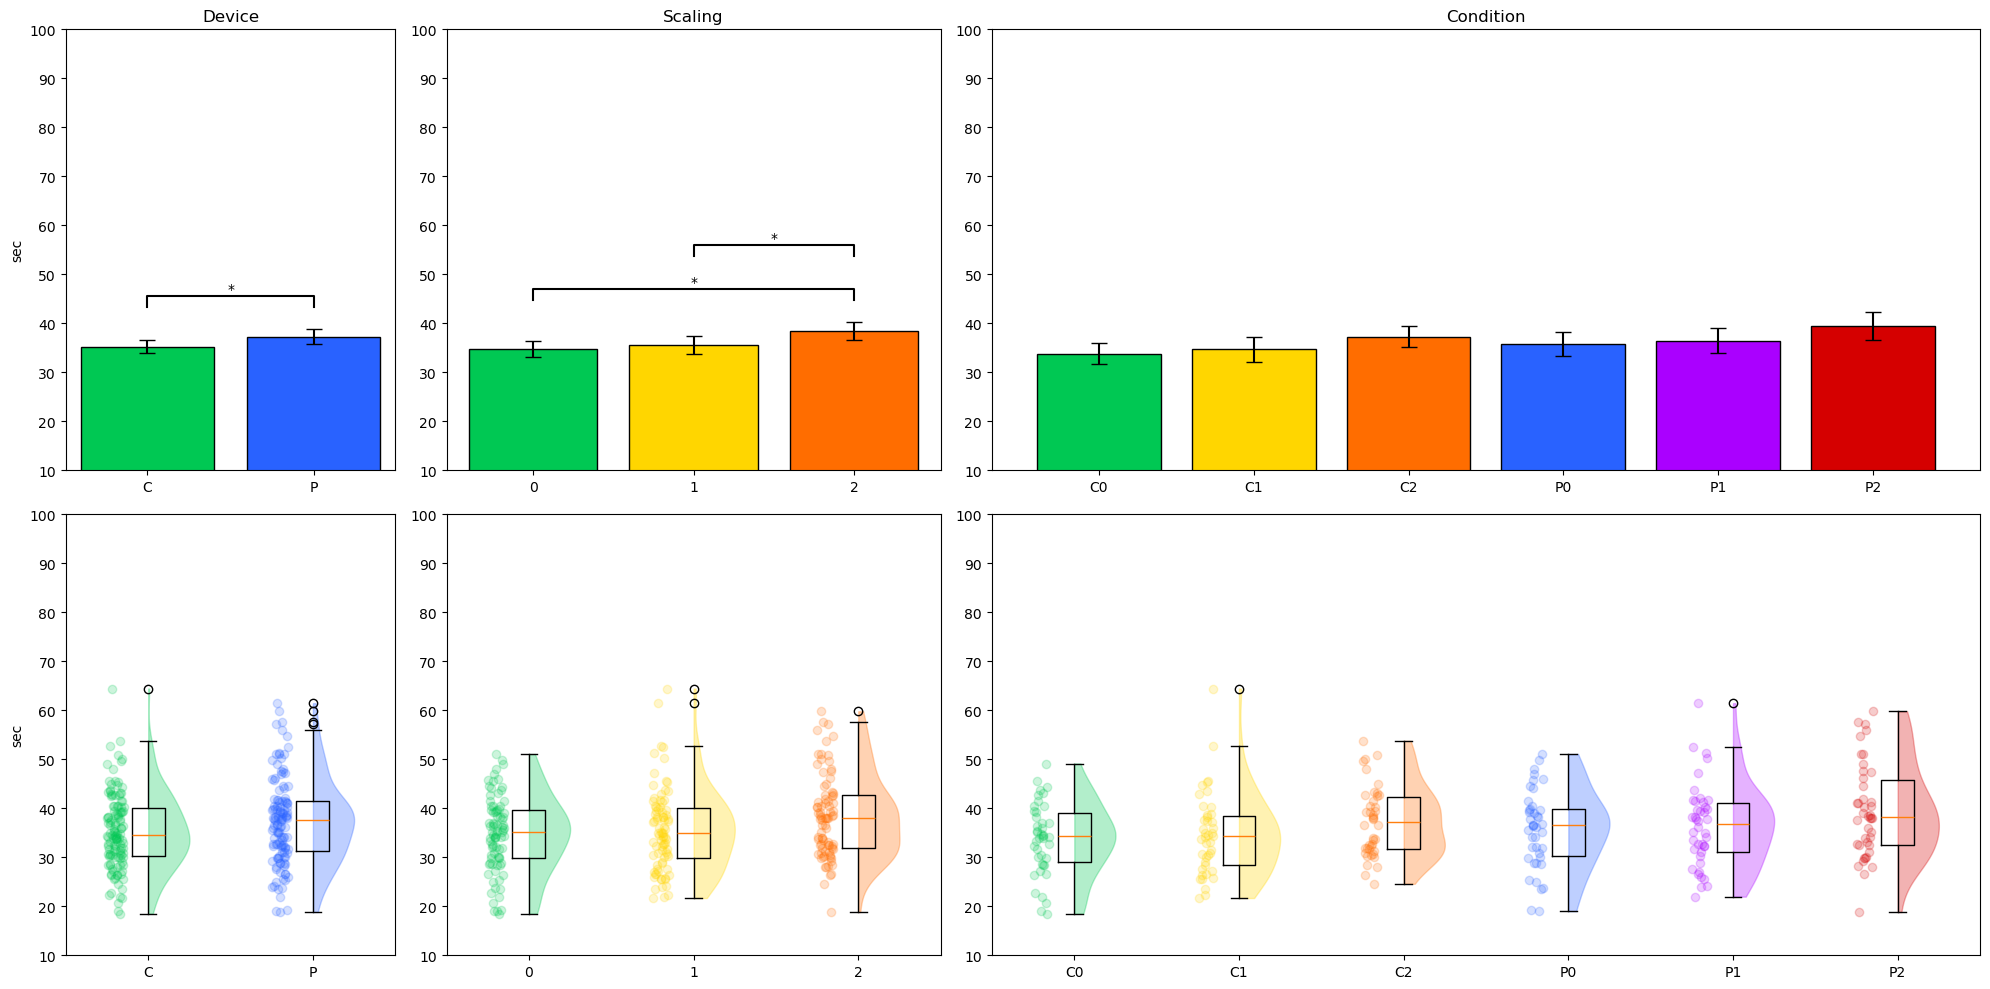

------ [Shovel] Loaded Duration ------
Mean & 35.46 & 40.05 & 46.35 & 36.2 & 40.09 & 45.03 \\
Standard Deviation & 9.65 & 12.15 & 12.78 & 9.99 & 10.34 & 9.96 \\
Minimum & 18.55 & 24.31 & 23.21 & 19.86 & 22.36 & 26.04 \\
Maximum & 55.89 & 90.59 & 87.4 & 57.57 & 63.75 & 65.79 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.995558,1,41,1.995558,0.036418,8.495975e-01,8.495975e-01,0.000067,1.000000,❌
1,Scaling,4114.775772,2,82,2057.387886,37.346902,2.946071e-12,1.260352e-10,0.121265,0.836623,✅
2,Device * Scaling,45.818095,2,82,22.909048,0.344485,7.096055e-01,6.459415e-01,0.001534,0.743362,❌


Device & (1, 41) & 0.04 & 0.849597 & 0.0001 \\
Scaling & (2, 82) & 37.35 & \textbf{0.0} & 0.1213 \\
Device * Scaling & (2, 82) & 0.34 & 0.645942 & 0.0015 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-4.072889,41.0,two-sided,2.070822e-04,2.070822e-04,holm,123.963,-0.468023,✅
2,Scaling,-,0,2,True,True,-7.182456,41.0,two-sided,9.118662e-09,2.735599e-08,holm,1.397e+06,-1.001847,✅
3,Scaling,-,1,2,True,True,-5.731193,41.0,two-sided,1.042990e-06,2.085980e-06,holm,1.624e+04,-0.575179,✅


Scaling 1-0 & 41 & 4.07 & \textbf{0.000207} & 0.468 \\
Scaling 2-0 & 41 & 7.18 & \textbf{0.0} & 1.0018 \\
Scaling 2-1 & 41 & 5.73 & \textbf{2e-06} & 0.5752 \\


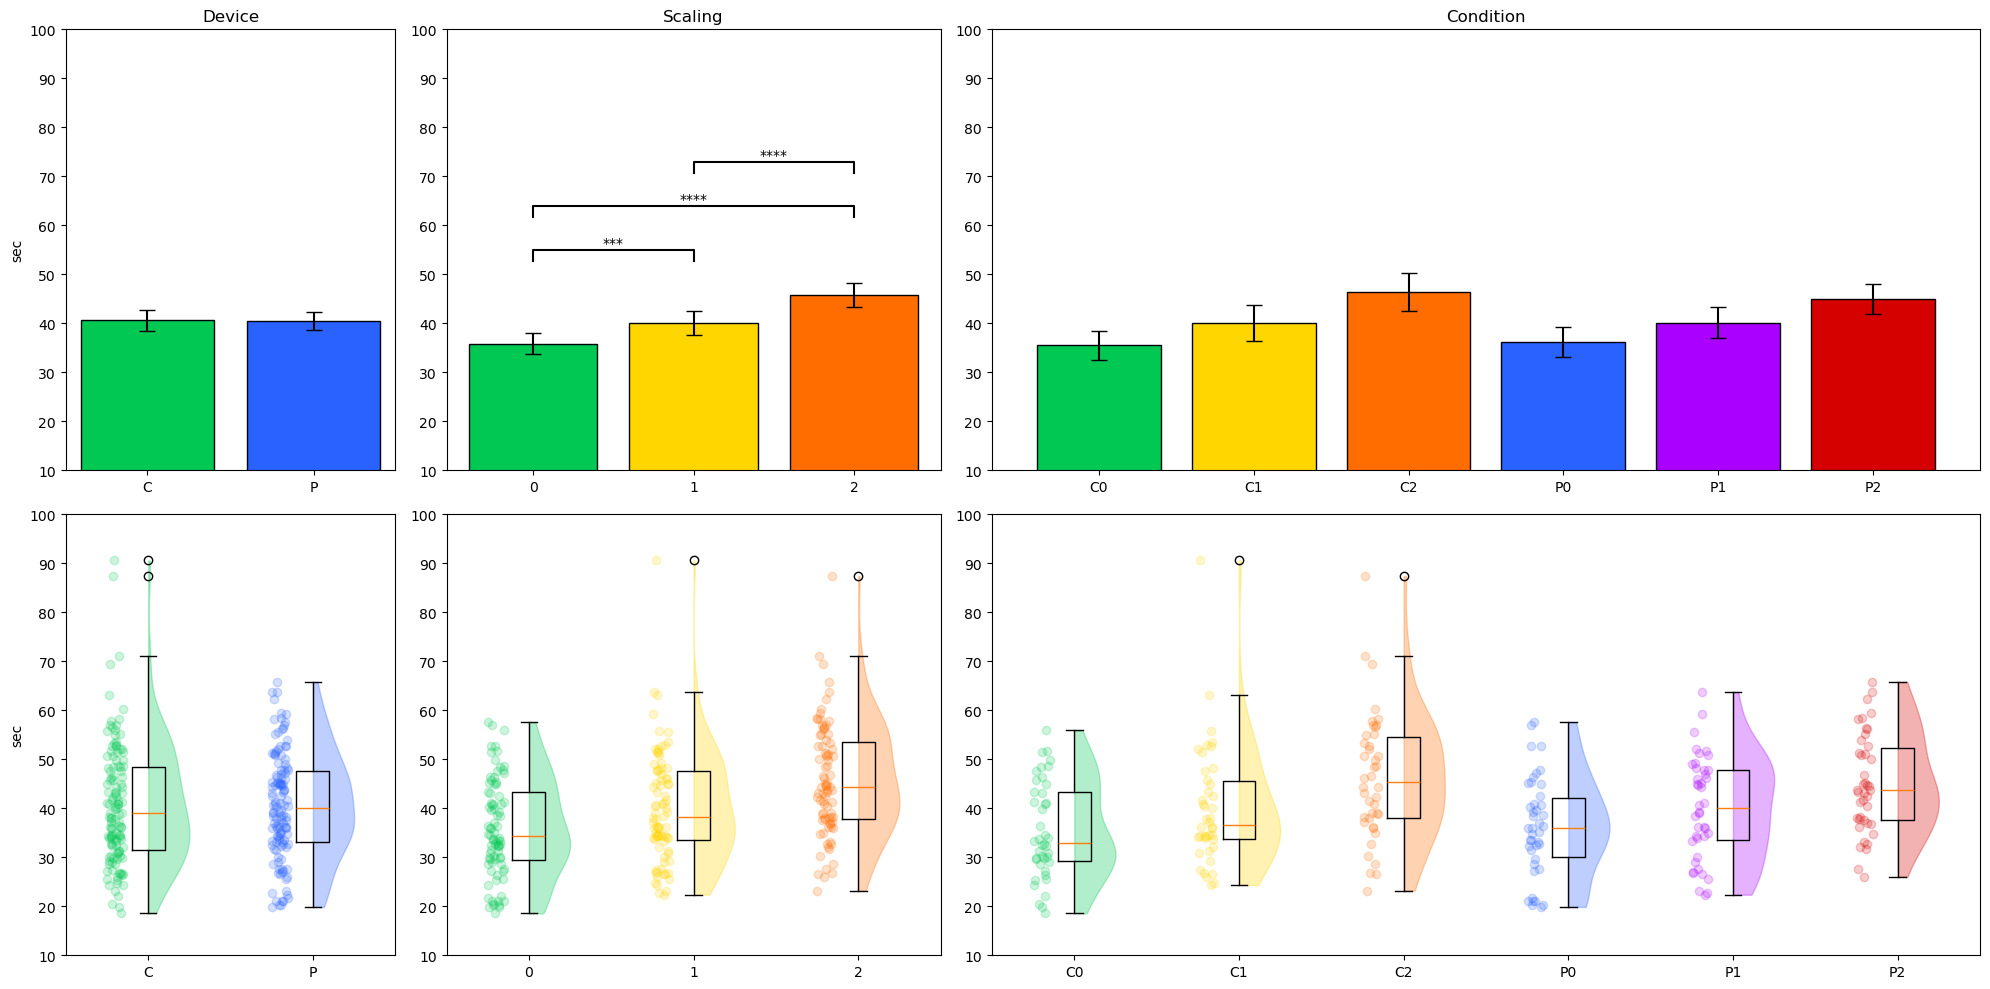

In [32]:
def single_load_time_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

ylabel = "sec"
ylim = [10, 100]

title = "Unloaded Duration"
def single_unloaded(p): return single_load_time_split(p)[0]
shovel_unloaded = report_exeriment(data, single_unloaded, shovel, title, ylabel, ylim)

title = "Loaded Duration"
def single_loaded(p): return single_load_time_split(p)[1]
shovel_loaded = report_exeriment(data, single_loaded, shovel, title, ylabel, ylim)

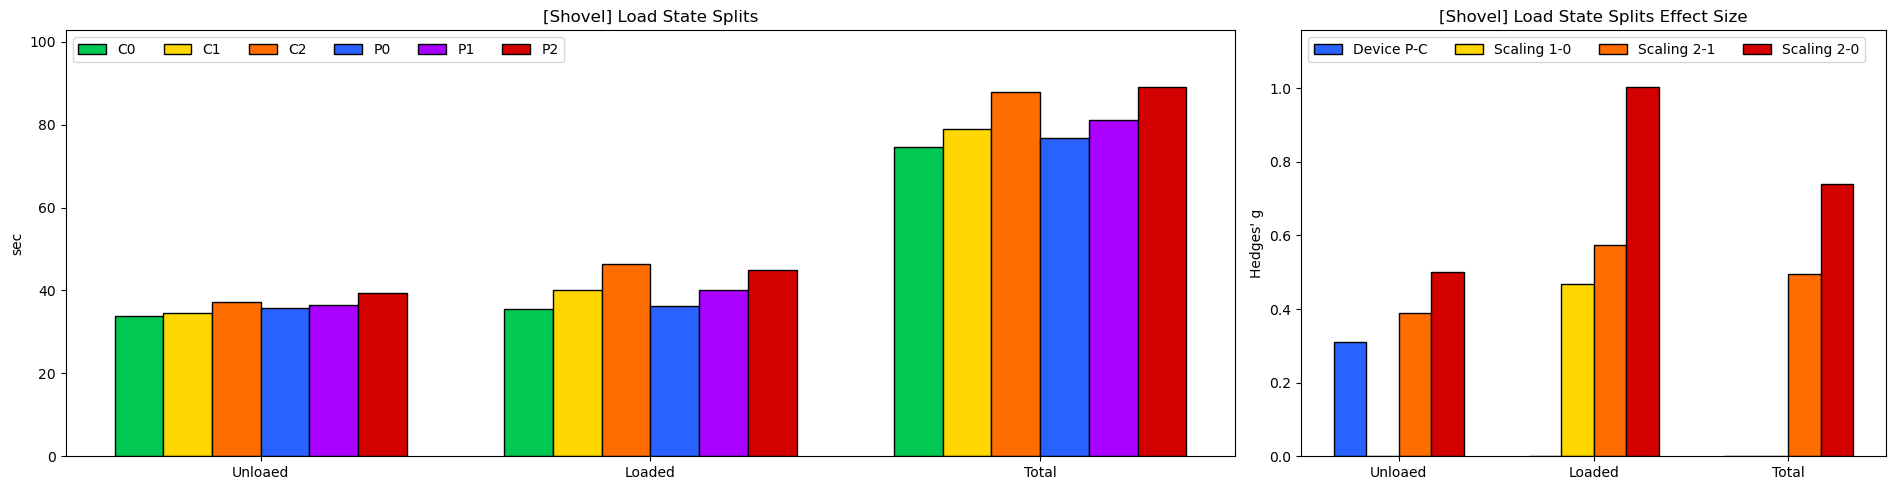

In [33]:
def get_shovel_loaded_splits(data):
    total_durations = []
    loaded_durations = []
    unloaded_durations = []

    for c in conditions:
        participant_values = list(map(lambda x: x[shovel][c], data))
        participant_totals = list(map(lambda x: task_duration(x), participant_values))
        participant_splits = list(map(lambda x: single_load_time_split(x), participant_values))

        total_durations.append(np.mean(participant_totals))

        unloaded = list(map(lambda x: x[0],  participant_splits)) #Unloaded is first in list
        unloaded_durations.append(np.mean(unloaded))
        
        loaded = list(map(lambda x: x[1],  participant_splits)) #Loaded is second in list
        loaded_durations.append(np.mean(loaded))

    return [unloaded_durations, loaded_durations, total_durations]

title = "[Shovel] Load State Splits"
ylabel= 'sec'
load_state_labels = ["Unloaed", "Loaded", "Total"]
load_state_aovs = [shovel_unloaded, shovel_loaded, shovel_duration]
load_state_splits = get_shovel_loaded_splits(data)
report_comparison(load_state_splits, load_state_aovs, load_state_labels, title, ylabel)